In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vidyasravanich/italian-pd-dataset/italian PD dataset/28 People with PD/FILE CODES.xlsx
/kaggle/input/datasets/vidyasravanich/italian-pd-dataset/italian PD dataset/28 People with PD/TAB 5.xlsx
/kaggle/input/datasets/vidyasravanich/italian-pd-dataset/italian PD dataset/28 People with PD/11-16/Nicola S/B1NSICCHOI44M240120171842.wav
/kaggle/input/datasets/vidyasravanich/italian-pd-dataset/italian PD dataset/28 People with PD/11-16/Nicola S/FB1NSICCHOI44M240120171852.wav
/kaggle/input/datasets/vidyasravanich/italian-pd-dataset/italian PD dataset/28 People with PD/11-16/Nicola S/D1NSICCHOI44M240120171845.wav
/kaggle/input/datasets/vidyasravanich/italian-pd-dataset/italian PD dataset/28 People with PD/11-16/Nicola S/B2NSICCHOI44M240120171843.wav
/kaggle/input/datasets/vidyasravanich/italian-pd-dataset/italian PD dataset/28 People with PD/11-16/Nicola S/VI1NSICCHOI44M240120171848.wav
/kaggle/input/datasets/vidyasravanich/italian-pd-dataset/italian PD dataset/28 People wi

In [2]:
# ============================================================
# 1. IMPORTS
# ============================================================

import os
import glob
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import librosa
import librosa.display
import soundfile as sf

import matplotlib.pyplot as plt

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ============================================================
# PYTORCH
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

print("PyTorch version:", torch.__version__)

PyTorch version: 2.10.0+cu128


In [4]:
# ============================================================
# SCIKIT-LEARN
# ============================================================

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_fscore_support
)

print("Scikit-learn imported successfully.")

Scikit-learn imported successfully.


In [5]:
# ============================================================
# 2. CONFIGURATION
# ============================================================

class Config:

    # --------------------------------------------------------
    # DATASET
    # --------------------------------------------------------
    DATASET_PATH = (
        "/kaggle/input/datasets/vidyasravanich/"
        "italian-pd-dataset/italian PD dataset"
    )

    # Dataset groups
    PD_CLASS = "28 People with PD"
    HC_CLASS = "22 Elderly Healthy Control"

    # Only these two groups are used in the experiment
    SELECTED_CLASSES = [
        HC_CLASS,
        PD_CLASS
    ]

    # --------------------------------------------------------
    # LABELS
    # --------------------------------------------------------
    LABEL_MAP = {
        HC_CLASS: 0,
        PD_CLASS: 1
    }

    # --------------------------------------------------------
    # RANDOM SEED
    # --------------------------------------------------------
    RANDOM_STATE = 42

    # --------------------------------------------------------
    # AUDIO PREPROCESSING
    # --------------------------------------------------------
    SAMPLE_RATE = 16000

    MAX_DURATION = 5.0

    TARGET_LENGTH = int(
        SAMPLE_RATE * MAX_DURATION
    )

    SILENCE_TOP_DB = 30

    # --------------------------------------------------------
    # SPECTROGRAM
    # --------------------------------------------------------
    N_FFT = 1024
    HOP_LENGTH = 256

    # Mel Spectrogram
    N_MELS = 128

    # --------------------------------------------------------
    # GAMMATONE
    # --------------------------------------------------------
    N_GAMMATONES = 128

    # --------------------------------------------------------
    # CQT
    # --------------------------------------------------------
    N_CQT_BINS = 84
    BINS_PER_OCTAVE = 12

    # --------------------------------------------------------
    # MODEL INPUT
    # --------------------------------------------------------
    IMAGE_SIZE = 224

    NUM_CLASSES = 2

    # --------------------------------------------------------
    # MODEL
    # --------------------------------------------------------
    DROPOUT_ATTENTION = 0.35
    DROPOUT_FUSION = 0.55
    DROPOUT_CLASSIFIER = 0.45

    FUSION_DIM = 96

    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------
    BATCH_SIZE = 8
    EPOCHS = 40

    LEARNING_RATE = 3e-4
    BACKBONE_LR = 2e-6

    WEIGHT_DECAY = 2e-3

    LABEL_SMOOTHING = 0.10

    EARLY_STOPPING_PATIENCE = 8
    MIN_EPOCHS_BEFORE_STOPPING = 15

    UNFREEZE_EPOCH = 100
    # --------------------------------------------------------
    # DATA SPLIT
    # --------------------------------------------------------
    TEST_SIZE = 0.20
    VALIDATION_SIZE = 0.25

    # --------------------------------------------------------
    # DATALOADER
    # --------------------------------------------------------
    NUM_WORKERS = 2
    PIN_MEMORY = True


CFG = Config()

print("Configuration created successfully.")

Configuration created successfully.


In [6]:
# ============================================================
# REPRODUCIBILITY
# ============================================================

def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


seed_everything(CFG.RANDOM_STATE)

print(
    f"Random seed set to {CFG.RANDOM_STATE}"
)

Random seed set to 42


In [7]:
# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Device: cuda
GPU: Tesla T4


In [8]:
# ============================================================
# 3. LOAD METADATA - DATASET CHECK
# ============================================================

print("Dataset path:")
print(CFG.DATASET_PATH)

print(
    "\nDataset path exists:",
    os.path.exists(CFG.DATASET_PATH)
)

if not os.path.exists(CFG.DATASET_PATH):
    raise FileNotFoundError(
        "Dataset path does not exist. "
        "Please check the Kaggle input path."
    )

Dataset path:
/kaggle/input/datasets/vidyasravanich/italian-pd-dataset/italian PD dataset

Dataset path exists: True


In [9]:
# ============================================================
# INSPECT DATASET STRUCTURE
# ============================================================

print("Top-level folders:\n")

for item in sorted(
    os.listdir(CFG.DATASET_PATH)
):

    print(" -", item)

Top-level folders:

 - 15 Young Healthy Control
 - 22 Elderly Healthy Control
 - 28 People with PD


In [10]:
# ============================================================
# FIND RAW AUDIO FILES
# ============================================================

all_wav_files = glob.glob(
    os.path.join(
        CFG.DATASET_PATH,
        "**",
        "*.wav"
    ),
    recursive=True
)

print(
    "Total WAV files found:",
    len(all_wav_files)
)

print("\nFirst 10 files:\n")

for path in all_wav_files[:10]:
    print(path)

Total WAV files found: 831

First 10 files:

/kaggle/input/datasets/vidyasravanich/italian-pd-dataset/italian PD dataset/28 People with PD/11-16/Nicola S/B1NSICCHOI44M240120171842.wav
/kaggle/input/datasets/vidyasravanich/italian-pd-dataset/italian PD dataset/28 People with PD/11-16/Nicola S/FB1NSICCHOI44M240120171852.wav
/kaggle/input/datasets/vidyasravanich/italian-pd-dataset/italian PD dataset/28 People with PD/11-16/Nicola S/D1NSICCHOI44M240120171845.wav
/kaggle/input/datasets/vidyasravanich/italian-pd-dataset/italian PD dataset/28 People with PD/11-16/Nicola S/B2NSICCHOI44M240120171843.wav
/kaggle/input/datasets/vidyasravanich/italian-pd-dataset/italian PD dataset/28 People with PD/11-16/Nicola S/VI1NSICCHOI44M240120171848.wav
/kaggle/input/datasets/vidyasravanich/italian-pd-dataset/italian PD dataset/28 People with PD/11-16/Nicola S/VU1NSICCHOI44M240120171849.wav
/kaggle/input/datasets/vidyasravanich/italian-pd-dataset/italian PD dataset/28 People with PD/11-16/Nicola S/VO2NSICCH

In [11]:
# ============================================================
# BUILD RECORDING METADATA
# ============================================================

def build_metadata(dataset_path):

    records = []

    for root, dirs, files in os.walk(
        dataset_path
    ):

        wav_files = [
            f for f in files
            if f.lower().endswith(".wav")
        ]

        if len(wav_files) == 0:
            continue

        relative_path = os.path.relpath(
            root,
            dataset_path
        )

        parts = relative_path.split(
            os.sep
        )

        # ----------------------------------------------------
        # Parkinson's Disease
        # ----------------------------------------------------
        if parts[0] == CFG.PD_CLASS:

            class_name = CFG.PD_CLASS

        # ----------------------------------------------------
        # Elderly Healthy Control
        # ----------------------------------------------------
        elif parts[0] == CFG.HC_CLASS:

            class_name = CFG.HC_CLASS

        # ----------------------------------------------------
        # Ignore Young Healthy Control
        # ----------------------------------------------------
        else:
            continue

        # ----------------------------------------------------
        # Subject ID
        # ----------------------------------------------------
        #
        # We preserve the folder information after the
        # class folder as the subject identifier.
        #
        # This must be verified against the actual structure.
        # ----------------------------------------------------

        subject_parts = parts[1:]

        subject_id = "_".join(
            subject_parts
        )

        # ----------------------------------------------------
        # Recordings
        # ----------------------------------------------------

        for filename in wav_files:

            filepath = os.path.join(
                root,
                filename
            )

            records.append({

                "subject_id":
                    subject_id,

                "class_name":
                    class_name,

                "label":
                    CFG.LABEL_MAP[class_name],

                "filename":
                    filename,

                "audio_path":
                    filepath
            })

    return pd.DataFrame(records)


metadata = build_metadata(
    CFG.DATASET_PATH
)

print(
    "Metadata created successfully."
)

print(
    "Shape:",
    metadata.shape
)

metadata.head()

Metadata created successfully.
Shape: (786, 5)


,subject_id,class_name,label,filename,audio_path
0,11-16_Nicola S,28 People with PD,1,B1NSICCHOI44M240120171842.wav,/kaggle/input/datasets/vidyasravanich/italian-...
1,11-16_Nicola S,28 People with PD,1,FB1NSICCHOI44M240120171852.wav,/kaggle/input/datasets/vidyasravanich/italian-...
2,11-16_Nicola S,28 People with PD,1,D1NSICCHOI44M240120171845.wav,/kaggle/input/datasets/vidyasravanich/italian-...
3,11-16_Nicola S,28 People with PD,1,B2NSICCHOI44M240120171843.wav,/kaggle/input/datasets/vidyasravanich/italian-...
4,11-16_Nicola S,28 People with PD,1,VI1NSICCHOI44M240120171848.wav,/kaggle/input/datasets/vidyasravanich/italian-...


In [12]:
# ============================================================
# VERIFY METADATA
# ============================================================

print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

print(
    "Total recordings:",
    len(metadata)
)

print(
    "Unique subjects:",
    metadata["subject_id"].nunique()
)

print("\nRecordings by class:")

print(
    metadata["class_name"]
    .value_counts()
)

print("\nSubjects by class:")

print(
    metadata
    .groupby("class_name")["subject_id"]
    .nunique()
)

DATASET SUMMARY
Total recordings: 786
Unique subjects: 50

Recordings by class:
class_name
28 People with PD             437
22 Elderly Healthy Control    349
Name: count, dtype: int64

Subjects by class:
class_name
22 Elderly Healthy Control    22
28 People with PD             28
Name: subject_id, dtype: int64


In [13]:
# ============================================================
# SUBJECT VERIFICATION
# ============================================================

subject_table = (
    metadata[
        [
            "subject_id",
            "class_name",
            "label"
        ]
    ]
    .drop_duplicates()
    .sort_values("subject_id")
    .reset_index(drop=True)
)

print(
    "Number of unique subjects:",
    len(subject_table)
)

display(subject_table)

Number of unique subjects: 50


,subject_id,class_name,label
0,1-5_Domenico C,28 People with PD,1
1,1-5_Felicetta C,28 People with PD,1
2,1-5_Leonarda L,28 People with PD,1
3,1-5_Lucia R,28 People with PD,1
4,1-5_Roberto R,28 People with PD,1
5,11-16_Anna B,28 People with PD,1
6,11-16_Michele C,28 People with PD,1
7,11-16_Nicola S,28 People with PD,1
8,11-16_Roberto L,28 People with PD,1
9,11-16_Roberto R,28 People with PD,1


In [14]:
# ============================================================
# REMOVE EXACT DUPLICATE AUDIO
# ============================================================

EXCLUDED_FILES = [
    "B1GPIUUGLL63F100220171020.wav"
]

metadata["filename"] = (
    metadata["filename"]
    .astype(str)
    .str.strip()
)

metadata = metadata[
    ~metadata["filename"].isin(EXCLUDED_FILES)
].copy()

print(
    "Recordings after duplicate removal:",
    len(metadata)
)

print(
    "Excluded files:",
    EXCLUDED_FILES
)

Recordings after duplicate removal: 785
Excluded files: ['B1GPIUUGLL63F100220171020.wav']


In [15]:
# ============================================================
# 4. PREPROCESSING
# ============================================================

def preprocess_audio(
    audio_path,
    sample_rate=CFG.SAMPLE_RATE,
    max_duration=CFG.MAX_DURATION,
    silence_top_db=CFG.SILENCE_TOP_DB
):
    """
    Deterministic audio preprocessing.

    1. Load audio
    2. Convert to mono
    3. Resample to 16 kHz
    4. Remove mean/DC component
    5. Trim silence
    6. Peak normalize
    7. Pad/crop to fixed duration
    """

    # --------------------------------------------------------
    # 1. Load audio
    # --------------------------------------------------------

    audio, _ = librosa.load(
        audio_path,
        sr=sample_rate,
        mono=True
    )

    # --------------------------------------------------------
    # 2. Mean removal
    # --------------------------------------------------------

    audio = audio - np.mean(audio)

    # --------------------------------------------------------
    # 3. Silence trimming
    # --------------------------------------------------------

    audio, _ = librosa.effects.trim(
        audio,
        top_db=silence_top_db
    )

    # --------------------------------------------------------
    # 4. Peak normalization
    # --------------------------------------------------------

    peak = np.max(
        np.abs(audio)
    )

    if peak > 0:
        audio = audio / peak

    # --------------------------------------------------------
    # 5. Fixed length
    # --------------------------------------------------------

    target_length = int(
        sample_rate * max_duration
    )

    if len(audio) > target_length:

        # Deterministic center crop
        start = (
            len(audio) -
            target_length
        ) // 2

        audio = audio[
            start:
            start + target_length
        ]

    elif len(audio) < target_length:

        padding_length = (
            target_length -
            len(audio)
        )

        audio = np.pad(
            audio,
            (
                0,
                padding_length
            ),
            mode="constant"
        )

    return audio.astype(
        np.float32
    )

In [16]:
# ============================================================
# PREPROCESSING TEST
# ============================================================

sample_path = metadata.iloc[0][
    "audio_path"
]

processed_audio = preprocess_audio(
    sample_path
)

print(
    "Number of samples:",
    len(processed_audio)
)

print(
    "Expected samples:",
    CFG.TARGET_LENGTH
)

print(
    "Duration:",
    len(processed_audio) /
    CFG.SAMPLE_RATE,
    "seconds"
)

print(
    "Minimum amplitude:",
    processed_audio.min()
)

print(
    "Maximum amplitude:",
    processed_audio.max()
)

Number of samples: 80000
Expected samples: 80000
Duration: 5.0 seconds
Minimum amplitude: -1.0
Maximum amplitude: 0.62694216


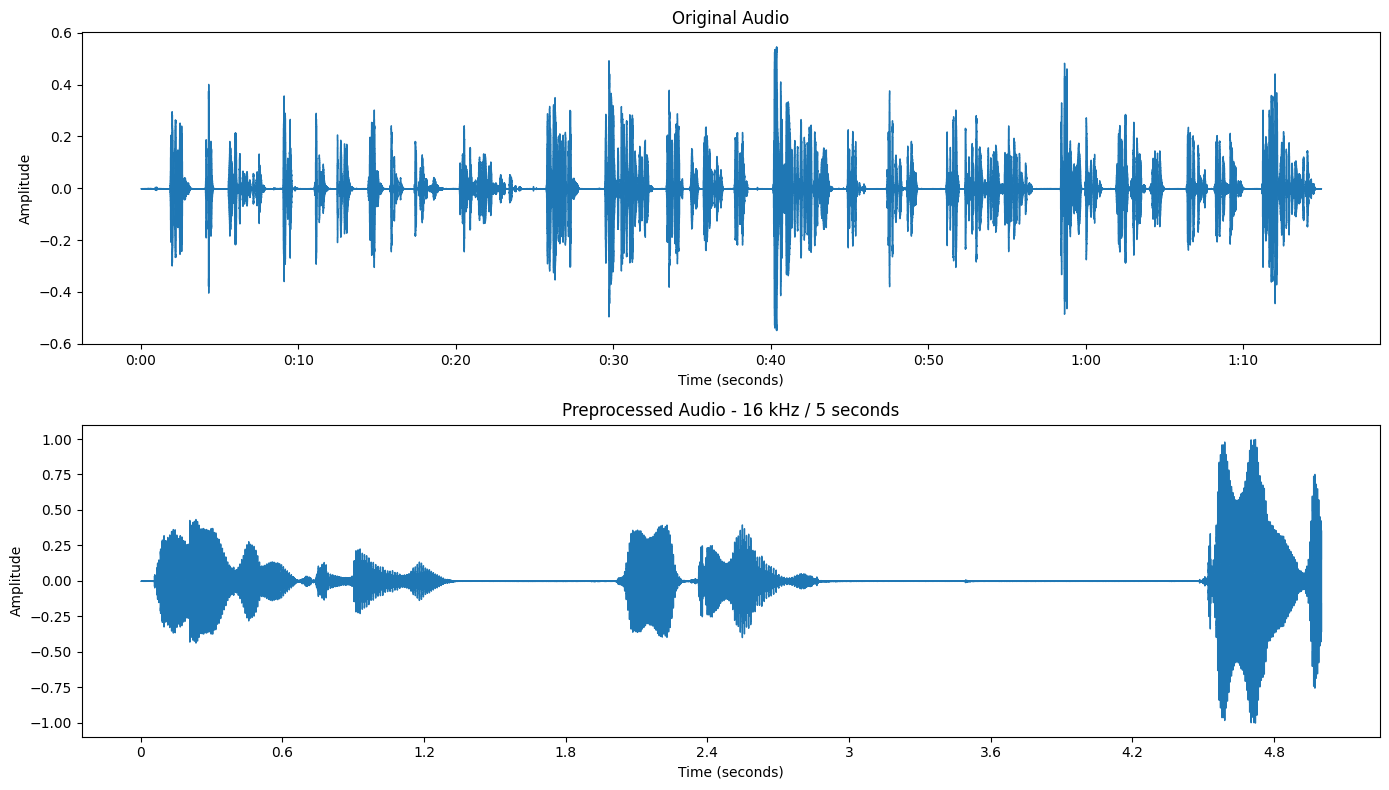

In [17]:
# ============================================================
# PREPROCESSING VISUALIZATION
# ============================================================

original_audio, original_sr = librosa.load(
    sample_path,
    sr=None,
    mono=True
)

processed_audio = preprocess_audio(
    sample_path
)

plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)

librosa.display.waveshow(
    original_audio,
    sr=original_sr
)

plt.title("Original Audio")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")


plt.subplot(2, 1, 2)

librosa.display.waveshow(
    processed_audio,
    sr=CFG.SAMPLE_RATE
)

plt.title(
    "Preprocessed Audio - 16 kHz / 5 seconds"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# 11. SUBJECT TRAIN / VALIDATION / TEST SPLIT
# ============================================================

subject_df = (
    metadata[
        [
            "subject_id",
            "label"
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(
    "Total subjects:",
    len(subject_df)
)

print("\nSubject class distribution:")

print(
    subject_df["label"]
    .value_counts()
    .sort_index()
)

Total subjects: 50

Subject class distribution:
label
0    22
1    28
Name: count, dtype: int64


In [19]:
# ============================================================
# 20% SUBJECTS → FINAL TEST
# ============================================================

development_subjects, test_subjects = train_test_split(
    subject_df,
    test_size=CFG.TEST_SIZE,
    random_state=CFG.RANDOM_STATE,
    stratify=subject_df["label"]
)

print(
    "Development subjects:",
    len(development_subjects)
)

print(
    "Test subjects:",
    len(test_subjects)
)

print("\nTest class distribution:")

print(
    test_subjects["label"]
    .value_counts()
    .sort_index()
)

Development subjects: 40
Test subjects: 10

Test class distribution:
label
0    4
1    6
Name: count, dtype: int64


In [20]:
# ============================================================
# DEVELOPMENT → TRAIN + VALIDATION
# ============================================================

train_subjects, validation_subjects = train_test_split(
    development_subjects,
    test_size=CFG.VALIDATION_SIZE,
    random_state=CFG.RANDOM_STATE,
    stratify=development_subjects["label"]
)

print(
    "Train subjects:",
    len(train_subjects)
)

print(
    "Validation subjects:",
    len(validation_subjects)
)

print(
    "Test subjects:",
    len(test_subjects)
)

Train subjects: 30
Validation subjects: 10
Test subjects: 10


In [21]:
# ============================================================
# ASSIGN RECORDING-LEVEL SPLITS
# ============================================================

train_ids = set(
    train_subjects["subject_id"]
)

validation_ids = set(
    validation_subjects["subject_id"]
)

test_ids = set(
    test_subjects["subject_id"]
)


metadata["split"] = "UNASSIGNED"


metadata.loc[
    metadata["subject_id"].isin(train_ids),
    "split"
] = "train"


metadata.loc[
    metadata["subject_id"].isin(validation_ids),
    "split"
] = "validation"


metadata.loc[
    metadata["subject_id"].isin(test_ids),
    "split"
] = "test"


print(
    metadata["split"]
    .value_counts()
)

split
train         471
validation    160
test          154
Name: count, dtype: int64


In [22]:
# ============================================================
# 12. LEAKAGE VERIFICATION
# ============================================================

print(
    "Train ∩ Validation:",
    train_ids & validation_ids
)

print(
    "Train ∩ Test:",
    train_ids & test_ids
)

print(
    "Validation ∩ Test:",
    validation_ids & test_ids
)

Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


In [23]:
# ============================================================
# HARD LEAKAGE ASSERTIONS
# ============================================================

assert len(
    train_ids & validation_ids
) == 0

assert len(
    train_ids & test_ids
) == 0

assert len(
    validation_ids & test_ids
) == 0

print(
    "=========================================="
)

print(
    "SUBJECT-LEVEL LEAKAGE CHECK PASSED"
)

print(
    "No subject occurs in multiple partitions."
)

print(
    "=========================================="
)

SUBJECT-LEVEL LEAKAGE CHECK PASSED
No subject occurs in multiple partitions.


In [24]:
# ============================================================
# 13. CLASS DISTRIBUTION
# ============================================================

for split_name in [
    "train",
    "validation",
    "test"
]:

    split_data = metadata[
        metadata["split"] == split_name
    ]

    split_subjects = (
        split_data[
            [
                "subject_id",
                "label"
            ]
        ]
        .drop_duplicates()
    )

    print("\n" + "=" * 60)

    print(
        split_name.upper()
    )

    print("=" * 60)

    print(
        "Subjects:",
        len(split_subjects)
    )

    print(
        "\nSubject labels:"
    )

    print(
        split_subjects["label"]
        .value_counts()
        .sort_index()
    )

    print(
        "\nRecordings:",
        len(split_data)
    )


TRAIN
Subjects: 30

Subject labels:
label
0    13
1    17
Name: count, dtype: int64

Recordings: 471

VALIDATION
Subjects: 10

Subject labels:
label
0    5
1    5
Name: count, dtype: int64

Recordings: 160

TEST
Subjects: 10

Subject labels:
label
0    4
1    6
Name: count, dtype: int64

Recordings: 154


In [25]:
# ============================================================
# SAVE FINAL SPLIT METADATA
# ============================================================

METADATA_SAVE_PATH = (
    "/kaggle/working/"
    "parkinson_subject_split_metadata.csv"
)

metadata.to_csv(
    METADATA_SAVE_PATH,
    index=False
)

print(
    "Saved metadata to:"
)

print(
    METADATA_SAVE_PATH
)

Saved metadata to:
/kaggle/working/parkinson_subject_split_metadata.csv


In [26]:
# ============================================================
# 5. 16-kHz TRANSFORMS
# ============================================================

SAMPLE_RATE = CFG.SAMPLE_RATE
TARGET_LENGTH = CFG.TARGET_LENGTH

print("Sample rate:", SAMPLE_RATE)
print("Target length:", TARGET_LENGTH)
print("Target duration:", TARGET_LENGTH / SAMPLE_RATE, "seconds")

Sample rate: 16000
Target length: 80000
Target duration: 5.0 seconds


In [27]:
# ============================================================
# LOAD ONE PREPROCESSED AUDIO SAMPLE
# ============================================================

sample_path = metadata.iloc[0]["audio_path"]

sample_audio = preprocess_audio(
    sample_path
)

print("Audio shape:", sample_audio.shape)
print("Audio dtype:", sample_audio.dtype)
print("Audio min:", sample_audio.min())
print("Audio max:", sample_audio.max())

Audio shape: (80000,)
Audio dtype: float32
Audio min: -1.0
Audio max: 0.62694216


In [28]:
# ============================================================
# 6. FEATURE EXTRACTION
# MEL SPECTROGRAM
# ============================================================

def extract_mel_spectrogram(
    audio,
    sample_rate=CFG.SAMPLE_RATE,
    n_fft=CFG.N_FFT,
    hop_length=CFG.HOP_LENGTH,
    n_mels=CFG.N_MELS
):
    """
    Extract log-Mel spectrogram.
    """

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sample_rate,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        power=2.0
    )

    # Convert power to decibel scale
    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    return mel_db.astype(
        np.float32
    )

In [29]:
# ============================================================
# CQT
# ============================================================

def extract_cqt(
    audio,
    sample_rate=CFG.SAMPLE_RATE,
    n_bins=CFG.N_CQT_BINS,
    bins_per_octave=CFG.BINS_PER_OCTAVE
):
    """
    Extract Constant-Q Transform.
    """

    cqt = librosa.cqt(
        y=audio,
        sr=sample_rate,
        hop_length=CFG.HOP_LENGTH,
        n_bins=n_bins,
        bins_per_octave=bins_per_octave
    )

    cqt_mag = np.abs(cqt)

    cqt_db = librosa.amplitude_to_db(
        cqt_mag,
        ref=np.max
    )

    return cqt_db.astype(
        np.float32
    )

In [30]:
# ============================================================
# INSTALL NNAUDIO
# ============================================================

!pip install -q nnAudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 482.0 kB/s eta 0:00:00a 0:00:01


In [31]:
# ============================================================
# GAMMATONE IMPORT
# ============================================================

from nnAudio.Spectrogram import Gammatonegram

print("nnAudio Gammatonegram imported successfully.")

nnAudio Gammatonegram imported successfully.


In [32]:
# ============================================================
# GAMMATONE EXTRACTOR
# ============================================================

gammatone_transform = Gammatonegram(
    sr=CFG.SAMPLE_RATE,
    n_fft=CFG.N_FFT,
    hop_length=CFG.HOP_LENGTH,
    n_bins=CFG.N_GAMMATONES
)

print("Gammatone transform created.")

STFT kernels created, time used = 0.0790 seconds
STFT filter created, time used = 0.0080 seconds
Gammatone filter created, time used = 0.0081 seconds
Gammatone transform created.


In [33]:
# ============================================================
# GAMMATONE SPECTROGRAM
# ============================================================

def extract_gammatone(
    audio,
    transform=gammatone_transform
):
    """
    Extract Gammatone spectrogram.
    """

    # Convert NumPy → Torch
    audio_tensor = torch.tensor(
        audio,
        dtype=torch.float32
    ).unsqueeze(0)

    with torch.no_grad():

        gammatone = transform(
            audio_tensor
        )

    # Remove batch/channel dimensions
    gammatone = (
        gammatone
        .squeeze()
        .cpu()
        .numpy()
    )

    # Log compression
    gammatone = np.log1p(
        np.maximum(
            gammatone,
            0
        )
    )

    return gammatone.astype(
        np.float32
    )

In [34]:
# ============================================================
# 7. EXTRACT FEATURES
# ============================================================

mel_feature = extract_mel_spectrogram(
    sample_audio
)

cqt_feature = extract_cqt(
    sample_audio
)

gammatone_feature = extract_gammatone(
    sample_audio
)

print("Mel shape       :", mel_feature.shape)
print("CQT shape       :", cqt_feature.shape)
print("Gammatone shape :", gammatone_feature.shape)

Mel shape       : (128, 313)
CQT shape       : (84, 313)
Gammatone shape : (128, 313)


In [35]:
# ============================================================
# FEATURE RESIZING
# ============================================================

def resize_feature(
    feature,
    image_size=CFG.IMAGE_SIZE
):
    """
    Resize a 2D time-frequency representation
    to image_size x image_size.
    """

    feature_tensor = torch.tensor(
        feature,
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0)

    resized = F.interpolate(
        feature_tensor,
        size=(
            image_size,
            image_size
        ),
        mode="bilinear",
        align_corners=False
    )

    return (
        resized
        .squeeze()
        .numpy()
        .astype(np.float32)
    )

In [36]:
# ============================================================
# RESIZE FEATURES TO 224 x 224
# ============================================================

mel_image = resize_feature(
    mel_feature
)

cqt_image = resize_feature(
    cqt_feature
)

gammatone_image = resize_feature(
    gammatone_feature
)

print("Mel       :", mel_image.shape)
print("CQT       :", cqt_image.shape)
print("Gammatone :", gammatone_image.shape)

Mel       : (224, 224)
CQT       : (224, 224)
Gammatone : (224, 224)


In [37]:
# ============================================================
# FEATURE NORMALIZATION
# ============================================================

def normalize_feature(feature):
    """
    Min-max normalization to [0, 1].
    """

    feature_min = feature.min()
    feature_max = feature.max()

    if feature_max - feature_min < 1e-8:
        return np.zeros_like(
            feature,
            dtype=np.float32
        )

    normalized = (
        feature - feature_min
    ) / (
        feature_max - feature_min
    )

    return normalized.astype(
        np.float32
    )

In [38]:
# ============================================================
# NORMALIZE ALL FEATURES
# ============================================================

mel_image = normalize_feature(
    mel_image
)

cqt_image = normalize_feature(
    cqt_image
)

gammatone_image = normalize_feature(
    gammatone_image
)

print(
    "Mel range:",
    mel_image.min(),
    "to",
    mel_image.max()
)

print(
    "CQT range:",
    cqt_image.min(),
    "to",
    cqt_image.max()
)

print(
    "Gammatone range:",
    gammatone_image.min(),
    "to",
    gammatone_image.max()
)

Mel range: 0.0 to 1.0
CQT range: 0.0 to 1.0
Gammatone range: 0.0 to 1.0


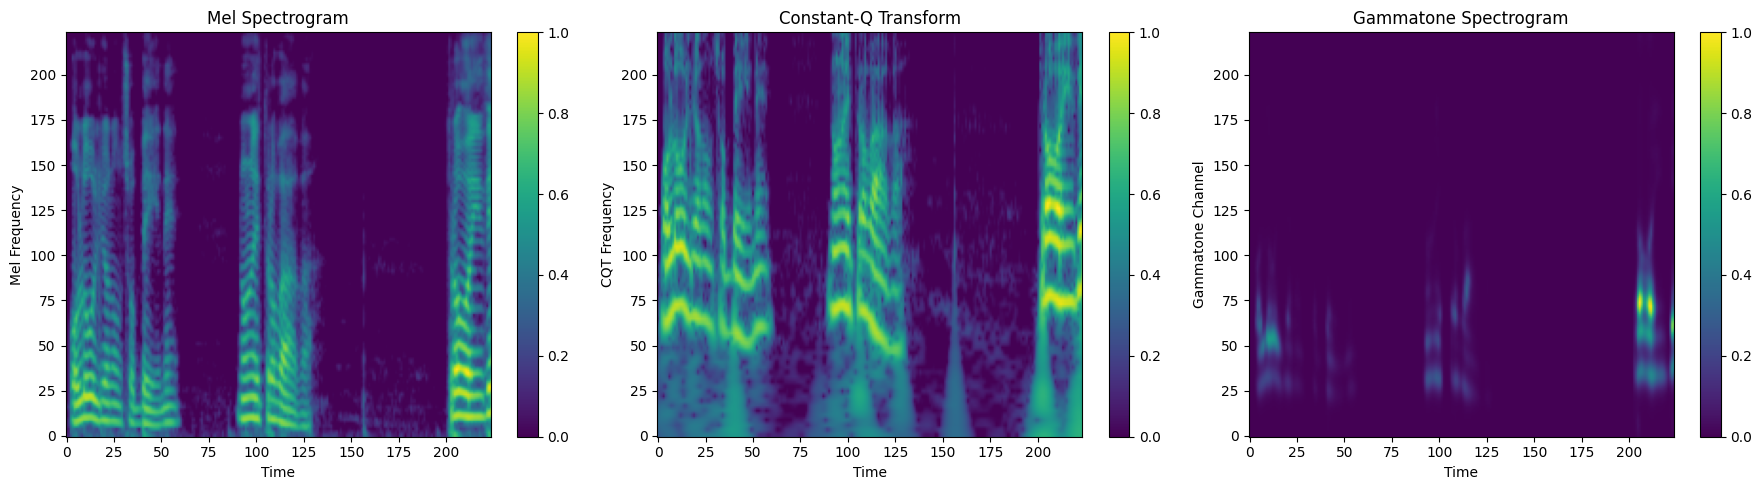

In [39]:
# ============================================================
# 9. VISUALIZE FEATURES
# ============================================================

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)

plt.imshow(
    mel_image,
    aspect="auto",
    origin="lower"
)

plt.title("Mel Spectrogram")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")

plt.colorbar()


plt.subplot(1, 3, 2)

plt.imshow(
    cqt_image,
    aspect="auto",
    origin="lower"
)

plt.title("Constant-Q Transform")
plt.xlabel("Time")
plt.ylabel("CQT Frequency")

plt.colorbar()


plt.subplot(1, 3, 3)

plt.imshow(
    gammatone_image,
    aspect="auto",
    origin="lower"
)

plt.title("Gammatone Spectrogram")
plt.xlabel("Time")
plt.ylabel("Gammatone Channel")

plt.colorbar()


plt.tight_layout()
plt.show()

In [40]:
# ============================================================
# FEATURE VERIFICATION
# ============================================================

features = {
    "Mel": mel_image,
    "CQT": cqt_image,
    "Gammatone": gammatone_image
}

for name, feature in features.items():

    print("\n", name)

    print("Shape :", feature.shape)
    print("Dtype :", feature.dtype)
    print("Min   :", feature.min())
    print("Max   :", feature.max())
    print("NaN   :", np.isnan(feature).any())
    print("Inf   :", np.isinf(feature).any())


 Mel
Shape : (224, 224)
Dtype : float32
Min   : 0.0
Max   : 1.0
NaN   : False
Inf   : False

 CQT
Shape : (224, 224)
Dtype : float32
Min   : 0.0
Max   : 1.0
NaN   : False
Inf   : False

 Gammatone
Shape : (224, 224)
Dtype : float32
Min   : 0.0
Max   : 1.0
NaN   : False
Inf   : False


In [41]:
# ============================================================
# 7. EXTRACT FEATURES
# ============================================================

FEATURE_ROOT = "/kaggle/working/parkinson_features"

TRAIN_FEATURE_DIR = os.path.join(
    FEATURE_ROOT, "train"
)

VAL_FEATURE_DIR = os.path.join(
    FEATURE_ROOT, "validation"
)

TEST_FEATURE_DIR = os.path.join(
    FEATURE_ROOT, "test"
)

os.makedirs(TRAIN_FEATURE_DIR, exist_ok=True)
os.makedirs(VAL_FEATURE_DIR, exist_ok=True)
os.makedirs(TEST_FEATURE_DIR, exist_ok=True)

print("Feature directories created.")

Feature directories created.


In [42]:
# ============================================================
# COMPLETE FEATURE EXTRACTION FUNCTION
# ============================================================

def extract_all_features(audio_path):
    """
    Complete feature extraction pipeline.

    Audio
      ↓
    Preprocessing
      ↓
    Mel
      ↓
    CQT
      ↓
    Gammatone
      ↓
    Resize to 224 x 224
      ↓
    Normalize to [0, 1]
    """

    # --------------------------------------------------------
    # Preprocessing
    # --------------------------------------------------------

    audio = preprocess_audio(
        audio_path
    )

    # --------------------------------------------------------
    # Mel
    # --------------------------------------------------------

    mel = extract_mel_spectrogram(
        audio
    )

    mel = resize_feature(
        mel
    )

    mel = normalize_feature(
        mel
    )

    # --------------------------------------------------------
    # CQT
    # --------------------------------------------------------

    cqt = extract_cqt(
        audio
    )

    cqt = resize_feature(
        cqt
    )

    cqt = normalize_feature(
        cqt
    )

    # --------------------------------------------------------
    # Gammatone
    # --------------------------------------------------------

    gammatone = extract_gammatone(
        audio
    )

    gammatone = resize_feature(
        gammatone
    )

    gammatone = normalize_feature(
        gammatone
    )

    return (
        mel,
        cqt,
        gammatone
    )

In [43]:
# ============================================================
# FEATURE EXTRACTION + STORAGE
# ============================================================

def get_feature_directory(split):

    if split == "train":
        return TRAIN_FEATURE_DIR

    elif split == "validation":
        return VAL_FEATURE_DIR

    elif split == "test":
        return TEST_FEATURE_DIR

    else:
        raise ValueError(
            f"Unknown split: {split}"
        )


feature_records = []

for index, row in tqdm(
    metadata.iterrows(),
    total=len(metadata),
    desc="Extracting features"
):

    audio_path = row["audio_path"]
    split = row["split"]

    feature_dir = get_feature_directory(
        split
    )

    # Unique feature filename
    feature_name = f"{index:05d}.npz"

    feature_path = os.path.join(
        feature_dir,
        feature_name
    )

    # --------------------------------------------------------
    # Skip if already extracted
    # --------------------------------------------------------

    if os.path.exists(feature_path):

        feature_records.append({
            "feature_path": feature_path,
            "subject_id": row["subject_id"],
            "class_name": row["class_name"],
            "label": row["label"],
            "split": row["split"],
            "audio_path": row["audio_path"],
            "filename": row["filename"]
        })

        continue

    # --------------------------------------------------------
    # Extract
    # --------------------------------------------------------

    try:

        mel, cqt, gammatone = (
            extract_all_features(
                audio_path
            )
        )

        # ----------------------------------------------------
        # Save compressed feature file
        # ----------------------------------------------------

        np.savez_compressed(
            feature_path,
            mel=mel,
            cqt=cqt,
            gammatone=gammatone
        )

        feature_records.append({
            "feature_path": feature_path,
            "subject_id": row["subject_id"],
            "class_name": row["class_name"],
            "label": row["label"],
            "split": row["split"],
            "audio_path": row["audio_path"],
            "filename": row["filename"]
        })

    except Exception as e:

        print(
            f"\nError processing:"
            f" {audio_path}"
        )

        print("Error:", e)


feature_metadata = pd.DataFrame(
    feature_records
)

print("\nFeature extraction completed.")

print(
    "Total feature files:",
    len(feature_metadata)
)

Extracting features:   0%|          | 0/785 [00:00<?, ?it/s]


Feature extraction completed.
Total feature files: 785


In [44]:
# ============================================================
# 8. VERIFY EXTRACTED FEATURES
# ============================================================

print(
    "Feature metadata shape:",
    feature_metadata.shape
)

print("\nFeatures by split:")

print(
    feature_metadata["split"]
    .value_counts()
)

print("\nFeatures by class:")

print(
    feature_metadata["class_name"]
    .value_counts()
)

Feature metadata shape: (785, 7)

Features by split:
split
train         471
validation    160
test          154
Name: count, dtype: int64

Features by class:
class_name
28 People with PD             436
22 Elderly Healthy Control    349
Name: count, dtype: int64


In [45]:
# ============================================================
# VERIFY ONE SAVED FEATURE FILE
# ============================================================

sample_feature_path = (
    feature_metadata.iloc[0]["feature_path"]
)

sample_features = np.load(
    sample_feature_path
)

print(
    "Available arrays:",
    sample_features.files
)

mel = sample_features["mel"]
cqt = sample_features["cqt"]
gammatone = sample_features["gammatone"]

print("\nMel:")
print("Shape:", mel.shape)
print("Min:", mel.min())
print("Max:", mel.max())

print("\nCQT:")
print("Shape:", cqt.shape)
print("Min:", cqt.min())
print("Max:", cqt.max())

print("\nGammatone:")
print("Shape:", gammatone.shape)
print("Min:", gammatone.min())
print("Max:", gammatone.max())

Available arrays: ['mel', 'cqt', 'gammatone']

Mel:
Shape: (224, 224)
Min: 0.0
Max: 1.0

CQT:
Shape: (224, 224)
Min: 0.0
Max: 1.0

Gammatone:
Shape: (224, 224)
Min: 0.0
Max: 1.0


In [46]:
# ============================================================
# VERIFY ALL FEATURE FILES
# ============================================================

invalid_files = []

for feature_path in tqdm(
    feature_metadata["feature_path"],
    desc="Checking features"
):

    try:

        data = np.load(
            feature_path
        )

        for feature_name in [
            "mel",
            "cqt",
            "gammatone"
        ]:

            feature = data[
                feature_name
            ]

            # Shape check
            if feature.shape != (
                CFG.IMAGE_SIZE,
                CFG.IMAGE_SIZE
            ):
                invalid_files.append({
                    "path": feature_path,
                    "feature": feature_name,
                    "reason": "incorrect shape"
                })

            # NaN check
            if np.isnan(feature).any():
                invalid_files.append({
                    "path": feature_path,
                    "feature": feature_name,
                    "reason": "NaN"
                })

            # Inf check
            if np.isinf(feature).any():
                invalid_files.append({
                    "path": feature_path,
                    "feature": feature_name,
                    "reason": "Inf"
                })

    except Exception as e:

        invalid_files.append({
            "path": feature_path,
            "feature": "all",
            "reason": str(e)
        })


print(
    "Invalid feature files:",
    len(invalid_files)
)

if len(invalid_files) == 0:

    print(
        "✓ ALL FEATURE FILES PASSED VERIFICATION"
    )

else:

    display(
        pd.DataFrame(
            invalid_files
        ).head(20)
    )

Checking features:   0%|          | 0/785 [00:00<?, ?it/s]

Invalid feature files: 0
✓ ALL FEATURE FILES PASSED VERIFICATION


In [47]:
# ============================================================
# SAVE FEATURE METADATA
# ============================================================

FEATURE_METADATA_PATH = (
    "/kaggle/working/"
    "parkinson_feature_metadata.csv"
)

feature_metadata.to_csv(
    FEATURE_METADATA_PATH,
    index=False
)

print(
    "Feature metadata saved to:"
)

print(
    FEATURE_METADATA_PATH
)

Feature metadata saved to:
/kaggle/working/parkinson_feature_metadata.csv


In [48]:
# ============================================================
# CREATE SPLIT DATAFRAMES
# ============================================================

train_df = feature_metadata[
    feature_metadata["split"] == "train"
].reset_index(drop=True)

val_df = feature_metadata[
    feature_metadata["split"] == "validation"
].reset_index(drop=True)

test_df = feature_metadata[
    feature_metadata["split"] == "test"
].reset_index(drop=True)


print("Train samples      :", len(train_df))
print("Validation samples :", len(val_df))
print("Test samples       :", len(test_df))

Train samples      : 471
Validation samples : 160
Test samples       : 154


In [49]:
# ============================================================
# SPEC AUGMENTATION
# ============================================================

def spec_augment(
    spec,
    time_mask_param=20,
    freq_mask_param=15,
    num_time_masks=2,
    num_freq_masks=2
):

    spec = spec.clone()

    _, height, width = spec.shape

    # --------------------------------------------------------
    # Frequency masking
    # --------------------------------------------------------

    for _ in range(num_freq_masks):

        mask_width = torch.randint(
            0,
            min(freq_mask_param, height) + 1,
            (1,)
        ).item()

        if mask_width > 0:

            start = torch.randint(
                0,
                height - mask_width + 1,
                (1,)
            ).item()

            spec[
                :,
                start:start + mask_width,
                :
            ] = 0.0

    # --------------------------------------------------------
    # Time masking
    # --------------------------------------------------------

    for _ in range(num_time_masks):

        mask_width = torch.randint(
            0,
            min(time_mask_param, width) + 1,
            (1,)
        ).item()

        if mask_width > 0:

            start = torch.randint(
                0,
                width - mask_width + 1,
                (1,)
            ).item()

            spec[
                :,
                :,
                start:start + mask_width
            ] = 0.0

    return spec

In [50]:
# ============================================================
# 14. DATASET
# ============================================================

class ParkinsonFeatureDataset(Dataset):

    def __init__(
        self,
        dataframe,
        training=False
    ):

        self.dataframe = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.training = training

        print(
            f"Dataset initialized with "
            f"{len(self.dataframe)} samples."
        )

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        # ----------------------------------------------------
        # Load saved feature file
        # ----------------------------------------------------

        feature_data = np.load(
            row["feature_path"]
        )

        mel = feature_data["mel"]
        cqt = feature_data["cqt"]
        gammatone = feature_data["gammatone"]

        # ----------------------------------------------------
        # Convert NumPy → Torch
        # ----------------------------------------------------

        mel = torch.tensor(
            mel,
            dtype=torch.float32
        ).unsqueeze(0)

        cqt = torch.tensor(
            cqt,
            dtype=torch.float32
        ).unsqueeze(0)

        gammatone = torch.tensor(
            gammatone,
            dtype=torch.float32
        ).unsqueeze(0)

        # ----------------------------------------------------
        # SPEC AUGMENTATION
        # TRAINING ONLY
        # ----------------------------------------------------

        if self.training:

            mel = spec_augment(mel)

            cqt = spec_augment(cqt)

            gammatone = spec_augment(
                gammatone
            )

        # ----------------------------------------------------
        # Label
        # ----------------------------------------------------

        label = torch.tensor(
            row["label"],
            dtype=torch.long
        )

        # ----------------------------------------------------
        # Return
        # ----------------------------------------------------

        return {
            "mel": mel,
            "cqt": cqt,
            "gammatone": gammatone,
            "label": label,
            "subject_id": row["subject_id"],
            "feature_path": row["feature_path"]
        }

In [51]:
# ============================================================
# CREATE DATASET OBJECTS
# ============================================================

train_dataset = ParkinsonFeatureDataset(
    train_df,
    training=True
)

val_dataset = ParkinsonFeatureDataset(
    val_df,
    training=False
)

test_dataset = ParkinsonFeatureDataset(
    test_df,
    training=False
)

print("\nDataset configuration:")
print("Train       : augmentation ON")
print("Validation  : augmentation OFF")
print("Test        : augmentation OFF")

Dataset initialized with 471 samples.
Dataset initialized with 160 samples.
Dataset initialized with 154 samples.

Dataset configuration:
Train       : augmentation ON
Validation  : augmentation OFF
Test        : augmentation OFF


In [52]:
# ============================================================
# VERIFY SUBJECT DISTRIBUTION AFTER FEATURE EXTRACTION
# ============================================================

for name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:

    subjects_in_split = (
        df[
            ["subject_id", "label"]
        ]
        .drop_duplicates()
    )

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(
        "Subjects:",
        len(subjects_in_split)
    )

    print(
        subjects_in_split["label"]
        .value_counts()
        .sort_index()
    )


Train
Subjects: 30
label
0    13
1    17
Name: count, dtype: int64

Validation
Subjects: 10
label
0    5
1    5
Name: count, dtype: int64

Test
Subjects: 10
label
0    4
1    6
Name: count, dtype: int64


In [53]:
# ============================================================
# VERIFY DATASET SAMPLE
# ============================================================

sample = train_dataset[0]

print("Mel:")
print("  Shape:", sample["mel"].shape)
print("  Dtype:", sample["mel"].dtype)

print("\nCQT:")
print("  Shape:", sample["cqt"].shape)
print("  Dtype:", sample["cqt"].dtype)

print("\nGammatone:")
print("  Shape:", sample["gammatone"].shape)
print("  Dtype:", sample["gammatone"].dtype)

print("\nLabel:")
print(" ", sample["label"])

print("\nSubject:")
print(" ", sample["subject_id"])

Mel:
  Shape: torch.Size([1, 224, 224])
  Dtype: torch.float32

CQT:
  Shape: torch.Size([1, 224, 224])
  Dtype: torch.float32

Gammatone:
  Shape: torch.Size([1, 224, 224])
  Dtype: torch.float32

Label:
  tensor(1)

Subject:
  11-16_Anna B


In [54]:
train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train recordings:", len(train_dataset))
print("Validation recordings:", len(val_dataset))
print("Test recordings:", len(test_dataset))

Train recordings: 471
Validation recordings: 160
Test recordings: 154


In [55]:
# ============================================================
# VERIFY TRAINING BATCH
# ============================================================

batch = next(
    iter(train_loader)
)

print("Mel batch:")
print(
    batch["mel"].shape
)

print("\nCQT batch:")
print(
    batch["cqt"].shape
)

print("\nGammatone batch:")
print(
    batch["gammatone"].shape
)

print("\nLabels:")
print(
    batch["label"].shape
)

print("\nLabel values:")
print(
    batch["label"]
)

Mel batch:
torch.Size([8, 1, 224, 224])

CQT batch:
torch.Size([8, 1, 224, 224])

Gammatone batch:
torch.Size([8, 1, 224, 224])

Labels:
torch.Size([8])

Label values:
tensor([1, 0, 1, 1, 0, 1, 1, 1])


In [56]:
# ============================================================
# GPU BATCH TEST
# ============================================================

mel_batch = batch["mel"].to(
    device,
    non_blocking=True
)

cqt_batch = batch["cqt"].to(
    device,
    non_blocking=True
)

gammatone_batch = batch["gammatone"].to(
    device,
    non_blocking=True
)

labels_batch = batch["label"].to(
    device,
    non_blocking=True
)

print("Mel device:", mel_batch.device)
print("CQT device:", cqt_batch.device)
print(
    "Gammatone device:",
    gammatone_batch.device
)
print("Labels device:", labels_batch.device)

Mel device: cuda:0
CQT device: cuda:0
Gammatone device: cuda:0
Labels device: cuda:0


In [57]:
# ============================================================
# COMPLETE DATA PIPELINE CHECK
# ============================================================

print("=" * 70)
print("DATA PIPELINE CHECK")
print("=" * 70)

print(
    "Train recordings:",
    len(train_dataset)
)

print(
    "Validation recordings:",
    len(val_dataset)
)

print(
    "Test recordings:",
    len(test_dataset)
)

print("\nInput representation shapes:")

print(
    "Mel:",
    tuple(batch["mel"].shape)
)

print(
    "CQT:",
    tuple(batch["cqt"].shape)
)

print(
    "Gammatone:",
    tuple(batch["gammatone"].shape)
)

print("\n✓ Dataset ready")
print("✓ DataLoaders ready")
print("✓ Three representations preserved separately")

DATA PIPELINE CHECK
Train recordings: 471
Validation recordings: 160
Test recordings: 154

Input representation shapes:
Mel: (8, 1, 224, 224)
CQT: (8, 1, 224, 224)
Gammatone: (8, 1, 224, 224)

✓ Dataset ready
✓ DataLoaders ready
✓ Three representations preserved separately


In [58]:
# ============================================================
# 16. CSRLM
# BACKBONE
# ============================================================

import torchvision

from torchvision.models import (
    mobilenet_v3_small,
    MobileNet_V3_Small_Weights
)

print(
    "Torchvision version:",
    torchvision.__version__
)

Torchvision version: 0.25.0+cu128


In [59]:
# ============================================================
# MOBILENETV3-SMALL BACKBONE
# ============================================================

weights = (
    MobileNet_V3_Small_Weights.DEFAULT
)

backbone = mobilenet_v3_small(
    weights=weights
)

print(backbone)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 155MB/s]

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [60]:
# ============================================================
# BACKBONE FEATURE EXTRACTOR
# ============================================================

backbone_features = backbone.features

print(
    backbone_features
)

Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
    (2): Hardswish()
  )
  (1): InvertedResidual(
    (block): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (1): SqueezeExcitation(
        (avgpool): AdaptiveAvgPool2d(output_size=1)
        (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
        (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
        (activation): ReLU()
        (scale_activation): Hardsigmoid()
      )
      (2): Conv2dNormActivation(
        (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, mo

In [61]:
# ============================================================
# SINGLE-CHANNEL → 3-CHANNEL PROJECTION
# ============================================================

class InputProjection(nn.Module):

    def __init__(self):
        super().__init__()

        self.projection = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=3,
                kernel_size=1,
                stride=1,
                padding=0,
                bias=False
            ),

            nn.BatchNorm2d(3),

            nn.GELU()
        )

    def forward(self, x):

        return self.projection(x)

In [62]:
# ============================================================
# CSRLM
# CHANNEL-SPATIAL REPRESENTATION LEARNING MODULE
# ============================================================

class CSRLM(nn.Module):

    def __init__(
        self,
        channels,
        reduction=4,
        dropout=CFG.DROPOUT_ATTENTION
    ):
        super().__init__()

        hidden_channels = max(
            channels // reduction,
            8
        )

        # ----------------------------------------------------
        # Channel attention
        # ----------------------------------------------------

        self.channel_attention = nn.Sequential(

            nn.AdaptiveAvgPool2d(1),

            nn.Conv2d(
                channels,
                hidden_channels,
                kernel_size=1,
                bias=False
            ),

            nn.GELU(),

            nn.Conv2d(
                hidden_channels,
                channels,
                kernel_size=1,
                bias=False
            ),

            nn.Sigmoid()
        )

        # ----------------------------------------------------
        # Spatial attention
        # ----------------------------------------------------

        self.spatial_attention = nn.Sequential(

            nn.Conv2d(
                2,
                1,
                kernel_size=7,
                padding=3,
                bias=False
            ),

            nn.Sigmoid()
        )

        self.dropout = nn.Dropout2d(
            dropout
        )

    def forward(self, x):

        # ----------------------------------------------------
        # Channel attention
        # ----------------------------------------------------

        channel_weights = (
            self.channel_attention(x)
        )

        x_channel = (
            x * channel_weights
        )

        # ----------------------------------------------------
        # Spatial attention
        # ----------------------------------------------------

        avg_map = torch.mean(
            x_channel,
            dim=1,
            keepdim=True
        )

        max_map = torch.max(
            x_channel,
            dim=1,
            keepdim=True
        )[0]

        spatial_input = torch.cat(
            [
                avg_map,
                max_map
            ],
            dim=1
        )

        spatial_weights = (
            self.spatial_attention(
                spatial_input
            )
        )

        x_spatial = (
            x_channel *
            spatial_weights
        )

        # ----------------------------------------------------
        # Residual connection
        # ----------------------------------------------------

        output = (
            x + self.dropout(x_spatial)
        )

        return output

In [63]:
# ============================================================
# TEST CSRLM
# ============================================================

test_csrLM = CSRLM(
    channels=576
).to(device)

dummy_input = torch.randn(
    2,
    576,
    7,
    7
).to(device)

dummy_output = test_csrLM(
    dummy_input
)

print(
    "Input shape :",
    dummy_input.shape
)

print(
    "Output shape:",
    dummy_output.shape
)

Input shape : torch.Size([2, 576, 7, 7])
Output shape: torch.Size([2, 576, 7, 7])


In [64]:
# ============================================================
# 17. FIEM
# FEATURE INTERACTION ENHANCEMENT MODULE
# ============================================================

class FIEM(nn.Module):

    def __init__(
        self,
        in_channels=576,
        fusion_dim=CFG.FUSION_DIM,
        dropout=CFG.DROPOUT_FUSION
    ):
        super().__init__()

        # Three feature representations are concatenated
        # 576 + 576 + 576 = 1728 channels

        total_channels = in_channels * 3

        self.interaction = nn.Sequential(

            nn.Conv2d(
                total_channels,
                fusion_dim * 2,
                kernel_size=1,
                stride=1,
                padding=0,
                bias=False
            ),

            nn.BatchNorm2d(
                fusion_dim * 2
            ),

            nn.GELU(),

            nn.Dropout2d(
                dropout
            ),

            nn.Conv2d(
                fusion_dim * 2,
                fusion_dim,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                fusion_dim
            ),

            nn.GELU()
        )

    def forward(
        self,
        mel_features,
        cqt_features,
        gammatone_features
    ):

        # ----------------------------------------------------
        # Concatenate three representations
        # ----------------------------------------------------

        combined = torch.cat(
            [
                mel_features,
                cqt_features,
                gammatone_features
            ],
            dim=1
        )

        # ----------------------------------------------------
        # Learn interactions
        # ----------------------------------------------------

        output = self.interaction(
            combined
        )

        return output

In [65]:
# ============================================================
# TEST FIEM
# ============================================================

test_fiem = FIEM(
    in_channels=576,
    fusion_dim=CFG.FUSION_DIM
).to(device)

mel_test = torch.randn(
    2, 576, 7, 7
).to(device)

cqt_test = torch.randn(
    2, 576, 7, 7
).to(device)

gammatone_test = torch.randn(
    2, 576, 7, 7
).to(device)

fiem_output = test_fiem(
    mel_test,
    cqt_test,
    gammatone_test
)

print("Mel input       :", mel_test.shape)
print("CQT input       :", cqt_test.shape)
print("Gammatone input :", gammatone_test.shape)
print("FIEM output     :", fiem_output.shape)

Mel input       : torch.Size([2, 576, 7, 7])
CQT input       : torch.Size([2, 576, 7, 7])
Gammatone input : torch.Size([2, 576, 7, 7])
FIEM output     : torch.Size([2, 96, 7, 7])


In [66]:
# ============================================================
# 18. ASFM
# ADAPTIVE SEMANTIC FEATURE FUSION MODULE
# ============================================================

class ASFM(nn.Module):

    def __init__(
        self,
        channels=CFG.FUSION_DIM,
        dropout=CFG.DROPOUT_FUSION
    ):
        super().__init__()

        # ----------------------------------------------------
        # Channel attention
        # ----------------------------------------------------

        hidden = max(
            channels // 4,
            8
        )

        self.channel_attention = nn.Sequential(

            nn.AdaptiveAvgPool2d(1),

            nn.Conv2d(
                channels,
                hidden,
                kernel_size=1,
                bias=False
            ),

            nn.GELU(),

            nn.Conv2d(
                hidden,
                channels,
                kernel_size=1,
                bias=False
            ),

            nn.Sigmoid()
        )

        # ----------------------------------------------------
        # Spatial attention
        # ----------------------------------------------------

        self.spatial_attention = nn.Sequential(

            nn.Conv2d(
                2,
                1,
                kernel_size=7,
                padding=3,
                bias=False
            ),

            nn.Sigmoid()
        )

        self.dropout = nn.Dropout2d(
            dropout
        )

    def forward(self, x):

        # ----------------------------------------------------
        # Channel weighting
        # ----------------------------------------------------

        channel_weights = (
            self.channel_attention(x)
        )

        channel_refined = (
            x * channel_weights
        )

        # ----------------------------------------------------
        # Spatial weighting
        # ----------------------------------------------------

        avg_map = torch.mean(
            channel_refined,
            dim=1,
            keepdim=True
        )

        max_map = torch.max(
            channel_refined,
            dim=1,
            keepdim=True
        )[0]

        spatial_input = torch.cat(
            [
                avg_map,
                max_map
            ],
            dim=1
        )

        spatial_weights = (
            self.spatial_attention(
                spatial_input
            )
        )

        spatial_refined = (
            channel_refined *
            spatial_weights
        )

        # ----------------------------------------------------
        # Residual refinement
        # ----------------------------------------------------

        output = (
            x +
            self.dropout(spatial_refined)
        )

        return output

In [67]:
# ============================================================
# TEST ASFM
# ============================================================

test_asfm = ASFM(
    channels=CFG.FUSION_DIM
).to(device)

asfm_input = torch.randn(
    2,
    CFG.FUSION_DIM,
    7,
    7
).to(device)

asfm_output = test_asfm(
    asfm_input
)

print(
    "ASFM input :",
    asfm_input.shape
)

print(
    "ASFM output:",
    asfm_output.shape
)

ASFM input : torch.Size([2, 96, 7, 7])
ASFM output: torch.Size([2, 96, 7, 7])


In [68]:
# ============================================================
# 19. FFRM
# FINAL FEATURE REFINEMENT MODULE
# ============================================================

class FFRM(nn.Module):

    def __init__(
        self,
        channels=CFG.FUSION_DIM,
        dropout=CFG.DROPOUT_FUSION
    ):
        super().__init__()

        self.refinement = nn.Sequential(

            # Depthwise spatial refinement
            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                padding=1,
                groups=channels,
                bias=False
            ),

            nn.BatchNorm2d(
                channels
            ),

            nn.GELU(),

            # Pointwise channel mixing
            nn.Conv2d(
                channels,
                channels,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(
                channels
            ),

            nn.GELU(),

            nn.Dropout2d(
                dropout
            )
        )

    def forward(self, x):

        refined = self.refinement(x)

        return x + refined

In [69]:
# ============================================================
# TEST FFRM
# ============================================================

test_ffrm = FFRM(
    channels=CFG.FUSION_DIM
).to(device)

ffrm_input = torch.randn(
    2,
    CFG.FUSION_DIM,
    7,
    7
).to(device)

ffrm_output = test_ffrm(
    ffrm_input
)

print(
    "FFRM input :",
    ffrm_input.shape
)

print(
    "FFRM output:",
    ffrm_output.shape
)

FFRM input : torch.Size([2, 96, 7, 7])
FFRM output: torch.Size([2, 96, 7, 7])


In [70]:
# ============================================================
# 20. CLASSIFICATION HEAD
# ============================================================

class ClassificationHead(nn.Module):

    def __init__(
        self,
        in_channels=CFG.FUSION_DIM,
        num_classes=CFG.NUM_CLASSES,
        dropout=CFG.DROPOUT_CLASSIFIER
    ):
        super().__init__()

        self.pool = nn.AdaptiveAvgPool2d(
            1
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                in_channels,
                64
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                64,
                num_classes
            )
        )

    def forward(self, x):

        x = self.pool(x)

        output = self.classifier(x)

        return output

In [71]:
# ============================================================
# TEST CLASSIFICATION HEAD
# ============================================================

test_head = ClassificationHead().to(device)

head_input = torch.randn(
    2,
    CFG.FUSION_DIM,
    7,
    7
).to(device)

head_output = test_head(
    head_input
)

print(
    "Input :",
    head_input.shape
)

print(
    "Output:",
    head_output.shape
)

Input : torch.Size([2, 96, 7, 7])
Output: torch.Size([2, 2])


In [72]:

# ============================================================
# 21. PARKINSONNET
# ============================================================

class ParkinsonNet(nn.Module):

    def __init__(
        self,
        num_classes=CFG.NUM_CLASSES
    ):
        super().__init__()

        # ----------------------------------------------------
        # Input projections
        # ----------------------------------------------------

        self.mel_projection = (
            InputProjection()
        )

        self.cqt_projection = (
            InputProjection()
        )

        self.gammatone_projection = (
            InputProjection()
        )

        # ----------------------------------------------------
        # ImageNet normalization (applied after projection to
        # 3 channels, before the pretrained backbone). MobileNetV3
        # was pretrained on ImageNet-normalized inputs; without this,
        # the pretrained features are used slightly out-of-distribution.
        #
        # NOTE: the projection output is not literally a natural image
        # (it's a learned 1x1 conv + BN + GELU over a spectrogram), so
        # this normalization is an approximation, not a guarantee of
        # matching ImageNet statistics exactly. Watch val loss after
        # this change -- if it doesn't help, it's safe to remove.
        # ----------------------------------------------------

        self.register_buffer(
            "imagenet_mean",
            torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        )

        self.register_buffer(
            "imagenet_std",
            torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        )

        # ----------------------------------------------------
        # Shared MobileNetV3-Small
        # ----------------------------------------------------

        weights = (
            MobileNet_V3_Small_Weights.DEFAULT
        )

        backbone = mobilenet_v3_small(
            weights=weights
        )

        self.backbone = backbone.features

        # MobileNetV3-Small output channels
        self.feature_dim = 576

        # ----------------------------------------------------
        # CSRLM
        # ----------------------------------------------------

        self.csrLM_mel = CSRLM(
            channels=self.feature_dim,
            dropout=CFG.DROPOUT_ATTENTION
        )

        self.csrLM_cqt = CSRLM(
            channels=self.feature_dim,
            dropout=CFG.DROPOUT_ATTENTION
        )

        self.csrLM_gammatone = CSRLM(
            channels=self.feature_dim,
            dropout=CFG.DROPOUT_ATTENTION
        )

        # ----------------------------------------------------
        # FIEM
        # ----------------------------------------------------

        self.fiem = FIEM(
            in_channels=self.feature_dim,
            fusion_dim=CFG.FUSION_DIM,
            dropout=CFG.DROPOUT_FUSION
        )

        # ----------------------------------------------------
        # ASFM
        # ----------------------------------------------------

        self.asfm = ASFM(
            channels=CFG.FUSION_DIM,
            dropout=CFG.DROPOUT_FUSION
        )

        # ----------------------------------------------------
        # FFRM
        # ----------------------------------------------------

        self.ffrm = FFRM(
            channels=CFG.FUSION_DIM,
            dropout=CFG.DROPOUT_FUSION
        )

        # ----------------------------------------------------
        # Classification head
        # ----------------------------------------------------

        self.classifier = ClassificationHead(
            in_channels=CFG.FUSION_DIM,
            num_classes=num_classes,
            dropout=CFG.DROPOUT_CLASSIFIER
        )

    def _normalize(self, x):

        return (x - self.imagenet_mean) / self.imagenet_std

    def forward(
        self,
        mel,
        cqt,
        gammatone
    ):

        # ====================================================
        # MEL BRANCH
        # ====================================================

        mel = self.mel_projection(
            mel
        )

        mel = self._normalize(mel)

        mel = self.backbone(
            mel
        )

        mel = self.csrLM_mel(
            mel
        )

        # ====================================================
        # CQT BRANCH
        # ====================================================

        cqt = self.cqt_projection(
            cqt
        )

        cqt = self._normalize(cqt)

        cqt = self.backbone(
            cqt
        )

        cqt = self.csrLM_cqt(
            cqt
        )

        # ====================================================
        # GAMMATONE BRANCH
        # ====================================================

        gammatone = (
            self.gammatone_projection(
                gammatone
            )
        )

        gammatone = self._normalize(gammatone)

        gammatone = self.backbone(
            gammatone
        )

        gammatone = (
            self.csrLM_gammatone(
                gammatone
            )
        )

        # ====================================================
        # FIEM
        # ====================================================

        fused = self.fiem(
            mel,
            cqt,
            gammatone
        )

        # ====================================================
        # ASFM
        # ====================================================

        fused = self.asfm(
            fused
        )

        # ====================================================
        # FFRM
        # ====================================================

        fused = self.ffrm(
            fused
        )

        # ====================================================
        # CLASSIFICATION
        # ====================================================

        logits = self.classifier(
            fused
        )

        return logits


In [73]:
# ============================================================
# 22. MODEL VERIFICATION
# ============================================================

model = ParkinsonNet(
    num_classes=CFG.NUM_CLASSES
).to(device)

print(
    "ParkinsonNet created."
)

ParkinsonNet created.


In [74]:
# ============================================================
# COMPLETE FORWARD PASS TEST
# ============================================================

model.eval()

with torch.no_grad():

    output = model(
        batch["mel"].to(device),
        batch["cqt"].to(device),
        batch["gammatone"].to(device)
    )

print(
    "Mel input:",
    batch["mel"].shape
)

print(
    "CQT input:",
    batch["cqt"].shape
)

print(
    "Gammatone input:",
    batch["gammatone"].shape
)

print(
    "Model output:",
    output.shape
)

print(
    "Output logits:"
)

print(output)

Mel input: torch.Size([8, 1, 224, 224])
CQT input: torch.Size([8, 1, 224, 224])
Gammatone input: torch.Size([8, 1, 224, 224])
Model output: torch.Size([8, 2])
Output logits:
tensor([[-0.0177,  0.0818],
        [-0.0216,  0.0869],
        [-0.0243,  0.0831],
        [-0.0194,  0.0812],
        [-0.0211,  0.0905],
        [-0.0198,  0.0855],
        [-0.0196,  0.0888],
        [-0.0234,  0.0892]], device='cuda:0')


In [75]:
# ============================================================
# PREDICTION TEST
# ============================================================

probabilities = torch.softmax(
    output,
    dim=1
)

predictions = torch.argmax(
    probabilities,
    dim=1
)

print(
    "Probabilities shape:",
    probabilities.shape
)

print(
    "\nPredicted classes:"
)

print(
    predictions
)

print(
    "\nProbabilities:"
)

print(
    probabilities
)

Probabilities shape: torch.Size([8, 2])

Predicted classes:
tensor([1, 1, 1, 1, 1, 1, 1, 1], device='cuda:0')

Probabilities:
tensor([[0.4751, 0.5249],
        [0.4729, 0.5271],
        [0.4732, 0.5268],
        [0.4749, 0.5251],
        [0.4721, 0.5279],
        [0.4737, 0.5263],
        [0.4729, 0.5271],
        [0.4719, 0.5281]], device='cuda:0')


In [76]:
# ============================================================
# MODEL PARAMETER COUNT
# ============================================================

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total parameters: "
    f"{total_parameters:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_parameters:,}"
)

Total parameters: 1,944,741
Trainable parameters: 1,944,741


In [77]:
# ============================================================
# 23. LOSS / OPTIMIZER / SCHEDULER
# CLASS WEIGHTS
# ============================================================

train_class_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)

print("Training class counts:")
print(train_class_counts)

num_classes = CFG.NUM_CLASSES
total_train_samples = len(train_df)

class_weights = (
    total_train_samples /
    (
        num_classes *
        train_class_counts.values
    )
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

print("\nClass weights:")
print(class_weights)

Training class counts:
label
0    205
1    266
Name: count, dtype: int64

Class weights:
tensor([1.1488, 0.8853], device='cuda:0')


In [78]:
# ============================================================
# BACKBONE FREEZE/UNFREEZE HELPER
# ============================================================
#
# requires_grad = False alone does NOT stop BatchNorm layers from
# updating running_mean / running_var during a forward pass in
# train() mode. model.train() is called every epoch, which puts
# the "frozen" backbone's BatchNorm into training mode too --
# corrupting pretrained ImageNet running stats using a mix of
# mel / CQT / gammatone feature distributions, even though the
# conv weights themselves never update.
#
# This helper freezes weights AND BatchNorm running stats together,
# and unfreezes both together at CFG.UNFREEZE_EPOCH.

def set_backbone_mode(model, trainable):

    for parameter in model.backbone.parameters():
        parameter.requires_grad = trainable

    if trainable:
        model.backbone.train()
    else:
        model.backbone.eval()


In [79]:
# ============================================================
# FREEZE BACKBONE INITIALLY
# ============================================================

set_backbone_mode(model, trainable=False)

print("MobileNetV3 backbone frozen (weights AND BatchNorm running stats).")

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Trainable parameters initially: "
    f"{trainable_parameters:,}"
)


MobileNetV3 backbone frozen (weights AND BatchNorm running stats).
Trainable parameters initially: 1,017,733


In [80]:
# ============================================================
# LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=CFG.LABEL_SMOOTHING
)

print("Loss function:")
print(criterion)

Loss function:
CrossEntropyLoss()


In [81]:
# ============================================================
# OPTIMIZER
# ============================================================

backbone_parameters = list(
    model.backbone.parameters()
)

new_parameters = []

for name, parameter in model.named_parameters():

    if not name.startswith(
        "backbone."
    ):
        new_parameters.append(
            parameter
        )

optimizer = torch.optim.AdamW(
    [
        {
            "params": new_parameters,
            "lr": CFG.LEARNING_RATE
        },

        {
            "params": backbone_parameters,
            "lr": CFG.BACKBONE_LR
        }
    ],
    weight_decay=CFG.WEIGHT_DECAY
)

print("AdamW optimizer created.")

for i, group in enumerate(
    optimizer.param_groups
):

    print(
        f"Parameter group {i}: "
        f"lr = {group['lr']}"
    )

AdamW optimizer created.
Parameter group 0: lr = 0.0003
Parameter group 1: lr = 2e-06


In [82]:
# ============================================================
# COSINE ANNEALING
# ============================================================

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CFG.EPOCHS,
    eta_min=1e-7
)

print(
    "CosineAnnealingLR created."
)

CosineAnnealingLR created.


In [83]:
# ============================================================
# MIXED PRECISION
# ============================================================

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

print(
    "Mixed precision enabled:",
    torch.cuda.is_available()
)

Mixed precision enabled: True


In [84]:
# ============================================================
# OPTIMIZER VERIFICATION
# ============================================================

print("=" * 60)
print("TRAINING CONFIGURATION")
print("=" * 60)

print(
    "Epochs:",
    CFG.EPOCHS
)

print(
    "Batch size:",
    CFG.BATCH_SIZE
)

print(
    "Main learning rate:",
    CFG.LEARNING_RATE
)

print(
    "Backbone learning rate:",
    CFG.BACKBONE_LR
)

print(
    "Weight decay:",
    CFG.WEIGHT_DECAY
)

print(
    "Label smoothing:",
    CFG.LABEL_SMOOTHING
)

print(
    "Early stopping patience:",
    CFG.EARLY_STOPPING_PATIENCE
)

print(
    "Backbone unfreeze epoch:",
    CFG.UNFREEZE_EPOCH
)

TRAINING CONFIGURATION
Epochs: 40
Batch size: 8
Main learning rate: 0.0003
Backbone learning rate: 2e-06
Weight decay: 0.002
Label smoothing: 0.1
Early stopping patience: 8
Backbone unfreeze epoch: 100


In [85]:
# ============================================================
# 41. SUBJECT-LEVEL LEAKAGE CHECK
# ============================================================

train_subjects = set(
    train_df["subject_id"].unique()
)

val_subjects = set(
    val_df["subject_id"].unique()
)

test_subjects = set(
    test_df["subject_id"].unique()
)

print("=" * 70)
print("SUBJECT-LEVEL LEAKAGE CHECK")
print("=" * 70)

# ------------------------------------------------------------
# Train vs Validation
# ------------------------------------------------------------

train_val_overlap = (
    train_subjects &
    val_subjects
)

# ------------------------------------------------------------
# Train vs Test
# ------------------------------------------------------------

train_test_overlap = (
    train_subjects &
    test_subjects
)

# ------------------------------------------------------------
# Validation vs Test
# ------------------------------------------------------------

val_test_overlap = (
    val_subjects &
    test_subjects
)

print(
    "Train ∩ Validation:",
    train_val_overlap
)

print(
    "Train ∩ Test:",
    train_test_overlap
)

print(
    "Validation ∩ Test:",
    val_test_overlap
)

if (
    len(train_val_overlap) == 0
    and
    len(train_test_overlap) == 0
    and
    len(val_test_overlap) == 0
):

    print(
        "\n✓ PASS: No subject appears in multiple splits."
    )

else:

    print(
        "\n✗ WARNING: Subject overlap detected!"
    )

SUBJECT-LEVEL LEAKAGE CHECK
Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()

✓ PASS: No subject appears in multiple splits.


In [86]:
# ============================================================
# 42. EACH SUBJECT MUST BELONG TO ONLY ONE SPLIT
# ============================================================

split_subject_df = metadata[
    [
        "subject_id",
        "split"
    ]
].drop_duplicates()

subject_split_counts = (
    split_subject_df
    .groupby("subject_id")["split"]
    .nunique()
)

subjects_in_multiple_splits = (
    subject_split_counts[
        subject_split_counts > 1
    ]
)

print("=" * 70)
print("SUBJECT → SPLIT CONSISTENCY CHECK")
print("=" * 70)

print(
    "Total subjects:",
    len(subject_split_counts)
)

print(
    "Subjects appearing in multiple splits:",
    len(subjects_in_multiple_splits)
)

if len(subjects_in_multiple_splits) == 0:

    print(
        "\n✓ PASS: Every subject belongs to exactly one split."
    )

else:

    print(
        "\n✗ WARNING: Some subjects occur in multiple splits."
    )

    print(
        subjects_in_multiple_splits
    )

SUBJECT → SPLIT CONSISTENCY CHECK
Total subjects: 50
Subjects appearing in multiple splits: 0

✓ PASS: Every subject belongs to exactly one split.


In [87]:
# ============================================================
# 43. FILENAME OVERLAP CHECK
# ============================================================

train_files = set(
    train_df["filename"].astype(str)
)

val_files = set(
    val_df["filename"].astype(str)
)

test_files = set(
    test_df["filename"].astype(str)
)

train_val_files = (
    train_files & val_files
)

train_test_files = (
    train_files & test_files
)

val_test_files = (
    val_files & test_files
)

print("=" * 70)
print("FILENAME OVERLAP CHECK")
print("=" * 70)

print(
    "Train ∩ Validation:",
    len(train_val_files)
)

print(
    "Train ∩ Test:",
    len(train_test_files)
)

print(
    "Validation ∩ Test:",
    len(val_test_files)
)

if (
    len(train_val_files) == 0
    and
    len(train_test_files) == 0
    and
    len(val_test_files) == 0
):

    print(
        "\n✓ PASS: No duplicate filenames across splits."
    )

else:

    print(
        "\n✗ WARNING: Duplicate filenames detected."
    )

FILENAME OVERLAP CHECK
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

✓ PASS: No duplicate filenames across splits.


In [88]:
# ============================================================
# 44. AUDIO PATH OVERLAP CHECK
# ============================================================

train_paths = set(
    train_df["audio_path"].astype(str)
)

val_paths = set(
    val_df["audio_path"].astype(str)
)

test_paths = set(
    test_df["audio_path"].astype(str)
)

train_val_paths = (
    train_paths & val_paths
)

train_test_paths = (
    train_paths & test_paths
)

val_test_paths = (
    val_paths & test_paths
)

print("=" * 70)
print("AUDIO PATH OVERLAP CHECK")
print("=" * 70)

print(
    "Train ∩ Validation:",
    len(train_val_paths)
)

print(
    "Train ∩ Test:",
    len(train_test_paths)
)

print(
    "Validation ∩ Test:",
    len(val_test_paths)
)

if (
    len(train_val_paths) == 0
    and
    len(train_test_paths) == 0
    and
    len(val_test_paths) == 0
):

    print(
        "\n✓ PASS: No audio path appears in multiple splits."
    )

else:

    print(
        "\n✗ WARNING: Audio path overlap detected."
    )

AUDIO PATH OVERLAP CHECK
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

✓ PASS: No audio path appears in multiple splits.


In [89]:
# ============================================================
# 45. FEATURE FILE OVERLAP CHECK
# ============================================================

train_features = set(
    train_df["feature_path"].astype(str)
)

val_features = set(
    val_df["feature_path"].astype(str)
)

test_features = set(
    test_df["feature_path"].astype(str)
)

train_val_features = (
    train_features & val_features
)

train_test_features = (
    train_features & test_features
)

val_test_features = (
    val_features & test_features
)

print("=" * 70)
print("FEATURE FILE OVERLAP CHECK")
print("=" * 70)

print(
    "Train ∩ Validation:",
    len(train_val_features)
)

print(
    "Train ∩ Test:",
    len(train_test_features)
)

print(
    "Validation ∩ Test:",
    len(val_test_features)
)

if (
    len(train_val_features) == 0
    and
    len(train_test_features) == 0
    and
    len(val_test_features) == 0
):

    print(
        "\n✓ PASS: No feature file overlap."
    )

else:

    print(
        "\n✗ WARNING: Feature file overlap detected."
    )

FEATURE FILE OVERLAP CHECK
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

✓ PASS: No feature file overlap.


In [90]:
# ============================================================
# 46. FEATURE SPLIT COUNT CHECK
# ============================================================

print("=" * 70)
print("FEATURE SPLIT COUNT CHECK")
print("=" * 70)

print(
    feature_metadata["split"]
    .value_counts()
    .sort_index()
)

expected_counts = {
    "train": metadata[
        metadata["subject_id"].isin(train_subjects)
    ].shape[0],

    "validation": metadata[
        metadata["subject_id"].isin(val_subjects)
    ].shape[0],

    "test": metadata[
        metadata["subject_id"].isin(test_subjects)
    ].shape[0]
}

actual_counts = (
    feature_metadata["split"]
    .value_counts()
    .to_dict()
)

for split_name, expected in expected_counts.items():

    actual = actual_counts.get(
        split_name,
        0
    )

    if actual == expected:

        print(
            f"✓ {split_name}: "
            f"{actual}/{expected}"
        )

    else:

        print(
            f"✗ {split_name}: "
            f"{actual}/{expected}"
        )

FEATURE SPLIT COUNT CHECK
split
test          154
train         471
validation    160
Name: count, dtype: int64
✓ train: 471/471
✓ validation: 160/160
✓ test: 154/154


In [91]:
# ============================================================
# 47. CLASS DISTRIBUTION CHECK
# ============================================================

for split_name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:

    print("\n" + "=" * 70)
    print(split_name)
    print("=" * 70)

    print(
        df["label"]
        .value_counts()
        .sort_index()
    )

    print(
        "\nClass names:"
    )

    print(
        df["class_name"]
        .value_counts()
    )


Train
label
0    205
1    266
Name: count, dtype: int64

Class names:
class_name
28 People with PD             266
22 Elderly Healthy Control    205
Name: count, dtype: int64

Validation
label
0    80
1    80
Name: count, dtype: int64

Class names:
class_name
28 People with PD             80
22 Elderly Healthy Control    80
Name: count, dtype: int64

Test
label
0    64
1    90
Name: count, dtype: int64

Class names:
class_name
28 People with PD             90
22 Elderly Healthy Control    64
Name: count, dtype: int64


In [92]:
# ============================================================
# 48. RAW AUDIO CONTENT DUPLICATE CHECK
# ============================================================

import hashlib
import librosa
import os

def audio_hash(audio_path):

    # Read original audio
    audio, sr = librosa.load(
        audio_path,
        sr=None,
        mono=True
    )

    # Convert to stable byte representation
    audio_bytes = np.asarray(
        audio,
        dtype=np.float32
    ).tobytes()

    return hashlib.sha256(
        audio_bytes
    ).hexdigest()


print(
    "Calculating audio hashes..."
)

audio_hash_records = []

for _, row in tqdm(
    metadata.iterrows(),
    total=len(metadata),
    desc="Hashing audio"
):

    try:

        h = audio_hash(
            row["audio_path"]
        )

        audio_hash_records.append({
            "audio_hash": h,
            "subject_id": row["subject_id"],
            "filename": row["filename"],
            "split": row["split"]
        })

    except Exception as e:

        print(
            "Error:",
            row["audio_path"],
            e
        )


audio_hash_df = pd.DataFrame(
    audio_hash_records
)

print(
    "\nAudio files hashed:",
    len(audio_hash_df)
)

Calculating audio hashes...


Hashing audio:   0%|          | 0/785 [00:00<?, ?it/s]


Audio files hashed: 785


In [93]:
# ============================================================
# 49. DUPLICATE AUDIO CONTENT ACROSS SPLITS
# ============================================================

duplicate_hashes = (
    audio_hash_df
    .groupby("audio_hash")
    .agg(
        num_files=("filename", "count"),
        num_splits=("split", "nunique"),
        splits=("split", lambda x: sorted(set(x))),
        subjects=(
            "subject_id",
            lambda x: sorted(set(x))
        )
    )
    .reset_index()
)

# Duplicates that occur across different splits
cross_split_duplicates = (
    duplicate_hashes[
        (
            duplicate_hashes["num_files"] > 1
        )
        &
        (
            duplicate_hashes["num_splits"] > 1
        )
    ]
)

print("=" * 70)
print("DUPLICATE AUDIO CONTENT CHECK")
print("=" * 70)

print(
    "Duplicate audio groups:",
    len(
        duplicate_hashes[
            duplicate_hashes["num_files"] > 1
        ]
    )
)

print(
    "Cross-split duplicate groups:",
    len(cross_split_duplicates)
)

if len(cross_split_duplicates) == 0:

    print(
        "\n✓ PASS: No identical audio content "
        "appears across splits."
    )

else:

    print(
        "\n✗ WARNING: Identical audio found "
        "across different splits."
    )

    display(
        cross_split_duplicates
    )

DUPLICATE AUDIO CONTENT CHECK
Duplicate audio groups: 0
Cross-split duplicate groups: 0

✓ PASS: No identical audio content appears across splits.


In [94]:
# ============================================================
# 50. FINAL LEAKAGE SUMMARY
# ============================================================

checks = {

    "Subject overlap":
        len(train_val_overlap) == 0
        and
        len(train_test_overlap) == 0
        and
        len(val_test_overlap) == 0,

    "Subject assigned to one split":
        len(subjects_in_multiple_splits) == 0,

    "Filename overlap":
        len(train_val_files) == 0
        and
        len(train_test_files) == 0
        and
        len(val_test_files) == 0,

    "Audio path overlap":
        len(train_val_paths) == 0
        and
        len(train_test_paths) == 0
        and
        len(val_test_paths) == 0,

    "Feature file overlap":
        len(train_val_features) == 0
        and
        len(train_test_features) == 0
        and
        len(val_test_features) == 0,

    "Feature counts correct":
        actual_counts == expected_counts,

    "Cross-split duplicate audio":
        len(cross_split_duplicates) == 0
}


print("=" * 70)
print("FINAL DATA LEAKAGE AUDIT")
print("=" * 70)

for check_name, passed in checks.items():

    status = "PASS" if passed else "FAIL"

    symbol = "✓" if passed else "✗"

    print(
        f"{symbol} {check_name}: {status}"
    )

print("=" * 70)

if all(checks.values()):

    print(
        "✓ ALL LEAKAGE CHECKS PASSED"
    )

else:

    print(
        "✗ POTENTIAL LEAKAGE DETECTED"
    )

FINAL DATA LEAKAGE AUDIT
✓ Subject overlap: PASS
✓ Subject assigned to one split: PASS
✓ Filename overlap: PASS
✓ Audio path overlap: PASS
✓ Feature file overlap: PASS
✓ Feature counts correct: PASS
✓ Cross-split duplicate audio: PASS
✓ ALL LEAKAGE CHECKS PASSED


In [95]:
# ============================================================
# IDENTIFY THE DUPLICATE AUDIO GROUP
# ============================================================

duplicate_groups = (
    audio_hash_df
    .groupby("audio_hash")
    .filter(
        lambda x: len(x) > 1
    )
    .sort_values("audio_hash")
)

print("=" * 70)
print("DUPLICATE AUDIO GROUP")
print("=" * 70)

display(
    duplicate_groups[
        [
            "audio_hash",
            "subject_id",
            "filename",
            "split"
        ]
    ]
)

DUPLICATE AUDIO GROUP


,audio_hash,subject_id,filename,split


In [96]:
print("Train recordings:", len(train_df))
print("Validation recordings:", len(val_df))
print("Test recordings:", len(test_df))

print("Train subjects:", train_df["subject_id"].nunique())
print("Validation subjects:", val_df["subject_id"].nunique())
print("Test subjects:", test_df["subject_id"].nunique())

print("\nTotal recordings:")
print(
    len(train_df)
    + len(val_df)
    + len(test_df)
)

Train recordings: 471
Validation recordings: 160
Test recordings: 154
Train subjects: 30
Validation subjects: 10
Test subjects: 10

Total recordings:
785


In [97]:
# ============================================================
# CONFOUND CHECK 1: SAMPLE RATE BY CLASS
# ============================================================

import soundfile as sf

def get_sample_rate(path):
    try:
        info = sf.info(path)
        return info.samplerate
    except Exception:
        return None

metadata["native_sample_rate"] = metadata["audio_path"].apply(get_sample_rate)

print("Sample rate distribution by class:")
print(
    metadata.groupby("class_name")["native_sample_rate"]
    .value_counts()
)

# ============================================================
# CONFOUND CHECK 2: DURATION BY CLASS (before padding/trimming)
# ============================================================

def get_duration(path):
    try:
        info = sf.info(path)
        return info.frames / info.samplerate
    except Exception:
        return None

metadata["raw_duration"] = metadata["audio_path"].apply(get_duration)

print("\nDuration (seconds) by class:")
print(
    metadata.groupby("class_name")["raw_duration"]
    .describe()
)

# ============================================================
# CONFOUND CHECK 3: TRIVIAL BASELINE
# (duration + sample rate ONLY -- no audio content at all)
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

trivial_features = metadata[["native_sample_rate", "raw_duration"]].copy()
trivial_features["subject_id"] = metadata["subject_id"]
trivial_features["label"] = metadata["label"]

trivial_train = trivial_features[trivial_features["subject_id"].isin(train_subjects)]
trivial_test = trivial_features[trivial_features["subject_id"].isin(test_subjects)]

X_train = trivial_train[["native_sample_rate", "raw_duration"]].fillna(0)
y_train = trivial_train["label"]
X_test = trivial_test[["native_sample_rate", "raw_duration"]].fillna(0)
y_test = trivial_test["label"]

clf = LogisticRegression()
clf.fit(X_train, y_train)
preds = clf.predict(X_test)
probs = clf.predict_proba(X_test)[:, 1]

print("\n" + "=" * 70)
print("TRIVIAL BASELINE (sample rate + duration ONLY, no audio content)")
print("=" * 70)
print("Test accuracy:", accuracy_score(y_test, preds))
print("Test AUC:", roc_auc_score(y_test, probs))

Sample rate distribution by class:
class_name                  native_sample_rate
22 Elderly Healthy Control  16000                 349
28 People with PD           16000                 276
                            44100                 160
Name: count, dtype: int64

Duration (seconds) by class:
                            count       mean        std      min       25%  \
class_name                                                                   
22 Elderly Healthy Control  349.0  20.153674  21.819729  5.50275  6.466375   
28 People with PD           436.0  24.967160  34.400499  3.37500  6.000000   

                                  50%        75%        max  
class_name                                                   
22 Elderly Healthy Control   9.554625  24.624375  149.44325  
28 People with PD           11.703125  27.262834  250.31250  

TRIVIAL BASELINE (sample rate + duration ONLY, no audio content)
Test accuracy: 0.5324675324675324
Test AUC: 0.509375


In [98]:
# ============================================================
# 24. EARLY STOPPING
# ============================================================

class EarlyStopping:

    def __init__(self, patience=CFG.EARLY_STOPPING_PATIENCE, min_epochs=CFG.MIN_EPOCHS_BEFORE_STOPPING):
        self.patience = patience
        self.min_epochs = min_epochs
        self.best_loss = float("inf")
        self.counter = 0
        self.should_stop = False

    def step(self, val_loss, epoch):

        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1

        if epoch >= self.min_epochs and self.counter >= self.patience:
            self.should_stop = True

        return self.counter == 0


BEST_CHECKPOINT_PATH = "/kaggle/working/best_parkinsonnet.pth"

In [99]:
# ============================================================
# 25. TRAINING FUNCTION
# ============================================================
# NOTE: scheduler.step() is NOT called inside this function.
# CosineAnnealingLR (unlike CosineAnnealingWarmRestarts) is
# stepped once per EPOCH, not per batch -- so scheduler.step()
# happens once in the training loop cell below.

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device,
    backbone_frozen=True
):

    model.train()

    if backbone_frozen:
        model.backbone.eval()

    running_loss = 0.0
    all_predictions = []
    all_labels = []

    for batch in loader:

        mel = batch["mel"].to(device, non_blocking=True)
        cqt = batch["cqt"].to(device, non_blocking=True)
        gammatone = batch["gammatone"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type="cuda", enabled=torch.cuda.is_available()
        ):
            logits = model(mel, cqt, gammatone)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * labels.size(0)

        predictions = torch.argmax(logits, dim=1)
        all_predictions.extend(predictions.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_accuracy = accuracy_score(all_labels, all_predictions)
    epoch_precision = precision_score(all_labels, all_predictions, zero_division=0)
    epoch_recall = recall_score(all_labels, all_predictions, zero_division=0)
    epoch_f1 = f1_score(all_labels, all_predictions, zero_division=0)

    return {
        "loss": epoch_loss,
        "accuracy": epoch_accuracy,
        "precision": epoch_precision,
        "recall": epoch_recall,
        "f1": epoch_f1
    }

In [100]:
# ============================================================
# 26. VALIDATION FUNCTION
# ============================================================

def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    all_predictions = []
    all_labels = []
    all_probabilities = []

    with torch.no_grad():

        for batch in loader:

            mel = batch["mel"].to(device, non_blocking=True)
            cqt = batch["cqt"].to(device, non_blocking=True)
            gammatone = batch["gammatone"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)

            with torch.amp.autocast(
                device_type="cuda", enabled=torch.cuda.is_available()
            ):
                logits = model(mel, cqt, gammatone)
                loss = criterion(logits, labels)

            running_loss += loss.item() * labels.size(0)

            probabilities = torch.softmax(logits, dim=1)
            predictions = torch.argmax(probabilities, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities[:, 1].cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_accuracy = accuracy_score(all_labels, all_predictions)
    epoch_precision = precision_score(all_labels, all_predictions, zero_division=0)
    epoch_recall = recall_score(all_labels, all_predictions, zero_division=0)
    epoch_f1 = f1_score(all_labels, all_predictions, zero_division=0)

    try:
        epoch_auc = roc_auc_score(all_labels, all_probabilities)
    except ValueError:
        epoch_auc = float("nan")

    return {
        "loss": epoch_loss,
        "accuracy": epoch_accuracy,
        "precision": epoch_precision,
        "recall": epoch_recall,
        "f1": epoch_f1,
        "auc": epoch_auc
    }

In [101]:
# ============================================================
# 27. TRAINING
# ============================================================

print("=" * 70)
print("STARTING PARKINSONNET TRAINING")
print("=" * 70)

history = {
    "train_loss": [], "val_loss": [],
    "train_accuracy": [], "val_accuracy": [],
    "train_precision": [], "val_precision": [],
    "train_recall": [], "val_recall": [],
    "train_f1": [], "val_f1": [],
    "val_auc": []
}

best_val_loss = float("inf")
backbone_frozen = True
early_stopping = EarlyStopping()

for epoch in range(1, CFG.EPOCHS + 1):

    if epoch == CFG.UNFREEZE_EPOCH:

        print("\n" + "=" * 70)
        print("UNFREEZING MOBILENETV3 BACKBONE")
        print("=" * 70)

        set_backbone_mode(model, trainable=True)
        backbone_frozen = False

    train_metrics = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        device=device,
        backbone_frozen=backbone_frozen
    )

    val_metrics = validate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device
    )

    # CosineAnnealingLR steps once per epoch, not per batch
    scheduler.step()

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["train_accuracy"].append(train_metrics["accuracy"])
    history["val_accuracy"].append(val_metrics["accuracy"])
    history["train_precision"].append(train_metrics["precision"])
    history["val_precision"].append(val_metrics["precision"])
    history["train_recall"].append(train_metrics["recall"])
    history["val_recall"].append(val_metrics["recall"])
    history["train_f1"].append(train_metrics["f1"])
    history["val_f1"].append(val_metrics["f1"])
    history["val_auc"].append(val_metrics["auc"])

    current_lr_main = optimizer.param_groups[0]["lr"]
    current_lr_backbone = optimizer.param_groups[1]["lr"]

    print(f"\nEpoch [{epoch:02d}/{CFG.EPOCHS}]")
    print(
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Train Acc: {train_metrics['accuracy']:.4f} | "
        f"Train F1: {train_metrics['f1']:.4f}"
    )
    print(
        f"Val Loss:   {val_metrics['loss']:.4f} | "
        f"Val Acc:   {val_metrics['accuracy']:.4f} | "
        f"Val F1:    {val_metrics['f1']:.4f} | "
        f"Val AUC:   {val_metrics['auc']:.4f}"
    )
    print(f"LR Main: {current_lr_main:.2e} | LR Backbone: {current_lr_backbone:.2e}")

    if val_metrics["loss"] < best_val_loss:

        best_val_loss = val_metrics["loss"]

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_val_loss": best_val_loss,
                "history": history
            },
            BEST_CHECKPOINT_PATH
        )

        print("✓ Best checkpoint saved.")

    early_stopping.step(val_metrics["loss"], epoch)

    if early_stopping.should_stop:
        print("\n" + "=" * 70)
        print(f"EARLY STOPPING at epoch {epoch}")
        print("=" * 70)
        break

print("\nTraining completed.")
print("Best validation loss:", best_val_loss)

STARTING PARKINSONNET TRAINING

Epoch [01/40]
Train Loss: 0.6763 | Train Acc: 0.5924 | Train F1: 0.6404
Val Loss:   0.5811 | Val Acc:   0.7500 | Val F1:    0.6721 | Val AUC:   0.8773
LR Main: 3.00e-04 | LR Backbone: 2.00e-06
✓ Best checkpoint saved.

Epoch [02/40]
Train Loss: 0.5126 | Train Acc: 0.7941 | Train F1: 0.8131
Val Loss:   0.6657 | Val Acc:   0.7312 | Val F1:    0.6325 | Val AUC:   0.9046
LR Main: 2.98e-04 | LR Backbone: 1.99e-06

Epoch [03/40]
Train Loss: 0.3788 | Train Acc: 0.9066 | Train F1: 0.9151
Val Loss:   0.6017 | Val Acc:   0.8187 | Val F1:    0.7786 | Val AUC:   0.9333
LR Main: 2.96e-04 | LR Backbone: 1.97e-06

Epoch [04/40]
Train Loss: 0.3480 | Train Acc: 0.9299 | Train F1: 0.9381
Val Loss:   0.7610 | Val Acc:   0.7500 | Val F1:    0.6667 | Val AUC:   0.9470
LR Main: 2.93e-04 | LR Backbone: 1.95e-06

Epoch [05/40]
Train Loss: 0.3128 | Train Acc: 0.9533 | Train F1: 0.9588
Val Loss:   0.6065 | Val Acc:   0.8562 | Val F1:    0.8321 | Val AUC:   0.9309
LR Main: 2.89e-0

In [102]:
# # ============================================================
# # 28. LOAD BEST CHECKPOINT
# # ============================================================

# checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location=device, weights_only=False)

# model.load_state_dict(checkpoint["model_state_dict"])

# print("Loaded best checkpoint from epoch:", checkpoint["epoch"])
# print("Best validation loss:", checkpoint["best_val_loss"])

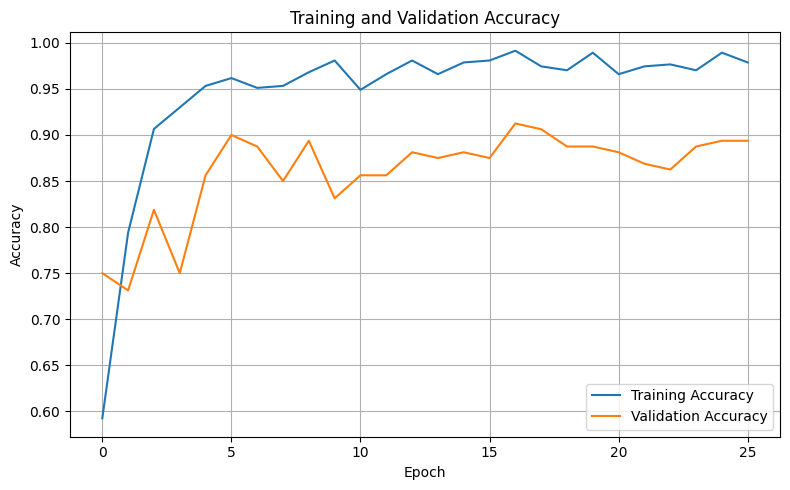

In [103]:
# ============================================================
# 32. ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(history["train_accuracy"], label="Training Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

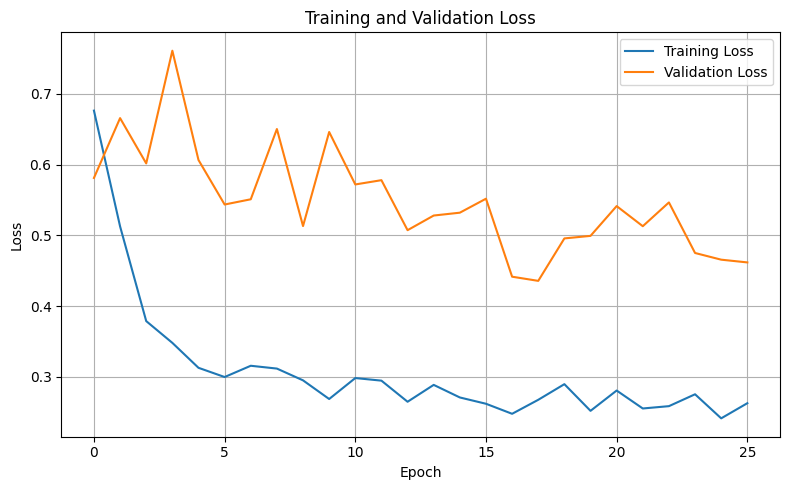

In [104]:
# ============================================================
# 33. LOSS GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(history["train_loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [105]:
# ============================================================
# 29. FINAL TEST
# ============================================================

model.eval()

test_predictions = []
test_labels = []
test_probabilities = []

with torch.no_grad():

    for batch in test_loader:

        mel = batch["mel"].to(device, non_blocking=True)
        cqt = batch["cqt"].to(device, non_blocking=True)
        gammatone = batch["gammatone"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        with torch.amp.autocast(
            device_type="cuda", enabled=torch.cuda.is_available()
        ):
            logits = model(mel, cqt, gammatone)

        probabilities = torch.softmax(logits, dim=1)
        predictions = torch.argmax(probabilities, dim=1)

        test_predictions.extend(predictions.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())
        test_probabilities.extend(probabilities[:, 1].cpu().numpy())

test_results = {
    "labels": test_labels,
    "predictions": test_predictions,
    "probabilities": test_probabilities
}

test_accuracy = accuracy_score(test_labels, test_predictions)
test_precision = precision_score(test_labels, test_predictions, zero_division=0)
test_recall = recall_score(test_labels, test_predictions, zero_division=0)
test_f1 = f1_score(test_labels, test_predictions, zero_division=0)
test_auc = roc_auc_score(test_labels, test_probabilities)

tn, fp, fn, tp = confusion_matrix(test_labels, test_predictions, labels=[0, 1]).ravel()
test_specificity = tn / (tn + fp)

print("=" * 70)
print("FINAL UNSEEN TEST RESULTS")
print("=" * 70)
print(f"Accuracy    : {test_accuracy:.4f}")
print(f"Precision   : {test_precision:.4f}")
print(f"Recall      : {test_recall:.4f}")
print(f"F1-Score    : {test_f1:.4f}")
print(f"Specificity : {test_specificity:.4f}")
print(f"AUC         : {test_auc:.4f}")
print(f"\nConfusion matrix values:")
print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")

FINAL UNSEEN TEST RESULTS
Accuracy    : 0.9935
Precision   : 1.0000
Recall      : 0.9889
F1-Score    : 0.9944
Specificity : 1.0000
AUC         : 0.9998

Confusion matrix values:
TN = 64
FP = 0
FN = 1
TP = 89


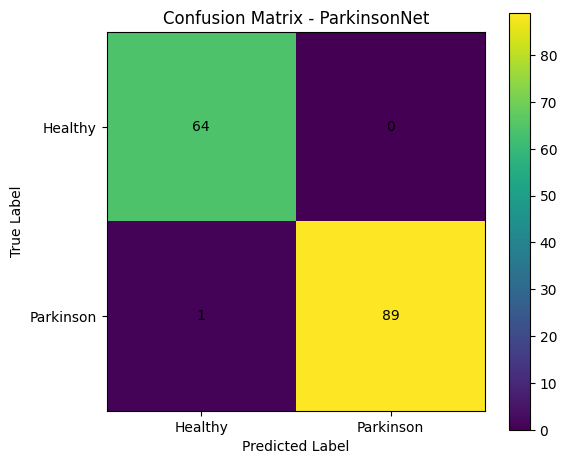

In [106]:
# ============================================================
# 30. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    test_results["labels"],
    test_results["predictions"],
    labels=[0, 1]
)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix - ParkinsonNet")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Healthy", "Parkinson"])
plt.yticks([0, 1], ["Healthy", "Parkinson"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()

plt.tight_layout()
plt.show()

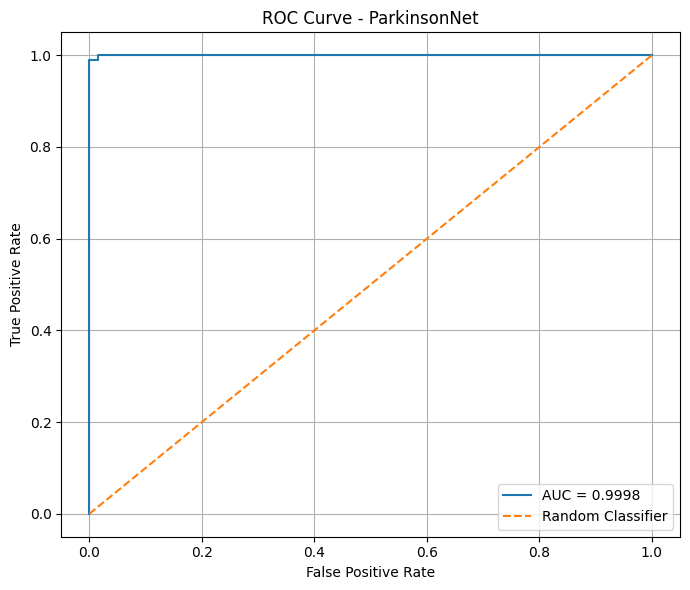

In [107]:
# ============================================================
# 31. ROC CURVE
# ============================================================

fpr, tpr, _ = roc_curve(test_results["labels"], test_results["probabilities"])
roc_auc_value = roc_auc_score(test_results["labels"], test_results["probabilities"])

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_value:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curve - ParkinsonNet")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [108]:
from sklearn.model_selection import StratifiedGroupKFold, train_test_split as tts

def evaluate_full(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    all_predictions = []
    all_labels = []
    all_probabilities = []

    with torch.no_grad():

        for batch in loader:

            mel = batch["mel"].to(device, non_blocking=True)
            cqt = batch["cqt"].to(device, non_blocking=True)
            gammatone = batch["gammatone"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)

            with torch.amp.autocast(
                device_type="cuda", enabled=torch.cuda.is_available()
            ):
                logits = model(mel, cqt, gammatone)
                loss = criterion(logits, labels)

            running_loss += loss.item() * labels.size(0)

            probabilities = torch.softmax(logits, dim=1)
            predictions = torch.argmax(probabilities, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities[:, 1].cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_accuracy = accuracy_score(all_labels, all_predictions)
    epoch_precision = precision_score(all_labels, all_predictions, zero_division=0)
    epoch_recall = recall_score(all_labels, all_predictions, zero_division=0)
    epoch_f1 = f1_score(all_labels, all_predictions, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(all_labels, all_predictions, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")

    try:
        epoch_auc = roc_auc_score(all_labels, all_probabilities)
    except ValueError:
        epoch_auc = float("nan")

    return {
        "loss": epoch_loss, "accuracy": epoch_accuracy, "precision": epoch_precision,
        "recall": epoch_recall, "specificity": specificity, "f1": epoch_f1,
        "auc": epoch_auc, "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)
    }

In [109]:
def plot_fold_curves(fold_idx, fold_history):

    epochs_range = range(1, len(fold_history["train_acc"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, fold_history["train_acc"], label="Training Accuracy")
    plt.plot(epochs_range, fold_history["val_acc"], label="Validation Accuracy")
    plt.title(f"Fold {fold_idx} - Training and Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, fold_history["train_loss"], label="Training Loss")
    plt.plot(epochs_range, fold_history["val_loss"], label="Validation Loss")
    plt.title(f"Fold {fold_idx} - Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_confusion(cm, title):

    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks([0, 1], ["Healthy", "Parkinson"])
    plt.yticks([0, 1], ["Healthy", "Parkinson"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()
    plt.show()


FOLD 1/5
Train: 32 subj / 505 rec
Val:   8 subj / 123 rec
Test:  10 subj / 157 rec
Dataset initialized with 505 samples.
Dataset initialized with 123 samples.
Dataset initialized with 157 samples.
  Epoch 01 | Train Acc 0.644 | Val Acc 0.919 | Train Loss 0.656 | Val Loss 0.513 | Val AUC 0.966
  Epoch 02 | Train Acc 0.850 | Val Acc 0.894 | Train Loss 0.487 | Val Loss 0.365 | Val AUC 0.979
  Epoch 03 | Train Acc 0.919 | Val Acc 0.935 | Train Loss 0.372 | Val Loss 0.313 | Val AUC 0.992
  Epoch 04 | Train Acc 0.901 | Val Acc 0.927 | Train Loss 0.392 | Val Loss 0.340 | Val AUC 0.984
  Epoch 05 | Train Acc 0.929 | Val Acc 0.911 | Train Loss 0.348 | Val Loss 0.315 | Val AUC 0.988
  Epoch 06 | Train Acc 0.911 | Val Acc 0.943 | Train Loss 0.348 | Val Loss 0.283 | Val AUC 0.994
  Epoch 07 | Train Acc 0.941 | Val Acc 0.902 | Train Loss 0.316 | Val Loss 0.345 | Val AUC 0.997
  Epoch 08 | Train Acc 0.950 | Val Acc 0.927 | Train Loss 0.309 | Val Loss 0.301 | Val AUC 0.999
  Epoch 09 | Train Acc 0.9

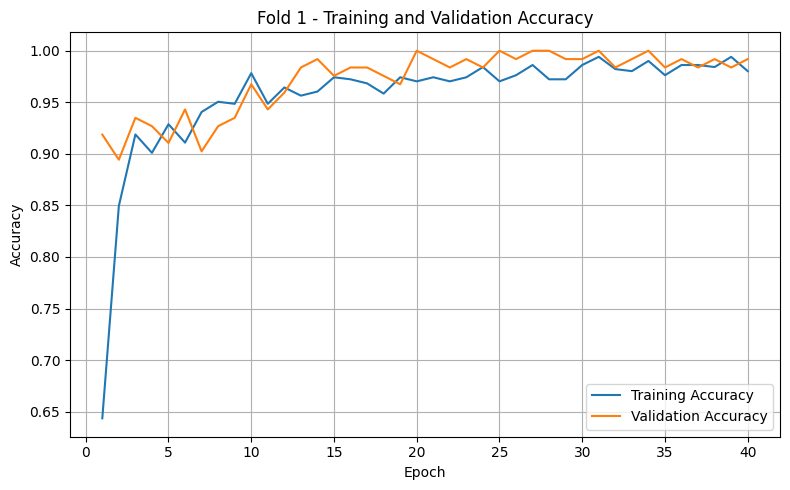

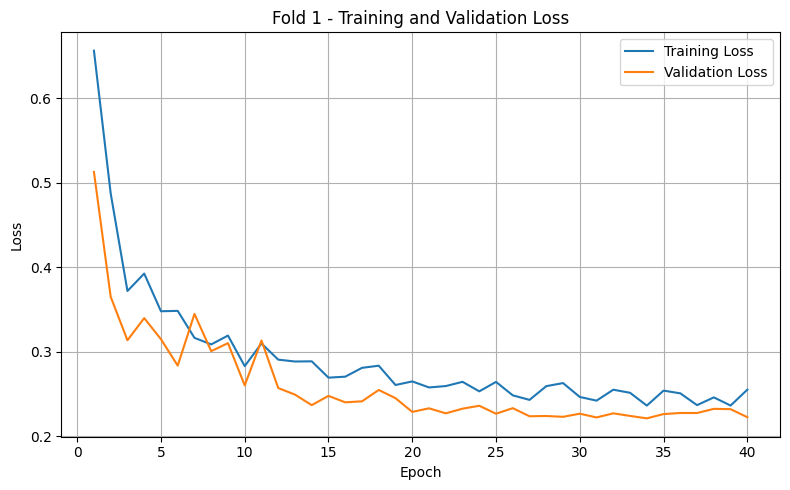


FOLD 1 TEST RESULT (full metrics):
  Accuracy:    1.0000
  Precision:   1.0000
  Recall:      1.0000
  Specificity: 1.0000
  F1:          1.0000
  AUC:         1.0000


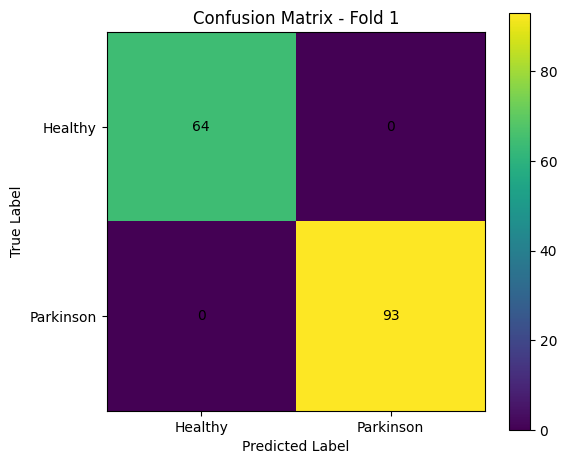


FOLD 2/5
Train: 32 subj / 502 rec
Val:   8 subj / 127 rec
Test:  10 subj / 156 rec
Dataset initialized with 502 samples.
Dataset initialized with 127 samples.
Dataset initialized with 156 samples.
  Epoch 01 | Train Acc 0.645 | Val Acc 0.787 | Train Loss 0.629 | Val Loss 0.529 | Val AUC 0.917
  Epoch 02 | Train Acc 0.835 | Val Acc 0.882 | Train Loss 0.482 | Val Loss 0.368 | Val AUC 0.990
  Epoch 03 | Train Acc 0.898 | Val Acc 0.874 | Train Loss 0.378 | Val Loss 0.370 | Val AUC 0.998
  Epoch 04 | Train Acc 0.918 | Val Acc 0.953 | Train Loss 0.356 | Val Loss 0.298 | Val AUC 1.000
  Epoch 05 | Train Acc 0.924 | Val Acc 0.984 | Train Loss 0.340 | Val Loss 0.265 | Val AUC 1.000
  Epoch 06 | Train Acc 0.938 | Val Acc 0.984 | Train Loss 0.338 | Val Loss 0.244 | Val AUC 1.000
  Epoch 07 | Train Acc 0.934 | Val Acc 0.976 | Train Loss 0.331 | Val Loss 0.271 | Val AUC 1.000
  Epoch 08 | Train Acc 0.966 | Val Acc 0.953 | Train Loss 0.282 | Val Loss 0.260 | Val AUC 1.000
  Epoch 09 | Train Acc 0.9

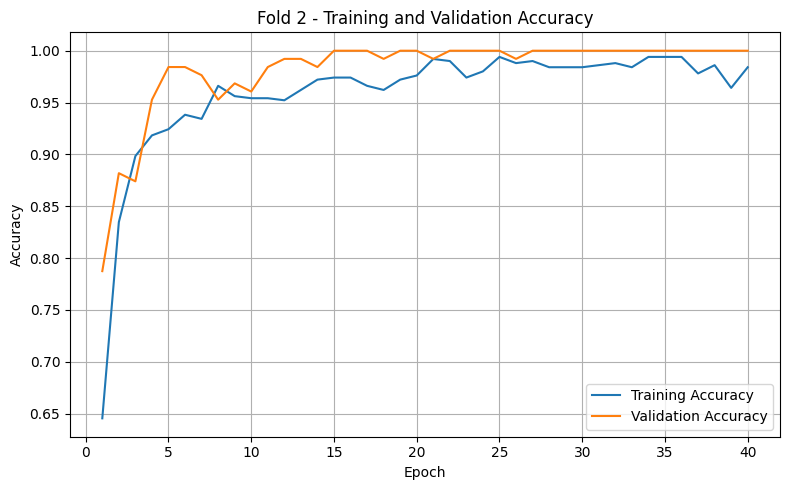

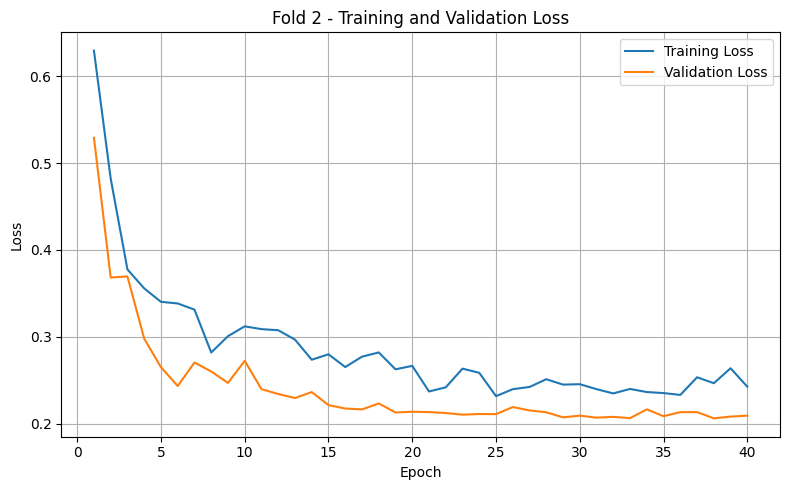


FOLD 2 TEST RESULT (full metrics):
  Accuracy:    0.9167
  Precision:   1.0000
  Recall:      0.8632
  Specificity: 1.0000
  F1:          0.9266
  AUC:         0.9184


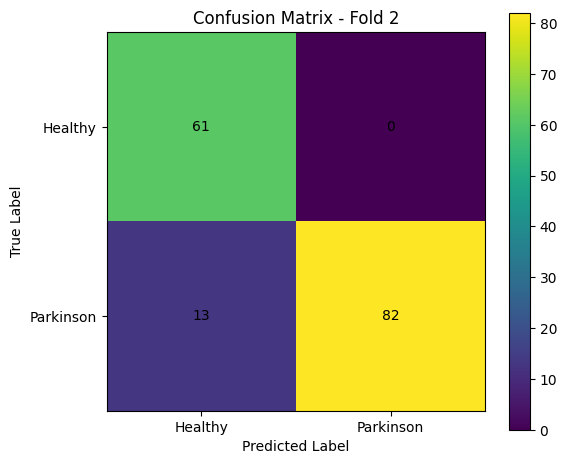


FOLD 3/5
Train: 32 subj / 506 rec
Val:   8 subj / 125 rec
Test:  10 subj / 154 rec
Dataset initialized with 506 samples.
Dataset initialized with 125 samples.
Dataset initialized with 154 samples.
  Epoch 01 | Train Acc 0.623 | Val Acc 0.768 | Train Loss 0.658 | Val Loss 0.574 | Val AUC 0.877
  Epoch 02 | Train Acc 0.820 | Val Acc 0.840 | Train Loss 0.514 | Val Loss 0.434 | Val AUC 0.933
  Epoch 03 | Train Acc 0.895 | Val Acc 0.864 | Train Loss 0.402 | Val Loss 0.444 | Val AUC 0.936
  Epoch 04 | Train Acc 0.923 | Val Acc 0.856 | Train Loss 0.374 | Val Loss 0.459 | Val AUC 0.960
  Epoch 05 | Train Acc 0.903 | Val Acc 0.880 | Train Loss 0.386 | Val Loss 0.399 | Val AUC 0.972
  Epoch 06 | Train Acc 0.933 | Val Acc 0.872 | Train Loss 0.349 | Val Loss 0.473 | Val AUC 0.958
  Epoch 07 | Train Acc 0.955 | Val Acc 0.912 | Train Loss 0.321 | Val Loss 0.377 | Val AUC 0.981
  Epoch 08 | Train Acc 0.949 | Val Acc 0.896 | Train Loss 0.323 | Val Loss 0.447 | Val AUC 0.985
  Epoch 09 | Train Acc 0.9

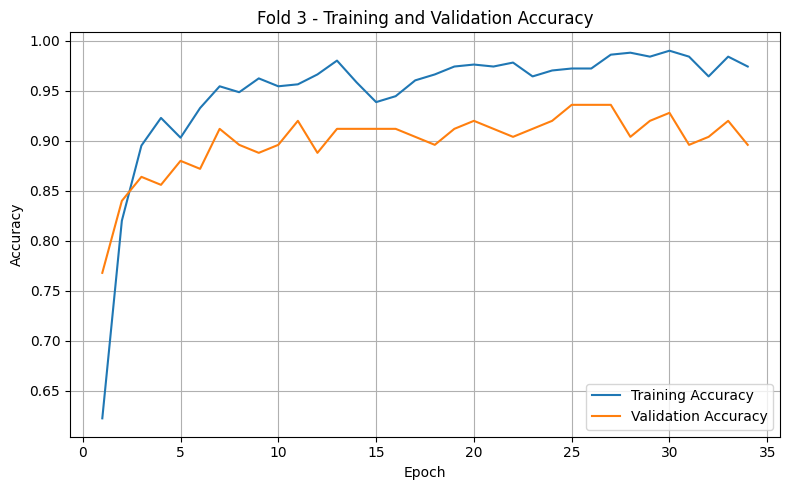

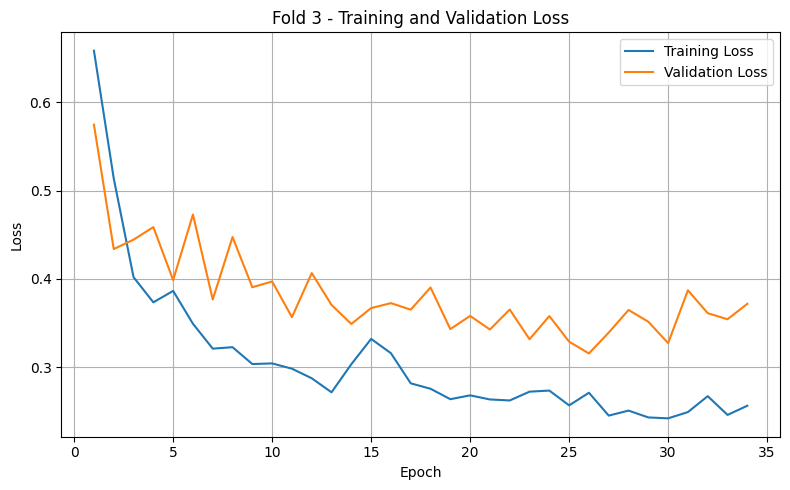


FOLD 3 TEST RESULT (full metrics):
  Accuracy:    1.0000
  Precision:   1.0000
  Recall:      1.0000
  Specificity: 1.0000
  F1:          1.0000
  AUC:         1.0000


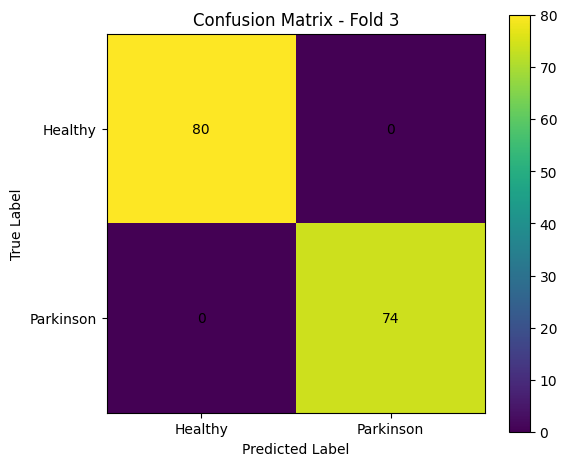


FOLD 4/5
Train: 32 subj / 499 rec
Val:   8 subj / 126 rec
Test:  10 subj / 160 rec
Dataset initialized with 499 samples.
Dataset initialized with 126 samples.
Dataset initialized with 160 samples.
  Epoch 01 | Train Acc 0.689 | Val Acc 0.937 | Train Loss 0.629 | Val Loss 0.457 | Val AUC 0.979
  Epoch 02 | Train Acc 0.870 | Val Acc 0.960 | Train Loss 0.459 | Val Loss 0.294 | Val AUC 0.998
  Epoch 03 | Train Acc 0.884 | Val Acc 0.960 | Train Loss 0.405 | Val Loss 0.272 | Val AUC 0.999
  Epoch 04 | Train Acc 0.932 | Val Acc 1.000 | Train Loss 0.366 | Val Loss 0.239 | Val AUC 1.000
  Epoch 05 | Train Acc 0.936 | Val Acc 0.992 | Train Loss 0.334 | Val Loss 0.240 | Val AUC 1.000
  Epoch 06 | Train Acc 0.934 | Val Acc 0.944 | Train Loss 0.347 | Val Loss 0.277 | Val AUC 1.000
  Epoch 07 | Train Acc 0.938 | Val Acc 0.984 | Train Loss 0.338 | Val Loss 0.243 | Val AUC 1.000
  Epoch 08 | Train Acc 0.962 | Val Acc 0.984 | Train Loss 0.302 | Val Loss 0.244 | Val AUC 1.000
  Epoch 09 | Train Acc 0.9

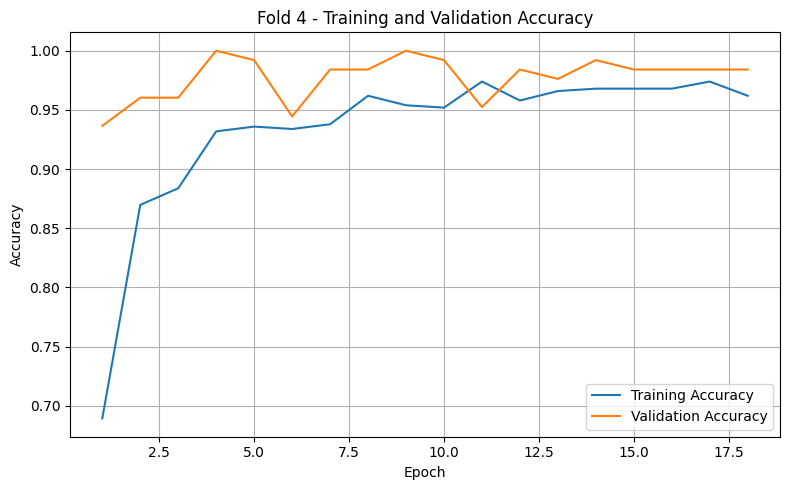

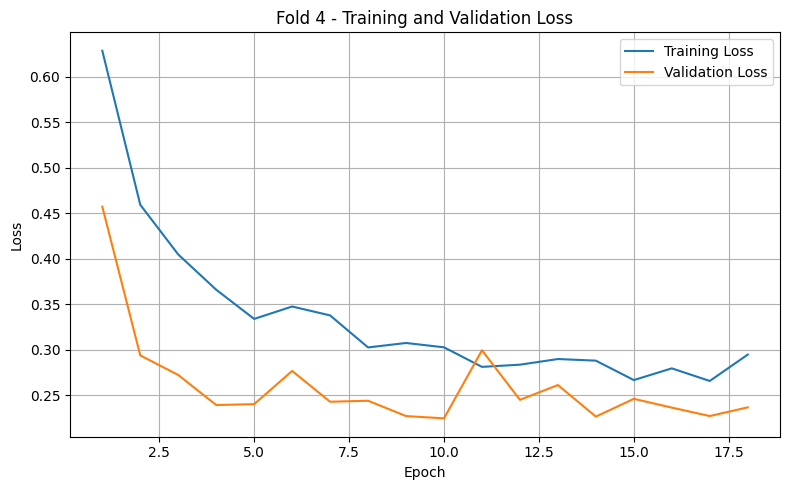


FOLD 4 TEST RESULT (full metrics):
  Accuracy:    0.9938
  Precision:   1.0000
  Recall:      0.9896
  Specificity: 1.0000
  F1:          0.9948
  AUC:         0.9990


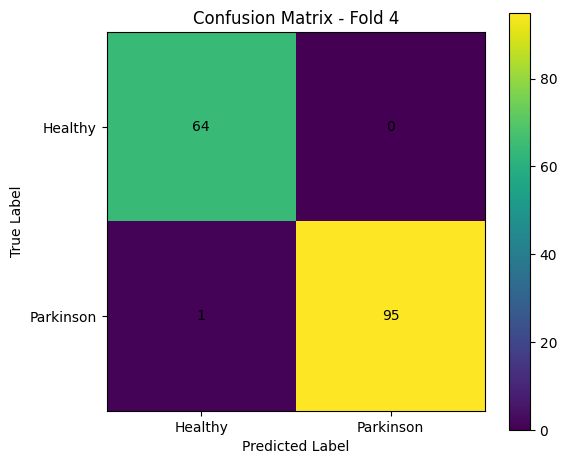


FOLD 5/5
Train: 32 subj / 499 rec
Val:   8 subj / 128 rec
Test:  10 subj / 158 rec
Dataset initialized with 499 samples.
Dataset initialized with 128 samples.
Dataset initialized with 158 samples.
  Epoch 01 | Train Acc 0.611 | Val Acc 0.930 | Train Loss 0.639 | Val Loss 0.450 | Val AUC 0.999
  Epoch 02 | Train Acc 0.808 | Val Acc 1.000 | Train Loss 0.489 | Val Loss 0.269 | Val AUC 1.000
  Epoch 03 | Train Acc 0.906 | Val Acc 1.000 | Train Loss 0.394 | Val Loss 0.261 | Val AUC 1.000
  Epoch 04 | Train Acc 0.916 | Val Acc 0.977 | Train Loss 0.366 | Val Loss 0.277 | Val AUC 1.000
  Epoch 05 | Train Acc 0.942 | Val Acc 0.977 | Train Loss 0.317 | Val Loss 0.277 | Val AUC 1.000
  Epoch 06 | Train Acc 0.964 | Val Acc 1.000 | Train Loss 0.299 | Val Loss 0.237 | Val AUC 1.000
  Epoch 07 | Train Acc 0.940 | Val Acc 1.000 | Train Loss 0.330 | Val Loss 0.230 | Val AUC 1.000
  Epoch 08 | Train Acc 0.946 | Val Acc 0.984 | Train Loss 0.344 | Val Loss 0.249 | Val AUC 1.000
  Epoch 09 | Train Acc 0.9

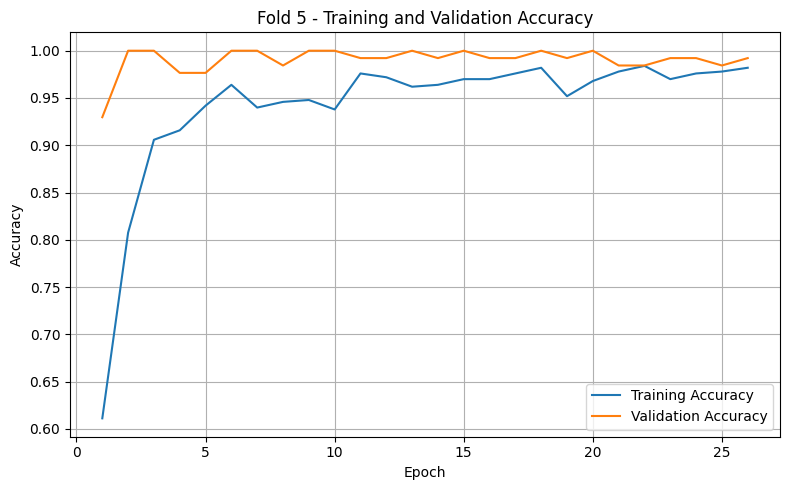

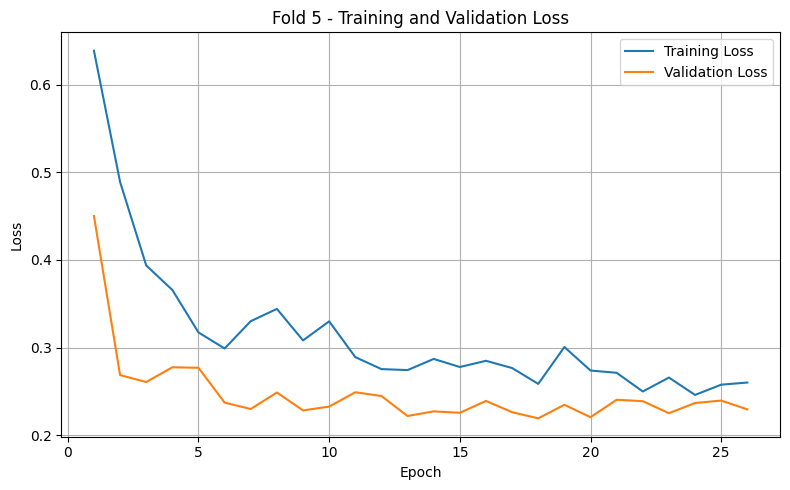


FOLD 5 TEST RESULT (full metrics):
  Accuracy:    0.8797
  Precision:   0.8041
  Recall:      1.0000
  Specificity: 0.7625
  F1:          0.8914
  AUC:         0.9733


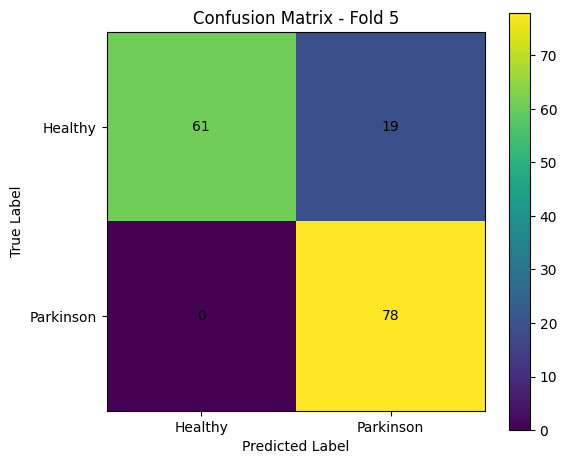

In [110]:
N_FOLDS = 5

all_subjects = subject_df["subject_id"].values
all_labels_arr = subject_df["label"].values

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=CFG.RANDOM_STATE)

fold_results = []
aggregate_cm = np.zeros((2, 2), dtype=int)

for fold_idx, (train_val_idx, fold_test_idx) in enumerate(
    sgkf.split(all_subjects, all_labels_arr, groups=all_subjects), start=1
):

    print("\n" + "=" * 70)
    print(f"FOLD {fold_idx}/{N_FOLDS}")
    print("=" * 70)

    fold_test_subjects = set(all_subjects[fold_test_idx])
    fold_dev_subjects_arr = all_subjects[train_val_idx]
    fold_dev_labels_arr = all_labels_arr[train_val_idx]

    fold_train_subj, fold_val_subj = tts(
        fold_dev_subjects_arr, test_size=0.2,
        random_state=CFG.RANDOM_STATE, stratify=fold_dev_labels_arr
    )
    fold_train_subjects = set(fold_train_subj)
    fold_val_subjects = set(fold_val_subj)

    assert not (fold_train_subjects & fold_val_subjects)
    assert not (fold_train_subjects & fold_test_subjects)
    assert not (fold_val_subjects & fold_test_subjects)

    fold_train_df = feature_metadata[feature_metadata["subject_id"].isin(fold_train_subjects)].reset_index(drop=True)
    fold_val_df = feature_metadata[feature_metadata["subject_id"].isin(fold_val_subjects)].reset_index(drop=True)
    fold_test_df = feature_metadata[feature_metadata["subject_id"].isin(fold_test_subjects)].reset_index(drop=True)

    print(f"Train: {len(fold_train_subjects)} subj / {len(fold_train_df)} rec")
    print(f"Val:   {len(fold_val_subjects)} subj / {len(fold_val_df)} rec")
    print(f"Test:  {len(fold_test_subjects)} subj / {len(fold_test_df)} rec")

    fold_train_loader = DataLoader(
        ParkinsonFeatureDataset(fold_train_df, training=True),
        batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True
    )
    fold_val_loader = DataLoader(
        ParkinsonFeatureDataset(fold_val_df, training=False),
        batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
    )
    fold_test_loader = DataLoader(
        ParkinsonFeatureDataset(fold_test_df, training=False),
        batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
    )

    fold_model = ParkinsonNet(num_classes=CFG.NUM_CLASSES).to(device)
    set_backbone_mode(fold_model, trainable=False)

    fold_class_counts = fold_train_df["label"].value_counts().sort_index()
    fold_class_weights = torch.tensor(
        len(fold_train_df) / (CFG.NUM_CLASSES * fold_class_counts.values),
        dtype=torch.float32, device=device
    )
    fold_criterion = nn.CrossEntropyLoss(weight=fold_class_weights, label_smoothing=CFG.LABEL_SMOOTHING)

    fold_backbone_params = list(fold_model.backbone.parameters())
    fold_new_params = [p for n, p in fold_model.named_parameters() if not n.startswith("backbone.")]
    fold_optimizer = torch.optim.AdamW(
        [
            {"params": fold_new_params, "lr": CFG.LEARNING_RATE},
            {"params": fold_backbone_params, "lr": CFG.BACKBONE_LR}
        ],
        weight_decay=CFG.WEIGHT_DECAY
    )

    fold_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        fold_optimizer, T_max=CFG.EPOCHS, eta_min=1e-7
    )

    fold_scaler = torch.amp.GradScaler(enabled=torch.cuda.is_available())
    fold_early_stopping = EarlyStopping()

    fold_best_val_loss = float("inf")
    fold_best_state = None
    fold_backbone_frozen = True

    fold_history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}

    for epoch in range(1, CFG.EPOCHS + 1):

        if epoch == CFG.UNFREEZE_EPOCH:
            set_backbone_mode(fold_model, trainable=True)
            fold_backbone_frozen = False

        train_metrics = train_one_epoch(
            model=fold_model, loader=fold_train_loader, criterion=fold_criterion,
            optimizer=fold_optimizer, scaler=fold_scaler, device=device,
            backbone_frozen=fold_backbone_frozen
        )

        val_metrics = validate(
            model=fold_model, loader=fold_val_loader, criterion=fold_criterion, device=device
        )

        fold_scheduler.step()

        fold_history["train_acc"].append(train_metrics["accuracy"])
        fold_history["val_acc"].append(val_metrics["accuracy"])
        fold_history["train_loss"].append(train_metrics["loss"])
        fold_history["val_loss"].append(val_metrics["loss"])

        print(
            f"  Epoch {epoch:02d} | Train Acc {train_metrics['accuracy']:.3f} | "
            f"Val Acc {val_metrics['accuracy']:.3f} | "
            f"Train Loss {train_metrics['loss']:.3f} | Val Loss {val_metrics['loss']:.3f} | "
            f"Val AUC {val_metrics['auc']:.3f}"
        )

        if val_metrics["loss"] < fold_best_val_loss:
            fold_best_val_loss = val_metrics["loss"]
            fold_best_state = {k: v.cpu().clone() for k, v in fold_model.state_dict().items()}

        fold_early_stopping.step(val_metrics["loss"], epoch)
        if fold_early_stopping.should_stop:
            print(f"  Early stopping at epoch {epoch}")
            break

    plot_fold_curves(fold_idx, fold_history)

    fold_model.load_state_dict(fold_best_state)

    fold_test_metrics = evaluate_full(
        model=fold_model, loader=fold_test_loader, criterion=fold_criterion, device=device
    )

    print(f"\nFOLD {fold_idx} TEST RESULT (full metrics):")
    print(f"  Accuracy:    {fold_test_metrics['accuracy']:.4f}")
    print(f"  Precision:   {fold_test_metrics['precision']:.4f}")
    print(f"  Recall:      {fold_test_metrics['recall']:.4f}")
    print(f"  Specificity: {fold_test_metrics['specificity']:.4f}")
    print(f"  F1:          {fold_test_metrics['f1']:.4f}")
    print(f"  AUC:         {fold_test_metrics['auc']:.4f}")

    fold_cm = np.array([
        [fold_test_metrics["tn"], fold_test_metrics["fp"]],
        [fold_test_metrics["fn"], fold_test_metrics["tp"]]
    ])
    aggregate_cm += fold_cm

    plot_confusion(fold_cm, f"Confusion Matrix - Fold {fold_idx}")

    fold_results.append({
        "fold": fold_idx,
        "n_test_subjects": len(fold_test_subjects),
        "test_accuracy": fold_test_metrics["accuracy"],
        "test_precision": fold_test_metrics["precision"],
        "test_recall": fold_test_metrics["recall"],
        "test_specificity": fold_test_metrics["specificity"],
        "test_f1": fold_test_metrics["f1"],
        "test_auc": fold_test_metrics["auc"],
    })

    del fold_model
    torch.cuda.empty_cache()


K-FOLD SUMMARY (FULL METRICS)
 fold  n_test_subjects  test_accuracy  test_precision  test_recall  test_specificity  test_f1  test_auc
    1               10       1.000000        1.000000     1.000000            1.0000 1.000000  1.000000
    2               10       0.916667        1.000000     0.863158            1.0000 0.926554  0.918378
    3               10       1.000000        1.000000     1.000000            1.0000 1.000000  1.000000
    4               10       0.993750        1.000000     0.989583            1.0000 0.994764  0.999023
    5               10       0.879747        0.804124     1.000000            0.7625 0.891429  0.973317

Mean test_accuracy: 0.9580 +/- 0.0562
Mean test_precision: 0.9608 +/- 0.0876
Mean test_recall: 0.9705 +/- 0.0602
Mean test_specificity: 0.9525 +/- 0.1062
Mean test_f1: 0.9625 +/- 0.0505
Mean test_auc: 0.9781 +/- 0.0353

Aggregate confusion matrix (summed across all folds):
[[330  19]
 [ 14 422]]


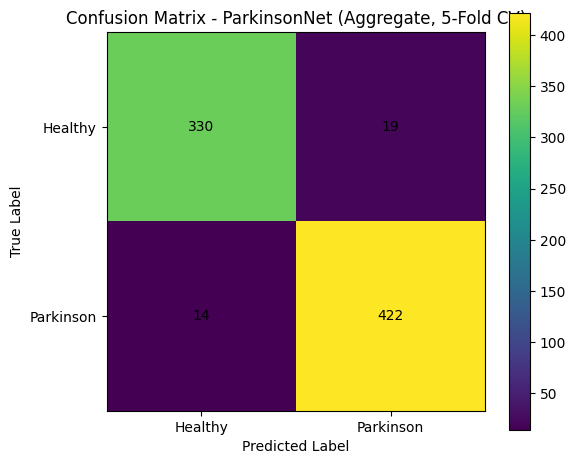

In [111]:
print("\n" + "=" * 70)
print("K-FOLD SUMMARY (FULL METRICS)")
print("=" * 70)

results_df = pd.DataFrame(fold_results)
print(results_df.to_string(index=False))
print()

for metric in ["test_accuracy", "test_precision", "test_recall", "test_specificity", "test_f1", "test_auc"]:
    print(f"Mean {metric}: {results_df[metric].mean():.4f} +/- {results_df[metric].std():.4f}")

print("\nAggregate confusion matrix (summed across all folds):")
print(aggregate_cm)

plot_confusion(aggregate_cm, "Confusion Matrix - ParkinsonNet (Aggregate, 5-Fold CV)")

In [112]:
all_fold_histories = []

In [113]:
all_fold_histories.append(fold_history)

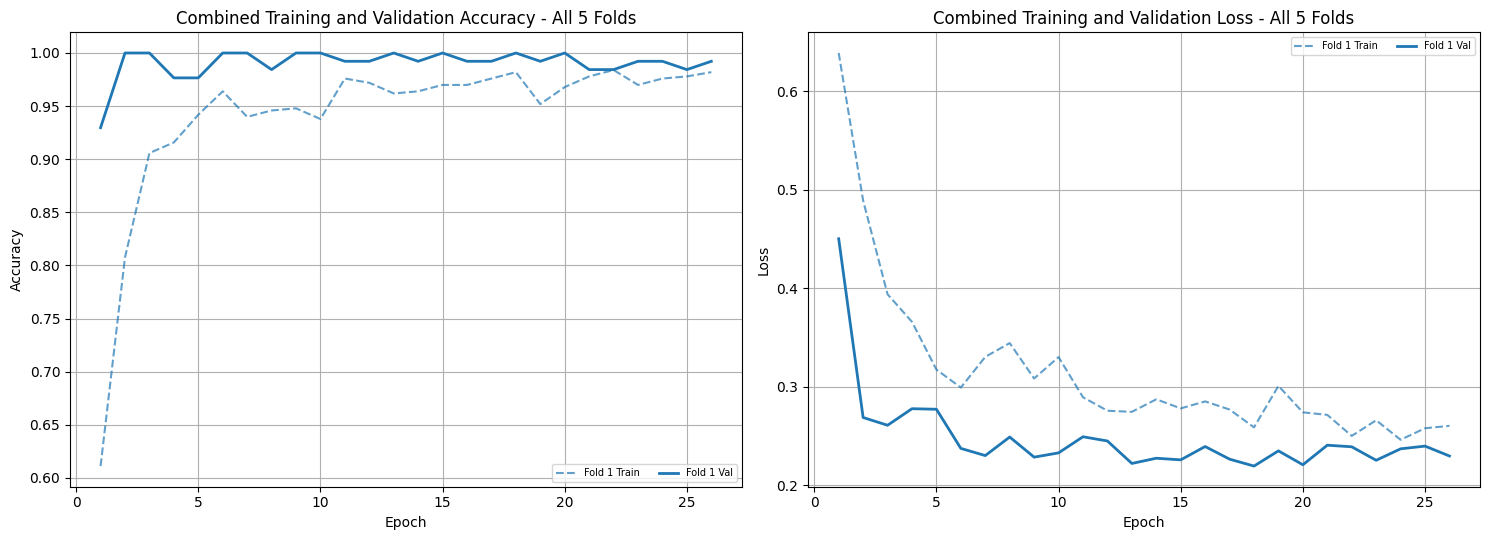

In [114]:
colors = {1: "tab:blue", 2: "tab:orange", 3: "tab:green", 4: "tab:red", 5: "tab:purple"}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for fold_idx, fold_history in enumerate(all_fold_histories, start=1):
    epochs_range = range(1, len(fold_history["train_acc"]) + 1)
    axes[0].plot(epochs_range, fold_history["train_acc"], linestyle="--",
                 color=colors[fold_idx], alpha=0.7, label=f"Fold {fold_idx} Train")
    axes[0].plot(epochs_range, fold_history["val_acc"], linestyle="-",
                 color=colors[fold_idx], linewidth=2, label=f"Fold {fold_idx} Val")

axes[0].set_title("Combined Training and Validation Accuracy - All 5 Folds")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend(fontsize=7, ncol=2, loc="lower right")
axes[0].grid(True)

for fold_idx, fold_history in enumerate(all_fold_histories, start=1):
    epochs_range = range(1, len(fold_history["train_loss"]) + 1)
    axes[1].plot(epochs_range, fold_history["train_loss"], linestyle="--",
                 color=colors[fold_idx], alpha=0.7, label=f"Fold {fold_idx} Train")
    axes[1].plot(epochs_range, fold_history["val_loss"], linestyle="-",
                 color=colors[fold_idx], linewidth=2, label=f"Fold {fold_idx} Val")

axes[1].set_title("Combined Training and Validation Loss - All 5 Folds")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend(fontsize=7, ncol=2, loc="upper right")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Ablation study 

In [129]:
# ============================================================
# ABLATION STUDY - SETUP
# ============================================================

N_FOLDS = 5

IMAGENET_MEAN = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32
).view(1, 3, 1, 1)

IMAGENET_STD = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32
).view(1, 3, 1, 1)

print("Ablation study setup ready.")
print("Number of folds:", N_FOLDS)
print("ImageNet normalization: ENABLED")

Ablation study setup ready.
Number of folds: 5
ImageNet normalization: ENABLED


In [130]:
# ============================================================
# COMMON ABLATION BACKBONE
# ============================================================

class AblationBackbone(nn.Module):

    def __init__(self):

        super().__init__()

        # ----------------------------------------------------
        # Input projections
        # ----------------------------------------------------

        self.mel_projection = InputProjection()

        self.cqt_projection = InputProjection()

        self.gammatone_projection = InputProjection()

        # ----------------------------------------------------
        # ImageNet normalization
        # ----------------------------------------------------

        self.register_buffer(
            "imagenet_mean",
            IMAGENET_MEAN.clone()
        )

        self.register_buffer(
            "imagenet_std",
            IMAGENET_STD.clone()
        )

        # ----------------------------------------------------
        # Pretrained MobileNetV3-Small
        # ----------------------------------------------------

        weights = MobileNet_V3_Small_Weights.DEFAULT

        backbone = mobilenet_v3_small(
            weights=weights
        )

        self.backbone = backbone.features

        self.feature_dim = 576

    # ========================================================
    # NORMALIZATION
    # ========================================================

    def _normalize(self, x):

        return (
            x - self.imagenet_mean
        ) / self.imagenet_std

    # ========================================================
    # PROCESS ONE BRANCH
    # ========================================================

    def process_mel(self, x):

        x = self.mel_projection(x)

        x = self._normalize(x)

        x = self.backbone(x)

        return x

    def process_cqt(self, x):

        x = self.cqt_projection(x)

        x = self._normalize(x)

        x = self.backbone(x)

        return x

    def process_gammatone(self, x):

        x = self.gammatone_projection(x)

        x = self._normalize(x)

        x = self.backbone(x)

        return x

In [131]:
# ============================================================
# ABLATION 1
# BASELINE
#
# CSRLM = OFF
# FIEM  = OFF
# ASFM  = OFF
# FFRM  = OFF
#
# ImageNet normalization = ON
# ============================================================

class Ablation1_Baseline(AblationBackbone):

    def __init__(
        self,
        num_classes=CFG.NUM_CLASSES
    ):

        super().__init__()

        # ----------------------------------------------------
        # Simple fusion
        # 576 + 576 + 576 = 1728
        # ----------------------------------------------------

        self.simple_fusion = nn.Sequential(

            nn.Conv2d(
                self.feature_dim * 3,
                CFG.FUSION_DIM,
                kernel_size=1,
                stride=1,
                padding=0,
                bias=False
            ),

            nn.BatchNorm2d(
                CFG.FUSION_DIM
            ),

            nn.GELU(),

            nn.Dropout2d(
                CFG.DROPOUT_FUSION
            )
        )

        # ----------------------------------------------------
        # Classification head
        # ----------------------------------------------------

        self.classifier = ClassificationHead(
            in_channels=CFG.FUSION_DIM,
            num_classes=num_classes,
            dropout=CFG.DROPOUT_CLASSIFIER
        )

    # ========================================================
    # FORWARD
    # ========================================================

    def forward(
        self,
        mel,
        cqt,
        gammatone
    ):

        mel = self.process_mel(mel)

        cqt = self.process_cqt(cqt)

        gammatone = self.process_gammatone(
            gammatone
        )

        # ----------------------------------------------------
        # Concatenate
        # ----------------------------------------------------

        combined = torch.cat(
            [
                mel,
                cqt,
                gammatone
            ],
            dim=1
        )

        # ----------------------------------------------------
        # Simple fusion
        # ----------------------------------------------------

        fused = self.simple_fusion(
            combined
        )

        # ----------------------------------------------------
        # Classifier
        # ----------------------------------------------------

        logits = self.classifier(
            fused
        )

        return logits

In [132]:
# ============================================================
# TEST ABLATION 1
# ============================================================

test_model = Ablation1_Baseline(
    num_classes=CFG.NUM_CLASSES
).to(device)

dummy_mel = torch.randn(
    2, 1, 224, 224,
    device=device
)

dummy_cqt = torch.randn(
    2, 1, 224, 224,
    device=device
)

dummy_gammatone = torch.randn(
    2, 1, 224, 224,
    device=device
)

with torch.no_grad():

    output = test_model(
        dummy_mel,
        dummy_cqt,
        dummy_gammatone
    )

print("Output shape:", output.shape)

del test_model

torch.cuda.empty_cache()

Output shape: torch.Size([2, 2])


In [133]:
# ============================================================
# ABLATION 2
# BASELINE + CSRLM
#
# CSRLM = ON
# FIEM  = OFF
# ASFM  = OFF
# FFRM  = OFF
#
# ImageNet normalization = ON
# ============================================================

class Ablation2_CSRLM(AblationBackbone):

    def __init__(
        self,
        num_classes=CFG.NUM_CLASSES
    ):

        super().__init__()

        # ----------------------------------------------------
        # CSRLM
        # ----------------------------------------------------

        self.csrLM_mel = CSRLM(
            channels=self.feature_dim,
            dropout=CFG.DROPOUT_ATTENTION
        )

        self.csrLM_cqt = CSRLM(
            channels=self.feature_dim,
            dropout=CFG.DROPOUT_ATTENTION
        )

        self.csrLM_gammatone = CSRLM(
            channels=self.feature_dim,
            dropout=CFG.DROPOUT_ATTENTION
        )

        # ----------------------------------------------------
        # Simple fusion
        # ----------------------------------------------------

        self.simple_fusion = nn.Sequential(

            nn.Conv2d(
                self.feature_dim * 3,
                CFG.FUSION_DIM,
                kernel_size=1,
                stride=1,
                padding=0,
                bias=False
            ),

            nn.BatchNorm2d(
                CFG.FUSION_DIM
            ),

            nn.GELU(),

            nn.Dropout2d(
                CFG.DROPOUT_FUSION
            )
        )

        # ----------------------------------------------------
        # Classifier
        # ----------------------------------------------------

        self.classifier = ClassificationHead(
            in_channels=CFG.FUSION_DIM,
            num_classes=num_classes,
            dropout=CFG.DROPOUT_CLASSIFIER
        )

    # ========================================================
    # FORWARD
    # ========================================================

    def forward(
        self,
        mel,
        cqt,
        gammatone
    ):

        mel = self.process_mel(mel)

        mel = self.csrLM_mel(mel)

        cqt = self.process_cqt(cqt)

        cqt = self.csrLM_cqt(cqt)

        gammatone = self.process_gammatone(
            gammatone
        )

        gammatone = self.csrLM_gammatone(
            gammatone
        )

        combined = torch.cat(
            [
                mel,
                cqt,
                gammatone
            ],
            dim=1
        )

        fused = self.simple_fusion(
            combined
        )

        logits = self.classifier(
            fused
        )

        return logits

In [134]:
# ============================================================
# TEST ABLATION 2
# ============================================================

test_model = Ablation2_CSRLM(
    num_classes=CFG.NUM_CLASSES
).to(device)

with torch.no_grad():

    output = test_model(
        dummy_mel,
        dummy_cqt,
        dummy_gammatone
    )

print("Ablation 2 output shape:", output.shape)

del test_model

torch.cuda.empty_cache()

Ablation 2 output shape: torch.Size([2, 2])


In [135]:
# ============================================================
# ABLATION 3
# BASELINE + CSRLM + FIEM
#
# CSRLM = ON
# FIEM  = ON
# ASFM  = OFF
# FFRM  = OFF
#
# ImageNet normalization = ON
# ============================================================

class Ablation3_CSRLM_FIEM(AblationBackbone):

    def __init__(
        self,
        num_classes=CFG.NUM_CLASSES
    ):

        super().__init__()

        # ----------------------------------------------------
        # CSRLM
        # ----------------------------------------------------

        self.csrLM_mel = CSRLM(
            channels=self.feature_dim,
            dropout=CFG.DROPOUT_ATTENTION
        )

        self.csrLM_cqt = CSRLM(
            channels=self.feature_dim,
            dropout=CFG.DROPOUT_ATTENTION
        )

        self.csrLM_gammatone = CSRLM(
            channels=self.feature_dim,
            dropout=CFG.DROPOUT_ATTENTION
        )

        # ----------------------------------------------------
        # FIEM
        # ----------------------------------------------------

        self.fiem = FIEM(
            in_channels=self.feature_dim,
            fusion_dim=CFG.FUSION_DIM,
            dropout=CFG.DROPOUT_FUSION
        )

        # ----------------------------------------------------
        # Classifier
        # ----------------------------------------------------

        self.classifier = ClassificationHead(
            in_channels=CFG.FUSION_DIM,
            num_classes=num_classes,
            dropout=CFG.DROPOUT_CLASSIFIER
        )

    # ========================================================
    # FORWARD
    # ========================================================

    def forward(
        self,
        mel,
        cqt,
        gammatone
    ):

        mel = self.process_mel(mel)

        mel = self.csrLM_mel(mel)

        cqt = self.process_cqt(cqt)

        cqt = self.csrLM_cqt(cqt)

        gammatone = self.process_gammatone(
            gammatone
        )

        gammatone = self.csrLM_gammatone(
            gammatone
        )

        # FIEM performs concatenation and feature interaction
        fused = self.fiem(
            mel,
            cqt,
            gammatone
        )

        logits = self.classifier(
            fused
        )

        return logits

In [136]:
# ============================================================
# TEST ABLATION 3
# ============================================================

test_model = Ablation3_CSRLM_FIEM(
    num_classes=CFG.NUM_CLASSES
).to(device)

with torch.no_grad():

    output = test_model(
        dummy_mel,
        dummy_cqt,
        dummy_gammatone
    )

print("Ablation 3 output shape:", output.shape)

del test_model

torch.cuda.empty_cache()

Ablation 3 output shape: torch.Size([2, 2])


In [137]:
# ============================================================
# ABLATION 4
# BASELINE + CSRLM + FIEM + ASFM
#
# CSRLM = ON
# FIEM  = ON
# ASFM  = ON
# FFRM  = OFF
#
# ImageNet normalization = ON
# ============================================================

class Ablation4_CSRLM_FIEM_ASFM(AblationBackbone):

    def __init__(
        self,
        num_classes=CFG.NUM_CLASSES
    ):

        super().__init__()

        # ----------------------------------------------------
        # CSRLM
        # ----------------------------------------------------

        self.csrLM_mel = CSRLM(
            channels=self.feature_dim,
            dropout=CFG.DROPOUT_ATTENTION
        )

        self.csrLM_cqt = CSRLM(
            channels=self.feature_dim,
            dropout=CFG.DROPOUT_ATTENTION
        )

        self.csrLM_gammatone = CSRLM(
            channels=self.feature_dim,
            dropout=CFG.DROPOUT_ATTENTION
        )

        # ----------------------------------------------------
        # FIEM
        # ----------------------------------------------------

        self.fiem = FIEM(
            in_channels=self.feature_dim,
            fusion_dim=CFG.FUSION_DIM,
            dropout=CFG.DROPOUT_FUSION
        )

        # ----------------------------------------------------
        # ASFM
        # ----------------------------------------------------

        self.asfm = ASFM(
            channels=CFG.FUSION_DIM,
            dropout=CFG.DROPOUT_FUSION
        )

        # ----------------------------------------------------
        # NO FFRM
        # ----------------------------------------------------

        # ----------------------------------------------------
        # Classifier
        # ----------------------------------------------------

        self.classifier = ClassificationHead(
            in_channels=CFG.FUSION_DIM,
            num_classes=num_classes,
            dropout=CFG.DROPOUT_CLASSIFIER
        )

    # ========================================================
    # FORWARD
    # ========================================================

    def forward(
        self,
        mel,
        cqt,
        gammatone
    ):

        mel = self.process_mel(mel)

        mel = self.csrLM_mel(mel)

        cqt = self.process_cqt(cqt)

        cqt = self.csrLM_cqt(cqt)

        gammatone = self.process_gammatone(
            gammatone
        )

        gammatone = self.csrLM_gammatone(
            gammatone
        )

        # ----------------------------------------------------
        # FIEM
        # ----------------------------------------------------

        fused = self.fiem(
            mel,
            cqt,
            gammatone
        )

        # ----------------------------------------------------
        # ASFM
        # ----------------------------------------------------

        fused = self.asfm(
            fused
        )

        # ----------------------------------------------------
        # IMPORTANT:
        # FFRM IS NOT USED
        # ----------------------------------------------------

        logits = self.classifier(
            fused
        )

        return logits

In [138]:
# ============================================================
# TEST ABLATION 4
# ============================================================

test_model = Ablation4_CSRLM_FIEM_ASFM(
    num_classes=CFG.NUM_CLASSES
).to(device)

with torch.no_grad():

    output = test_model(
        dummy_mel,
        dummy_cqt,
        dummy_gammatone
    )

print("Ablation 4 output shape:", output.shape)

del test_model

torch.cuda.empty_cache()

Ablation 4 output shape: torch.Size([2, 2])


In [139]:
# ============================================================
# COMMON 5-FOLD ABLATION TRAINING FUNCTION
# ============================================================

def run_ablation_5fold(
    model_class,
    experiment_name
):

    print("\n" + "=" * 80)
    print(experiment_name)
    print("5-FOLD SUBJECT-WISE CROSS-VALIDATION")
    print("=" * 80)

    all_subjects = (
        subject_df["subject_id"].values
    )

    all_labels_arr = (
        subject_df["label"].values
    )

    sgkf = StratifiedGroupKFold(
        n_splits=N_FOLDS,
        shuffle=True,
        random_state=CFG.RANDOM_STATE
    )

    results = []

    aggregate_cm = np.zeros(
        (2, 2),
        dtype=int
    )

    fold_histories = []

    # ========================================================
    # FOLD LOOP
    # ========================================================

    for fold_idx, (
        train_val_idx,
        fold_test_idx
    ) in enumerate(
        sgkf.split(
            all_subjects,
            all_labels_arr,
            groups=all_subjects
        ),
        start=1
    ):

        print("\n" + "-" * 75)
        print(
            f"{experiment_name} | "
            f"FOLD {fold_idx}/{N_FOLDS}"
        )
        print("-" * 75)

        # ----------------------------------------------------
        # TEST SUBJECTS
        # ----------------------------------------------------

        fold_test_subjects = set(
            all_subjects[fold_test_idx]
        )

        # ----------------------------------------------------
        # DEVELOPMENT SUBJECTS
        # ----------------------------------------------------

        fold_dev_subjects_arr = (
            all_subjects[train_val_idx]
        )

        fold_dev_labels_arr = (
            all_labels_arr[train_val_idx]
        )

        # ----------------------------------------------------
        # TRAIN / VALIDATION
        # ----------------------------------------------------

        fold_train_subj, fold_val_subj = tts(
            fold_dev_subjects_arr,
            test_size=0.2,
            random_state=CFG.RANDOM_STATE,
            stratify=fold_dev_labels_arr
        )

        fold_train_subjects = set(
            fold_train_subj
        )

        fold_val_subjects = set(
            fold_val_subj
        )

        # ----------------------------------------------------
        # SUBJECT LEAKAGE CHECKS
        # ----------------------------------------------------

        assert not (
            fold_train_subjects &
            fold_val_subjects
        )

        assert not (
            fold_train_subjects &
            fold_test_subjects
        )

        assert not (
            fold_val_subjects &
            fold_test_subjects
        )

        # ----------------------------------------------------
        # DATAFRAMES
        # ----------------------------------------------------

        fold_train_df = (
            feature_metadata[
                feature_metadata["subject_id"].isin(
                    fold_train_subjects
                )
            ]
            .reset_index(drop=True)
        )

        fold_val_df = (
            feature_metadata[
                feature_metadata["subject_id"].isin(
                    fold_val_subjects
                )
            ]
            .reset_index(drop=True)
        )

        fold_test_df = (
            feature_metadata[
                feature_metadata["subject_id"].isin(
                    fold_test_subjects
                )
            ]
            .reset_index(drop=True)
        )

        print(
            f"Train: {len(fold_train_subjects)} subjects / "
            f"{len(fold_train_df)} recordings"
        )

        print(
            f"Val:   {len(fold_val_subjects)} subjects / "
            f"{len(fold_val_df)} recordings"
        )

        print(
            f"Test:  {len(fold_test_subjects)} subjects / "
            f"{len(fold_test_df)} recordings"
        )

        # ----------------------------------------------------
        # DATA LOADERS
        # ----------------------------------------------------

        fold_train_loader = DataLoader(
            ParkinsonFeatureDataset(
                fold_train_df,
                training=True
            ),
            batch_size=CFG.BATCH_SIZE,
            shuffle=True,
            num_workers=2,
            pin_memory=True
        )

        fold_val_loader = DataLoader(
            ParkinsonFeatureDataset(
                fold_val_df,
                training=False
            ),
            batch_size=CFG.BATCH_SIZE,
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )

        fold_test_loader = DataLoader(
            ParkinsonFeatureDataset(
                fold_test_df,
                training=False
            ),
            batch_size=CFG.BATCH_SIZE,
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )

        # ----------------------------------------------------
        # FRESH MODEL
        # ----------------------------------------------------

        fold_model = model_class(
            num_classes=CFG.NUM_CLASSES
        ).to(device)

        # ----------------------------------------------------
        # FREEZE BACKBONE
        # ----------------------------------------------------

        set_backbone_mode(
            fold_model,
            trainable=False
        )

        fold_backbone_frozen = True

        # ----------------------------------------------------
        # CLASS WEIGHTS
        # ----------------------------------------------------

        fold_class_counts = (
            fold_train_df["label"]
            .value_counts()
            .reindex(
                range(CFG.NUM_CLASSES),
                fill_value=0
            )
        )

        if (fold_class_counts == 0).any():

            raise ValueError(
                f"{experiment_name} Fold {fold_idx}: "
                "one class is missing from training data."
            )

        fold_class_weights = torch.tensor(
            len(fold_train_df) /
            (
                CFG.NUM_CLASSES *
                fold_class_counts.values
            ),
            dtype=torch.float32,
            device=device
        )

        # ----------------------------------------------------
        # LOSS
        # ----------------------------------------------------

        fold_criterion = nn.CrossEntropyLoss(
            weight=fold_class_weights,
            label_smoothing=CFG.LABEL_SMOOTHING
        )

        # ----------------------------------------------------
        # PARAMETERS
        # ----------------------------------------------------

        fold_backbone_params = list(
            fold_model.backbone.parameters()
        )

        fold_new_params = [
            p
            for n, p
            in fold_model.named_parameters()
            if not n.startswith("backbone.")
        ]

        # ----------------------------------------------------
        # OPTIMIZER
        # ----------------------------------------------------

        fold_optimizer = torch.optim.AdamW(
            [
                {
                    "params": fold_new_params,
                    "lr": CFG.LEARNING_RATE
                },
                {
                    "params": fold_backbone_params,
                    "lr": CFG.BACKBONE_LR
                }
            ],
            weight_decay=CFG.WEIGHT_DECAY
        )

        # ----------------------------------------------------
        # SCHEDULER
        # ----------------------------------------------------

        fold_scheduler = (
            torch.optim.lr_scheduler.CosineAnnealingLR(
                fold_optimizer,
                T_max=CFG.EPOCHS,
                eta_min=1e-7
            )
        )

        # ----------------------------------------------------
        # AMP
        # ----------------------------------------------------

        fold_scaler = torch.amp.GradScaler(
            enabled=torch.cuda.is_available()
        )

        # ----------------------------------------------------
        # EARLY STOPPING
        # ----------------------------------------------------

        fold_early_stopping = EarlyStopping()

        # ----------------------------------------------------
        # BEST VALIDATION MODEL
        # ----------------------------------------------------

        fold_best_val_loss = float("inf")

        fold_best_state = None

        # ----------------------------------------------------
        # HISTORY
        # ----------------------------------------------------

        fold_history = {
            "train_acc": [],
            "val_acc": [],
            "train_loss": [],
            "val_loss": []
        }

        # ====================================================
        # EPOCH LOOP
        # ====================================================

        for epoch in range(
            1,
            CFG.EPOCHS + 1
        ):

            # ------------------------------------------------
            # BACKBONE UNFREEZE
            # ------------------------------------------------

            if epoch == CFG.UNFREEZE_EPOCH:

                set_backbone_mode(
                    fold_model,
                    trainable=True
                )

                fold_backbone_frozen = False

                print(
                    f"  >>> Backbone unfrozen "
                    f"at epoch {epoch}"
                )

            # ------------------------------------------------
            # TRAIN
            # ------------------------------------------------

            train_metrics = train_one_epoch(
                model=fold_model,
                loader=fold_train_loader,
                criterion=fold_criterion,
                optimizer=fold_optimizer,
                scaler=fold_scaler,
                device=device,
                backbone_frozen=fold_backbone_frozen
            )

            # ------------------------------------------------
            # VALIDATION
            # ------------------------------------------------

            val_metrics = validate(
                model=fold_model,
                loader=fold_val_loader,
                criterion=fold_criterion,
                device=device
            )

            # ------------------------------------------------
            # SCHEDULER
            # ------------------------------------------------

            fold_scheduler.step()

            # ------------------------------------------------
            # HISTORY
            # ------------------------------------------------

            fold_history["train_acc"].append(
                train_metrics["accuracy"]
            )

            fold_history["val_acc"].append(
                val_metrics["accuracy"]
            )

            fold_history["train_loss"].append(
                train_metrics["loss"]
            )

            fold_history["val_loss"].append(
                val_metrics["loss"]
            )

            print(
                f"  Epoch {epoch:02d} | "
                f"Train Acc "
                f"{train_metrics['accuracy']:.3f} | "
                f"Val Acc "
                f"{val_metrics['accuracy']:.3f} | "
                f"Train Loss "
                f"{train_metrics['loss']:.3f} | "
                f"Val Loss "
                f"{val_metrics['loss']:.3f} | "
                f"Val AUC "
                f"{val_metrics['auc']:.3f}"
            )

            # ------------------------------------------------
            # BEST MODEL BASED ONLY ON VALIDATION
            # ------------------------------------------------

            if (
                val_metrics["loss"]
                < fold_best_val_loss
            ):

                fold_best_val_loss = (
                    val_metrics["loss"]
                )

                fold_best_state = {
                    k: v.cpu().clone()
                    for k, v
                    in fold_model.state_dict().items()
                }

            # ------------------------------------------------
            # EARLY STOPPING BASED ONLY ON VALIDATION
            # ------------------------------------------------

            fold_early_stopping.step(
                val_metrics["loss"],
                epoch
            )

            if fold_early_stopping.should_stop:

                print(
                    f"  Early stopping at epoch "
                    f"{epoch}"
                )

                break

        # ====================================================
        # CHECK BEST MODEL
        # ====================================================

        if fold_best_state is None:

            raise RuntimeError(
                f"{experiment_name} Fold {fold_idx}: "
                "No best validation model was saved."
            )

        # ----------------------------------------------------
        # STORE HISTORY
        # ----------------------------------------------------

        fold_histories.append(
            fold_history
        )

        # ----------------------------------------------------
        # PLOT THIS FOLD ONLY
        # ----------------------------------------------------

        plot_fold_curves(
            fold_idx,
            fold_history
        )

        # ----------------------------------------------------
        # LOAD BEST VALIDATION MODEL
        # ----------------------------------------------------

        fold_model.load_state_dict(
            fold_best_state
        )

        # ====================================================
        # FINAL TEST
        # IMPORTANT:
        # TEST IS TOUCHED ONLY HERE
        # ====================================================

        fold_test_metrics = evaluate_full(
            model=fold_model,
            loader=fold_test_loader,
            criterion=fold_criterion,
            device=device
        )

        print(
            f"\n{experiment_name} - "
            f"FOLD {fold_idx} TEST RESULT"
        )

        print(
            f"  Accuracy:    "
            f"{fold_test_metrics['accuracy']:.4f}"
        )

        print(
            f"  Precision:   "
            f"{fold_test_metrics['precision']:.4f}"
        )

        print(
            f"  Recall:      "
            f"{fold_test_metrics['recall']:.4f}"
        )

        print(
            f"  Specificity: "
            f"{fold_test_metrics['specificity']:.4f}"
        )

        print(
            f"  F1:          "
            f"{fold_test_metrics['f1']:.4f}"
        )

        print(
            f"  AUC:         "
            f"{fold_test_metrics['auc']:.4f}"
        )

        # ----------------------------------------------------
        # CONFUSION MATRIX
        # ----------------------------------------------------

        fold_cm = np.array(
            [
                [
                    fold_test_metrics["tn"],
                    fold_test_metrics["fp"]
                ],
                [
                    fold_test_metrics["fn"],
                    fold_test_metrics["tp"]
                ]
            ]
        )

        aggregate_cm += fold_cm

        plot_confusion(
            fold_cm,
            f"{experiment_name} - "
            f"Confusion Matrix - Fold {fold_idx}"
        )

        # ----------------------------------------------------
        # SAVE RESULTS
        # ----------------------------------------------------

        results.append(
            {
                "fold": fold_idx,

                "n_test_subjects":
                    len(fold_test_subjects),

                "test_accuracy":
                    fold_test_metrics["accuracy"],

                "test_precision":
                    fold_test_metrics["precision"],

                "test_recall":
                    fold_test_metrics["recall"],

                "test_specificity":
                    fold_test_metrics["specificity"],

                "test_f1":
                    fold_test_metrics["f1"],

                "test_auc":
                    fold_test_metrics["auc"]
            }
        )

        # ----------------------------------------------------
        # GPU CLEANUP
        # ----------------------------------------------------

        del fold_model
        del fold_train_loader
        del fold_val_loader
        del fold_test_loader

        torch.cuda.empty_cache()

    return (
        pd.DataFrame(results),
        aggregate_cm,
        fold_histories
    )


ABLATION 1 - BASELINE
5-FOLD SUBJECT-WISE CROSS-VALIDATION

---------------------------------------------------------------------------
ABLATION 1 - BASELINE | FOLD 1/5
---------------------------------------------------------------------------
Train: 32 subjects / 505 recordings
Val:   8 subjects / 123 recordings
Test:  10 subjects / 157 recordings
Dataset initialized with 505 samples.
Dataset initialized with 123 samples.
Dataset initialized with 157 samples.
  Epoch 01 | Train Acc 0.646 | Val Acc 0.854 | Train Loss 0.661 | Val Loss 0.617 | Val AUC 0.937
  Epoch 02 | Train Acc 0.754 | Val Acc 0.894 | Train Loss 0.588 | Val Loss 0.528 | Val AUC 0.975
  Epoch 03 | Train Acc 0.838 | Val Acc 0.821 | Train Loss 0.524 | Val Loss 0.463 | Val AUC 0.977
  Epoch 04 | Train Acc 0.850 | Val Acc 0.886 | Train Loss 0.476 | Val Loss 0.418 | Val AUC 0.987
  Epoch 05 | Train Acc 0.891 | Val Acc 0.886 | Train Loss 0.418 | Val Loss 0.368 | Val AUC 0.990
  Epoch 06 | Train Acc 0.911 | Val Acc 0.886 | T

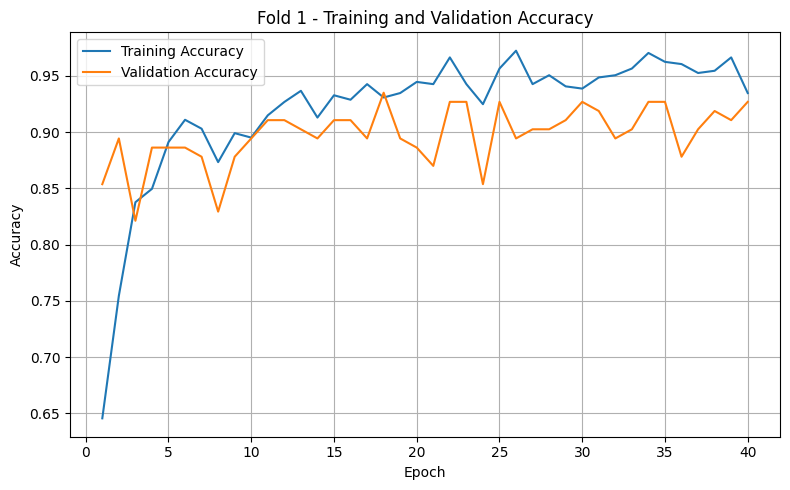

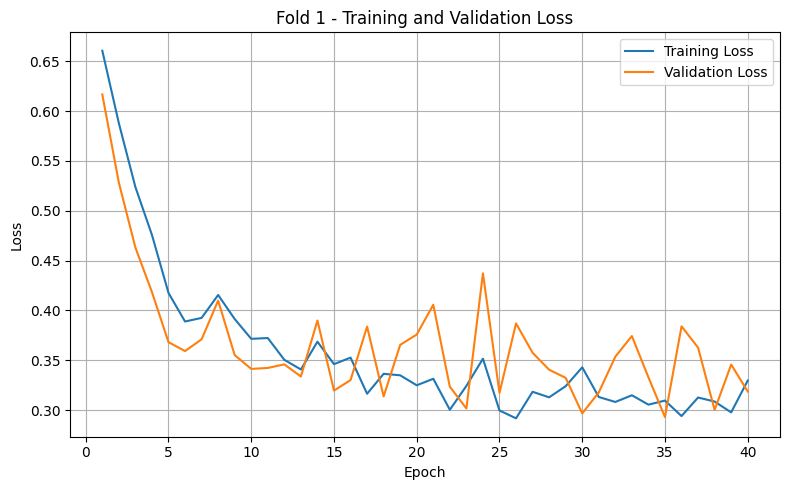


ABLATION 1 - BASELINE - FOLD 1 TEST RESULT
  Accuracy:    0.9936
  Precision:   1.0000
  Recall:      0.9892
  Specificity: 1.0000
  F1:          0.9946
  AUC:         1.0000


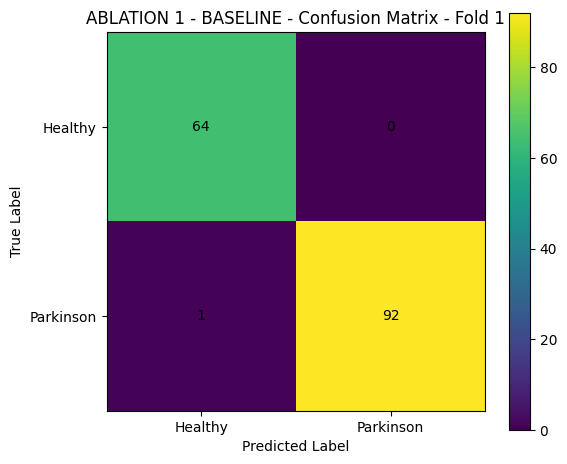


---------------------------------------------------------------------------
ABLATION 1 - BASELINE | FOLD 2/5
---------------------------------------------------------------------------
Train: 32 subjects / 502 recordings
Val:   8 subjects / 127 recordings
Test:  10 subjects / 156 recordings
Dataset initialized with 502 samples.
Dataset initialized with 127 samples.
Dataset initialized with 156 samples.
  Epoch 01 | Train Acc 0.629 | Val Acc 0.583 | Train Loss 0.665 | Val Loss 0.625 | Val AUC 0.934
  Epoch 02 | Train Acc 0.725 | Val Acc 0.780 | Train Loss 0.600 | Val Loss 0.527 | Val AUC 0.943
  Epoch 03 | Train Acc 0.817 | Val Acc 0.850 | Train Loss 0.524 | Val Loss 0.466 | Val AUC 0.958
  Epoch 04 | Train Acc 0.861 | Val Acc 0.898 | Train Loss 0.466 | Val Loss 0.390 | Val AUC 0.972
  Epoch 05 | Train Acc 0.873 | Val Acc 0.913 | Train Loss 0.436 | Val Loss 0.355 | Val AUC 0.982
  Epoch 06 | Train Acc 0.888 | Val Acc 0.937 | Train Loss 0.396 | Val Loss 0.334 | Val AUC 0.979
  Epoch 07 

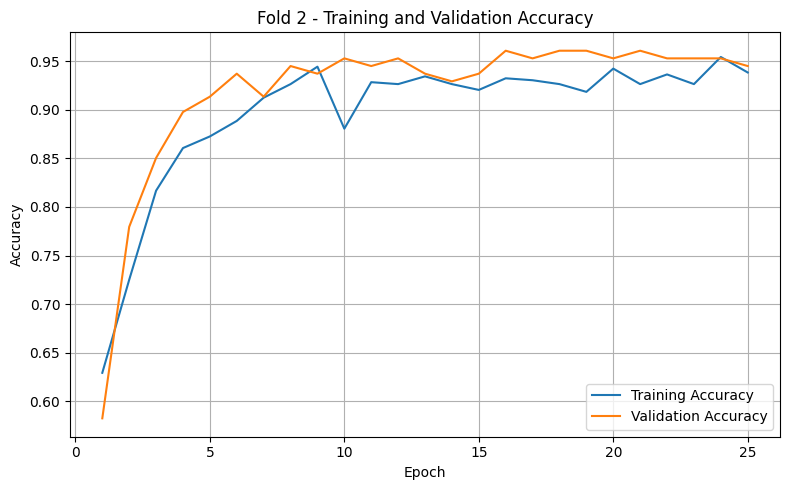

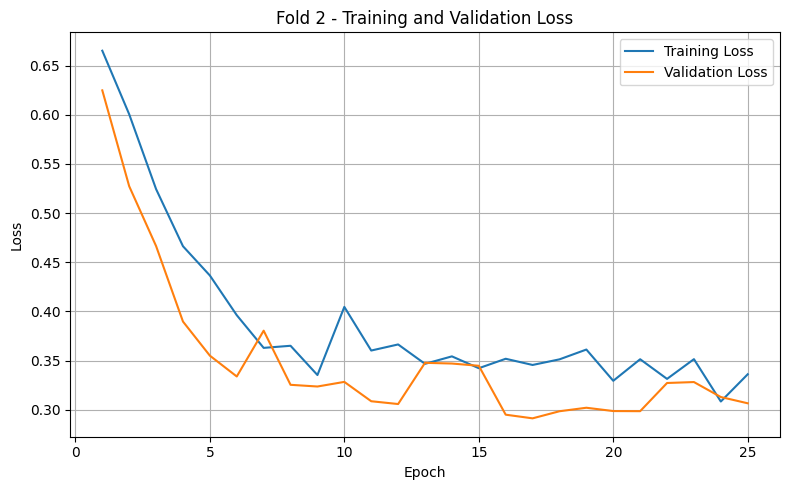


ABLATION 1 - BASELINE - FOLD 2 TEST RESULT
  Accuracy:    0.9167
  Precision:   1.0000
  Recall:      0.8632
  Specificity: 1.0000
  F1:          0.9266
  AUC:         0.9148


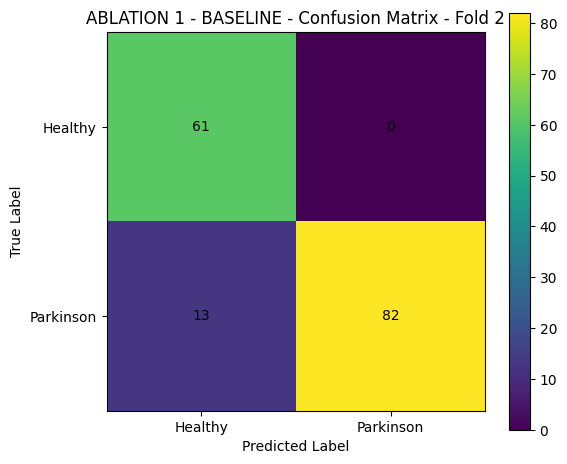


---------------------------------------------------------------------------
ABLATION 1 - BASELINE | FOLD 3/5
---------------------------------------------------------------------------
Train: 32 subjects / 506 recordings
Val:   8 subjects / 125 recordings
Test:  10 subjects / 154 recordings
Dataset initialized with 506 samples.
Dataset initialized with 125 samples.
Dataset initialized with 154 samples.
  Epoch 01 | Train Acc 0.613 | Val Acc 0.360 | Train Loss 0.661 | Val Loss 0.721 | Val AUC 0.782
  Epoch 02 | Train Acc 0.723 | Val Acc 0.744 | Train Loss 0.596 | Val Loss 0.567 | Val AUC 0.829
  Epoch 03 | Train Acc 0.789 | Val Acc 0.824 | Train Loss 0.551 | Val Loss 0.514 | Val AUC 0.872
  Epoch 04 | Train Acc 0.806 | Val Acc 0.832 | Train Loss 0.499 | Val Loss 0.469 | Val AUC 0.897
  Epoch 05 | Train Acc 0.834 | Val Acc 0.864 | Train Loss 0.470 | Val Loss 0.439 | Val AUC 0.924
  Epoch 06 | Train Acc 0.868 | Val Acc 0.888 | Train Loss 0.435 | Val Loss 0.408 | Val AUC 0.942
  Epoch 07 

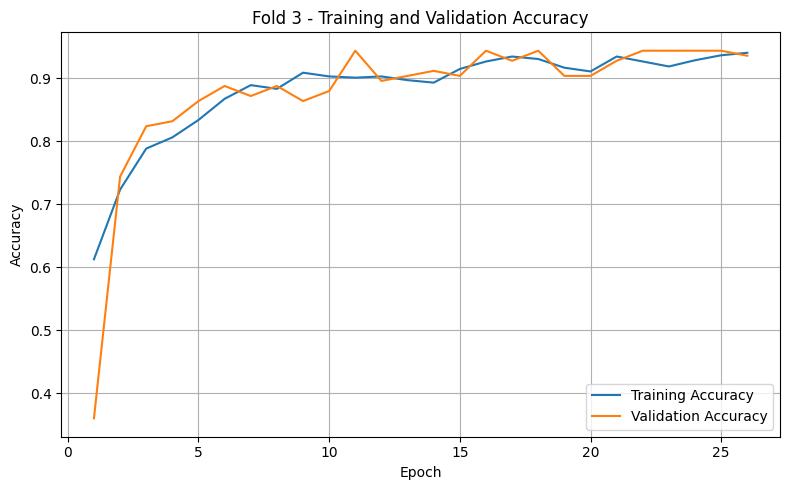

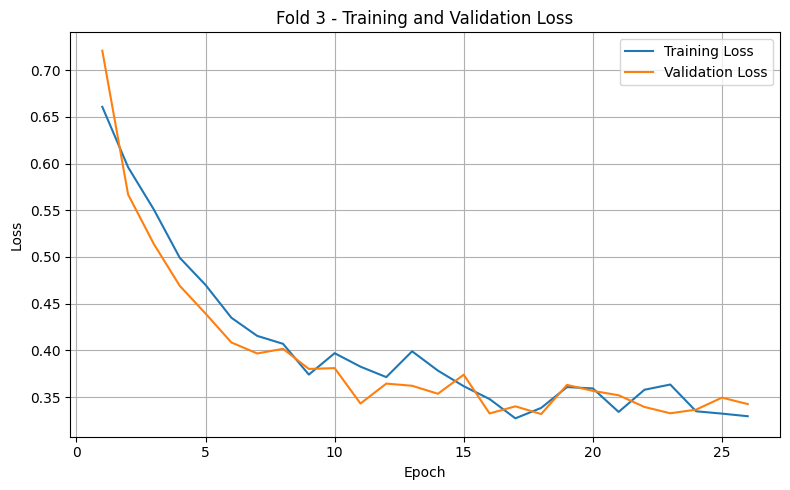


ABLATION 1 - BASELINE - FOLD 3 TEST RESULT
  Accuracy:    1.0000
  Precision:   1.0000
  Recall:      1.0000
  Specificity: 1.0000
  F1:          1.0000
  AUC:         1.0000


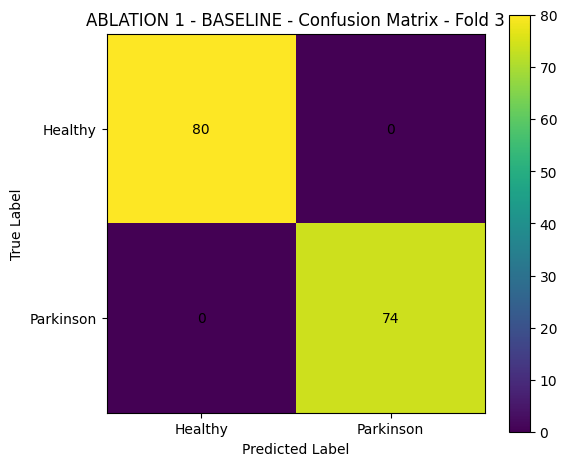


---------------------------------------------------------------------------
ABLATION 1 - BASELINE | FOLD 4/5
---------------------------------------------------------------------------
Train: 32 subjects / 499 recordings
Val:   8 subjects / 126 recordings
Test:  10 subjects / 160 recordings
Dataset initialized with 499 samples.
Dataset initialized with 126 samples.
Dataset initialized with 160 samples.
  Epoch 01 | Train Acc 0.607 | Val Acc 0.738 | Train Loss 0.663 | Val Loss 0.622 | Val AUC 0.903
  Epoch 02 | Train Acc 0.770 | Val Acc 0.817 | Train Loss 0.587 | Val Loss 0.537 | Val AUC 0.908
  Epoch 03 | Train Acc 0.788 | Val Acc 0.913 | Train Loss 0.553 | Val Loss 0.454 | Val AUC 0.974
  Epoch 04 | Train Acc 0.852 | Val Acc 0.968 | Train Loss 0.485 | Val Loss 0.371 | Val AUC 0.992
  Epoch 05 | Train Acc 0.876 | Val Acc 0.984 | Train Loss 0.435 | Val Loss 0.306 | Val AUC 0.999
  Epoch 06 | Train Acc 0.872 | Val Acc 0.984 | Train Loss 0.461 | Val Loss 0.278 | Val AUC 0.999
  Epoch 07 

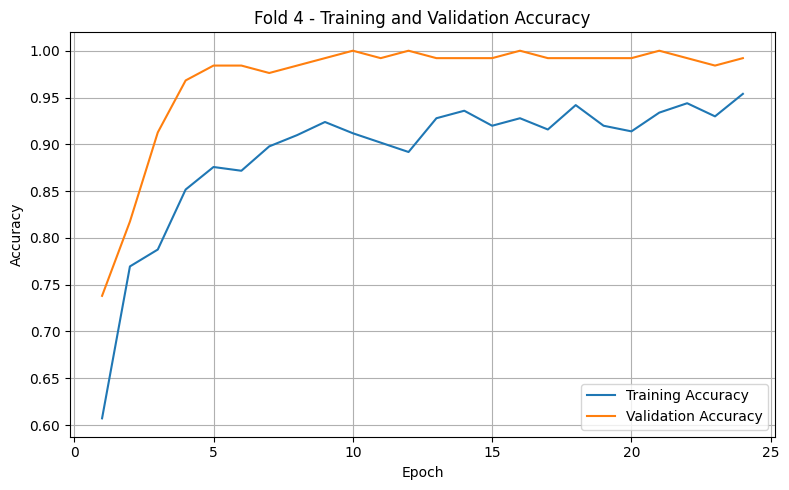

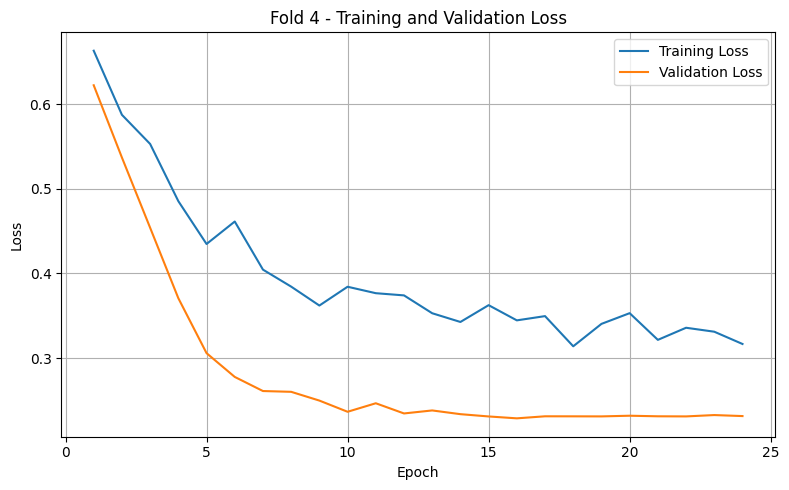


ABLATION 1 - BASELINE - FOLD 4 TEST RESULT
  Accuracy:    0.9750
  Precision:   0.9694
  Recall:      0.9896
  Specificity: 0.9531
  F1:          0.9794
  AUC:         0.9961


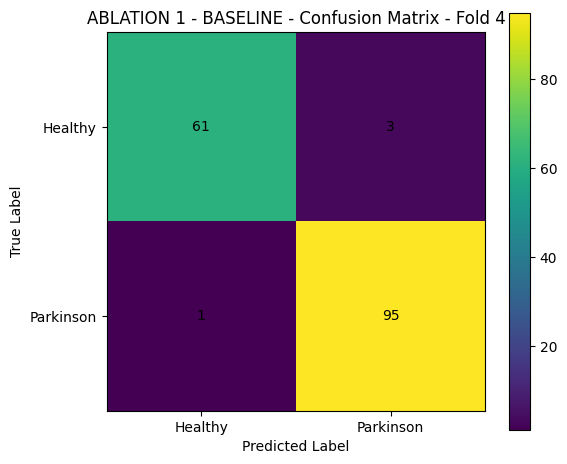


---------------------------------------------------------------------------
ABLATION 1 - BASELINE | FOLD 5/5
---------------------------------------------------------------------------
Train: 32 subjects / 499 recordings
Val:   8 subjects / 128 recordings
Test:  10 subjects / 158 recordings
Dataset initialized with 499 samples.
Dataset initialized with 128 samples.
Dataset initialized with 158 samples.
  Epoch 01 | Train Acc 0.611 | Val Acc 0.906 | Train Loss 0.655 | Val Loss 0.532 | Val AUC 0.972
  Epoch 02 | Train Acc 0.774 | Val Acc 0.914 | Train Loss 0.573 | Val Loss 0.423 | Val AUC 0.979
  Epoch 03 | Train Acc 0.802 | Val Acc 0.938 | Train Loss 0.540 | Val Loss 0.373 | Val AUC 0.991
  Epoch 04 | Train Acc 0.822 | Val Acc 0.938 | Train Loss 0.471 | Val Loss 0.338 | Val AUC 0.987
  Epoch 05 | Train Acc 0.848 | Val Acc 0.945 | Train Loss 0.450 | Val Loss 0.325 | Val AUC 0.995
  Epoch 06 | Train Acc 0.874 | Val Acc 0.961 | Train Loss 0.425 | Val Loss 0.292 | Val AUC 0.997
  Epoch 07 

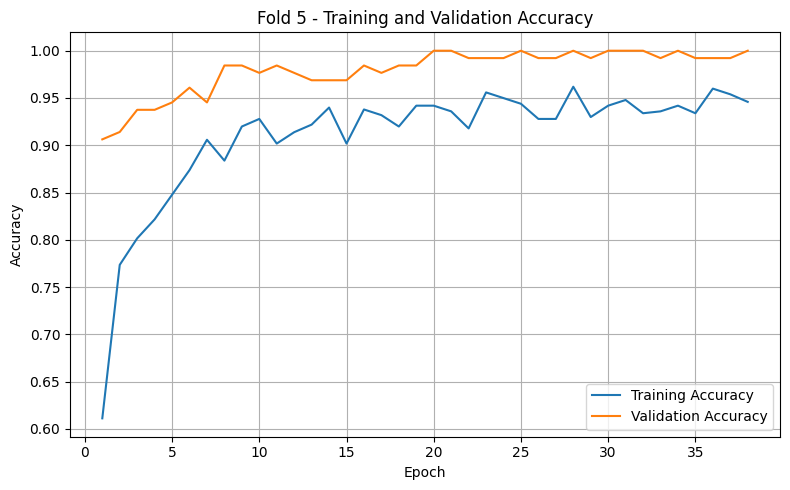

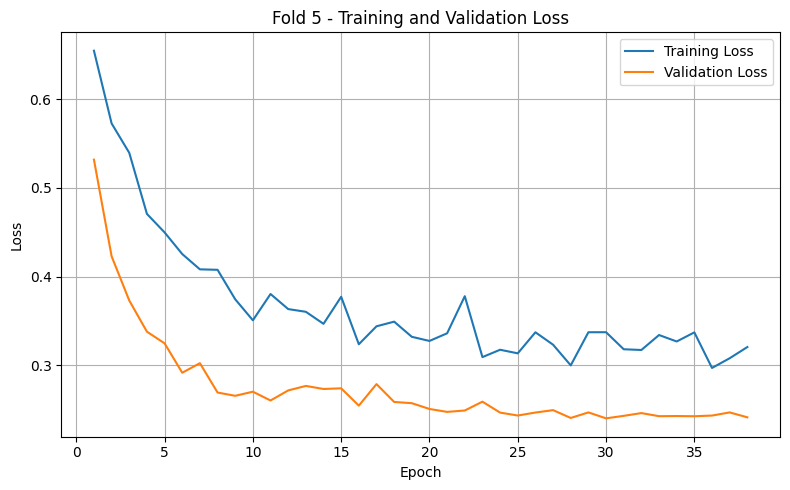


ABLATION 1 - BASELINE - FOLD 5 TEST RESULT
  Accuracy:    0.8038
  Precision:   0.7156
  Recall:      1.0000
  Specificity: 0.6125
  F1:          0.8342
  AUC:         0.9355


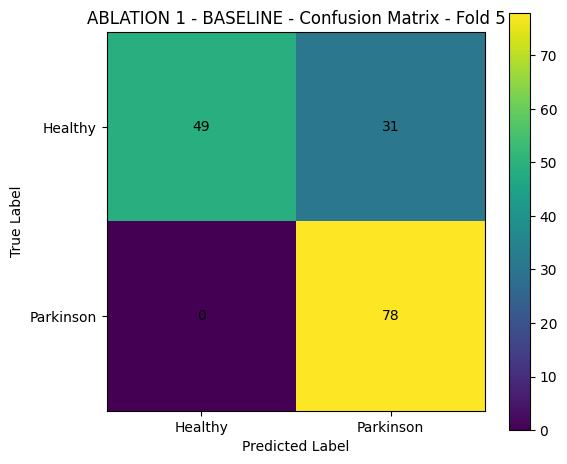


ABLATION 1 COMPLETE


In [140]:
# ============================================================
# RUN ABLATION 1
# ============================================================

ablation1_results_df, ablation1_cm, ablation1_histories = (
    run_ablation_5fold(
        model_class=Ablation1_Baseline,
        experiment_name="ABLATION 1 - BASELINE"
    )
)

print("\nABLATION 1 COMPLETE")

In [141]:
# ============================================================
# ABLATION 1 SUMMARY
# ============================================================

metrics = [
    "test_accuracy",
    "test_precision",
    "test_recall",
    "test_specificity",
    "test_f1",
    "test_auc"
]

print("\n" + "=" * 70)
print("ABLATION 1 - MEAN ± STD")
print("=" * 70)

for metric in metrics:

    mean_value = (
        ablation1_results_df[metric]
        .mean()
    )

    std_value = (
        ablation1_results_df[metric]
        .std(ddof=1)
    )

    print(
        f"{metric:20s}: "
        f"{mean_value:.4f} ± "
        f"{std_value:.4f}"
    )

print("\nAggregate Confusion Matrix:")
print(ablation1_cm)


ABLATION 1 - MEAN ± STD
test_accuracy       : 0.9378 ± 0.0818
test_precision      : 0.9370 ± 0.1245
test_recall         : 0.9684 ± 0.0591
test_specificity    : 0.9131 ± 0.1693
test_f1             : 0.9470 ± 0.0694
test_auc            : 0.9693 ± 0.0410

Aggregate Confusion Matrix:
[[315  34]
 [ 15 421]]



ABLATION 2 - BASELINE + CSRLM
5-FOLD SUBJECT-WISE CROSS-VALIDATION

---------------------------------------------------------------------------
ABLATION 2 - BASELINE + CSRLM | FOLD 1/5
---------------------------------------------------------------------------
Train: 32 subjects / 505 recordings
Val:   8 subjects / 123 recordings
Test:  10 subjects / 157 recordings
Dataset initialized with 505 samples.
Dataset initialized with 123 samples.
Dataset initialized with 157 samples.
  Epoch 01 | Train Acc 0.651 | Val Acc 0.894 | Train Loss 0.661 | Val Loss 0.602 | Val AUC 0.973
  Epoch 02 | Train Acc 0.766 | Val Acc 0.959 | Train Loss 0.589 | Val Loss 0.494 | Val AUC 0.991
  Epoch 03 | Train Acc 0.842 | Val Acc 0.935 | Train Loss 0.515 | Val Loss 0.381 | Val AUC 0.995
  Epoch 04 | Train Acc 0.885 | Val Acc 0.943 | Train Loss 0.433 | Val Loss 0.343 | Val AUC 0.996
  Epoch 05 | Train Acc 0.903 | Val Acc 0.984 | Train Loss 0.411 | Val Loss 0.286 | Val AUC 0.998
  Epoch 06 | Train Acc 0.915 | V

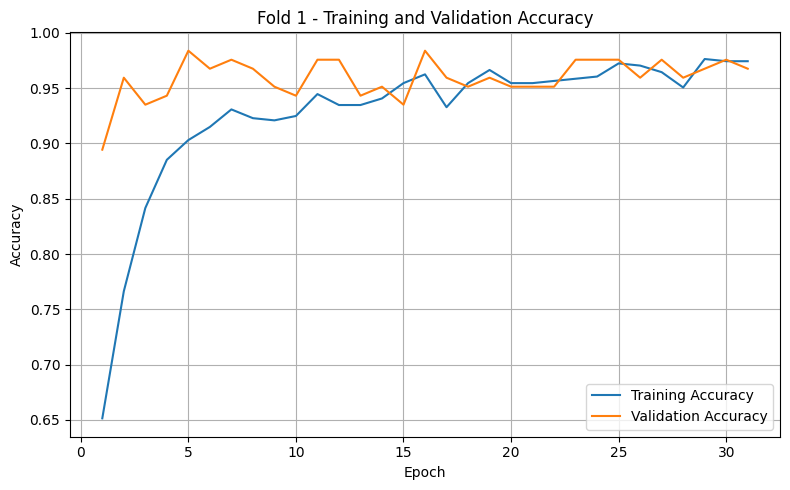

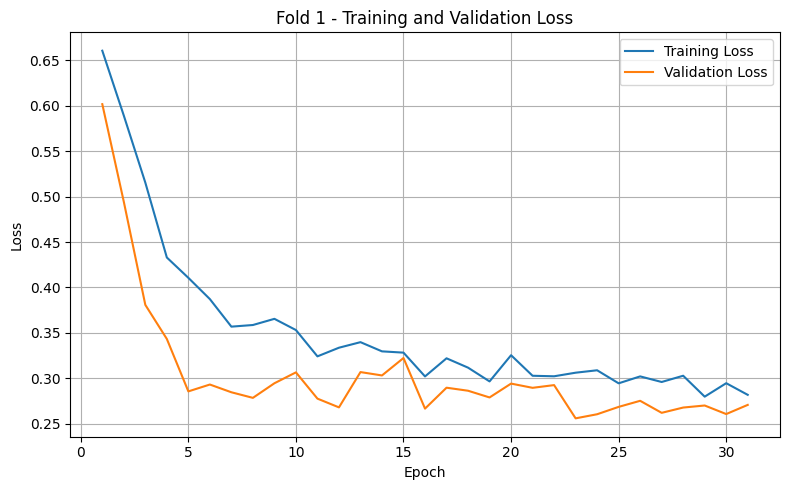


ABLATION 2 - BASELINE + CSRLM - FOLD 1 TEST RESULT
  Accuracy:    0.9936
  Precision:   1.0000
  Recall:      0.9892
  Specificity: 1.0000
  F1:          0.9946
  AUC:         1.0000


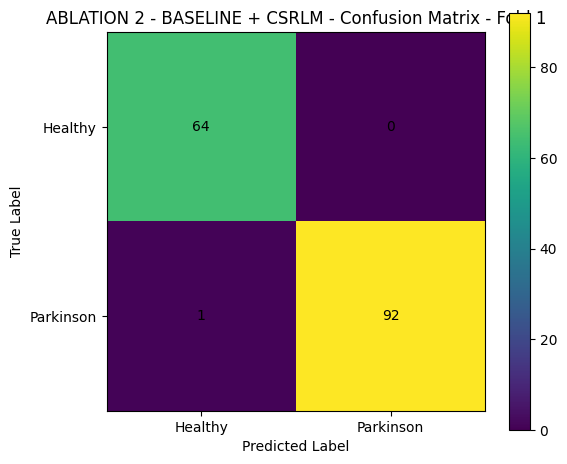


---------------------------------------------------------------------------
ABLATION 2 - BASELINE + CSRLM | FOLD 2/5
---------------------------------------------------------------------------
Train: 32 subjects / 502 recordings
Val:   8 subjects / 127 recordings
Test:  10 subjects / 156 recordings
Dataset initialized with 502 samples.
Dataset initialized with 127 samples.
Dataset initialized with 156 samples.
  Epoch 01 | Train Acc 0.614 | Val Acc 0.685 | Train Loss 0.656 | Val Loss 0.606 | Val AUC 0.903
  Epoch 02 | Train Acc 0.751 | Val Acc 0.795 | Train Loss 0.560 | Val Loss 0.515 | Val AUC 0.957
  Epoch 03 | Train Acc 0.853 | Val Acc 0.811 | Train Loss 0.470 | Val Loss 0.429 | Val AUC 0.995
  Epoch 04 | Train Acc 0.892 | Val Acc 0.937 | Train Loss 0.409 | Val Loss 0.350 | Val AUC 0.995
  Epoch 05 | Train Acc 0.916 | Val Acc 0.890 | Train Loss 0.376 | Val Loss 0.343 | Val AUC 0.998
  Epoch 06 | Train Acc 0.910 | Val Acc 0.953 | Train Loss 0.371 | Val Loss 0.291 | Val AUC 0.997
  E

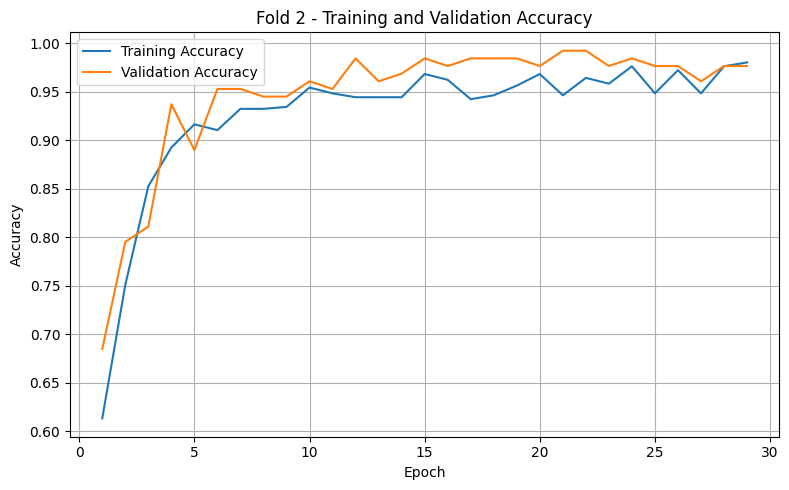

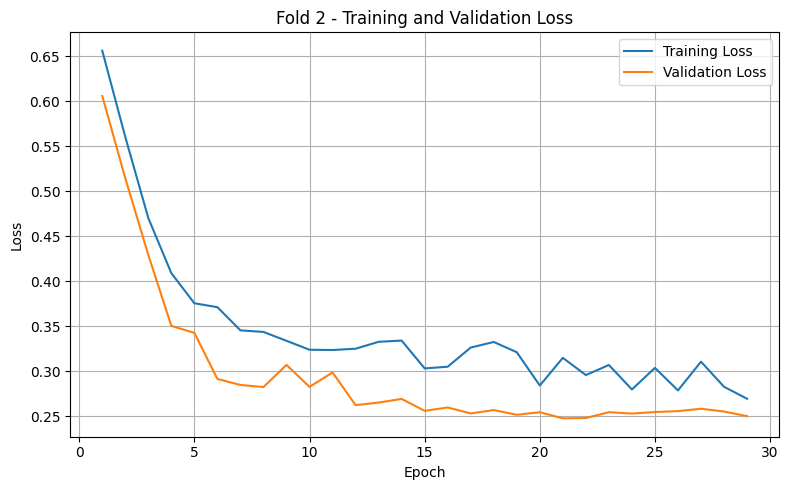


ABLATION 2 - BASELINE + CSRLM - FOLD 2 TEST RESULT
  Accuracy:    0.9038
  Precision:   0.9878
  Recall:      0.8526
  Specificity: 0.9836
  F1:          0.9153
  AUC:         0.9115


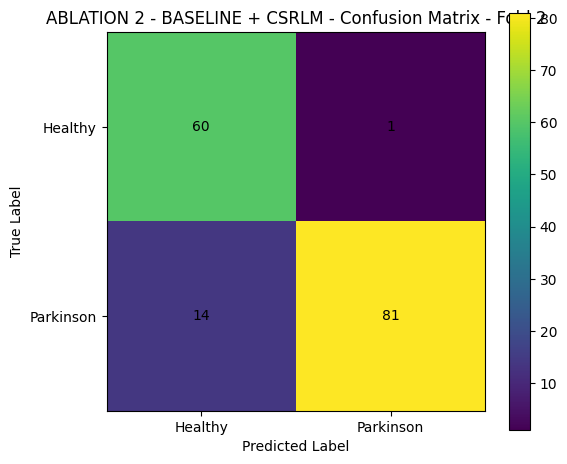


---------------------------------------------------------------------------
ABLATION 2 - BASELINE + CSRLM | FOLD 3/5
---------------------------------------------------------------------------
Train: 32 subjects / 506 recordings
Val:   8 subjects / 125 recordings
Test:  10 subjects / 154 recordings
Dataset initialized with 506 samples.
Dataset initialized with 125 samples.
Dataset initialized with 154 samples.
  Epoch 01 | Train Acc 0.648 | Val Acc 0.760 | Train Loss 0.652 | Val Loss 0.627 | Val AUC 0.836
  Epoch 02 | Train Acc 0.761 | Val Acc 0.832 | Train Loss 0.581 | Val Loss 0.546 | Val AUC 0.921
  Epoch 03 | Train Acc 0.868 | Val Acc 0.888 | Train Loss 0.490 | Val Loss 0.457 | Val AUC 0.933
  Epoch 04 | Train Acc 0.881 | Val Acc 0.880 | Train Loss 0.439 | Val Loss 0.406 | Val AUC 0.954
  Epoch 05 | Train Acc 0.889 | Val Acc 0.904 | Train Loss 0.418 | Val Loss 0.376 | Val AUC 0.964
  Epoch 06 | Train Acc 0.903 | Val Acc 0.880 | Train Loss 0.391 | Val Loss 0.369 | Val AUC 0.971
  E

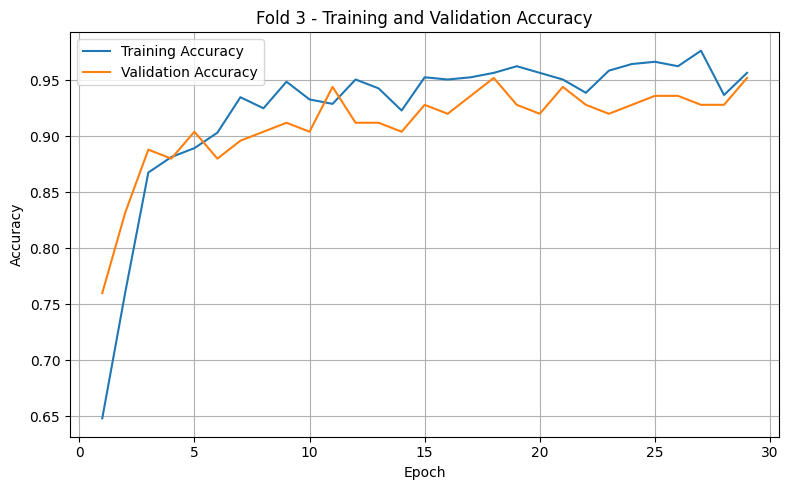

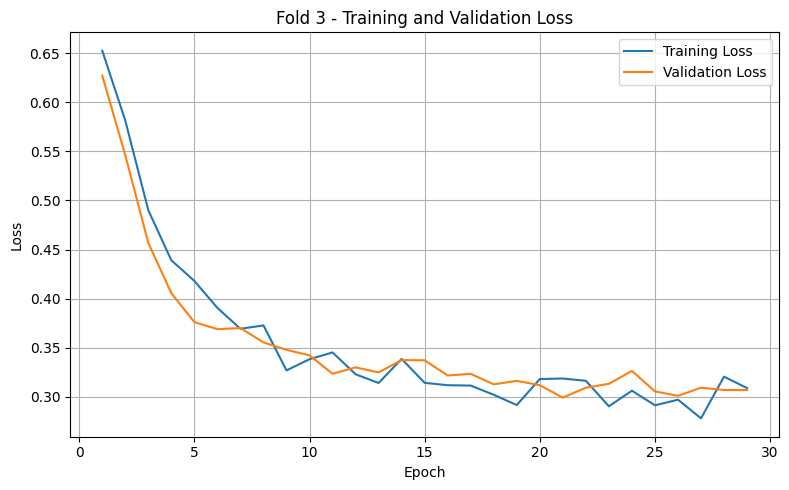


ABLATION 2 - BASELINE + CSRLM - FOLD 3 TEST RESULT
  Accuracy:    1.0000
  Precision:   1.0000
  Recall:      1.0000
  Specificity: 1.0000
  F1:          1.0000
  AUC:         1.0000


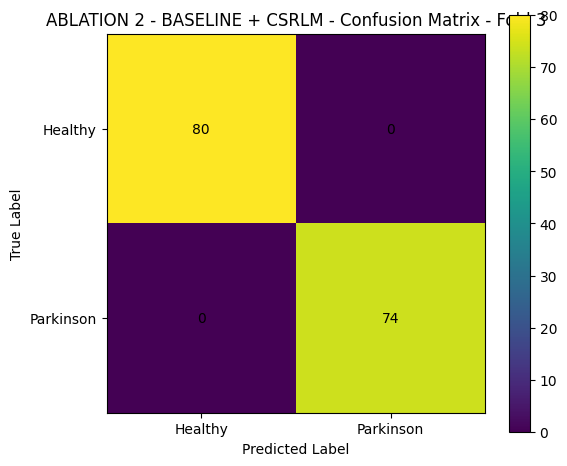


---------------------------------------------------------------------------
ABLATION 2 - BASELINE + CSRLM | FOLD 4/5
---------------------------------------------------------------------------
Train: 32 subjects / 499 recordings
Val:   8 subjects / 126 recordings
Test:  10 subjects / 160 recordings
Dataset initialized with 499 samples.
Dataset initialized with 126 samples.
Dataset initialized with 160 samples.
  Epoch 01 | Train Acc 0.645 | Val Acc 0.849 | Train Loss 0.663 | Val Loss 0.602 | Val AUC 0.903
  Epoch 02 | Train Acc 0.762 | Val Acc 0.857 | Train Loss 0.591 | Val Loss 0.513 | Val AUC 0.924
  Epoch 03 | Train Acc 0.798 | Val Acc 0.921 | Train Loss 0.537 | Val Loss 0.428 | Val AUC 0.967
  Epoch 04 | Train Acc 0.842 | Val Acc 0.952 | Train Loss 0.493 | Val Loss 0.372 | Val AUC 0.980
  Epoch 05 | Train Acc 0.836 | Val Acc 0.929 | Train Loss 0.456 | Val Loss 0.341 | Val AUC 0.985
  Epoch 06 | Train Acc 0.888 | Val Acc 0.944 | Train Loss 0.411 | Val Loss 0.319 | Val AUC 0.992
  E

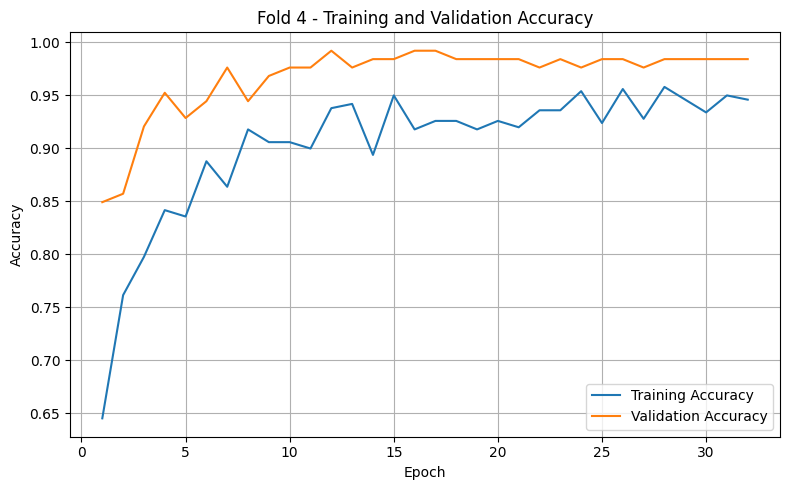

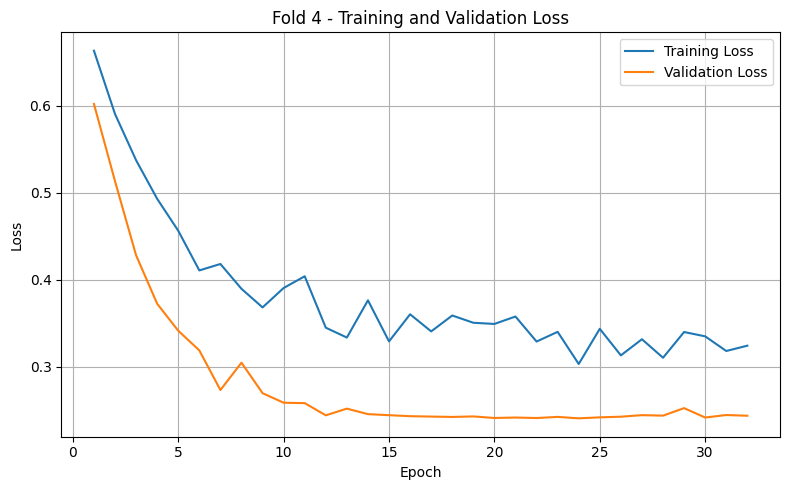


ABLATION 2 - BASELINE + CSRLM - FOLD 4 TEST RESULT
  Accuracy:    0.9812
  Precision:   1.0000
  Recall:      0.9688
  Specificity: 1.0000
  F1:          0.9841
  AUC:         0.9998


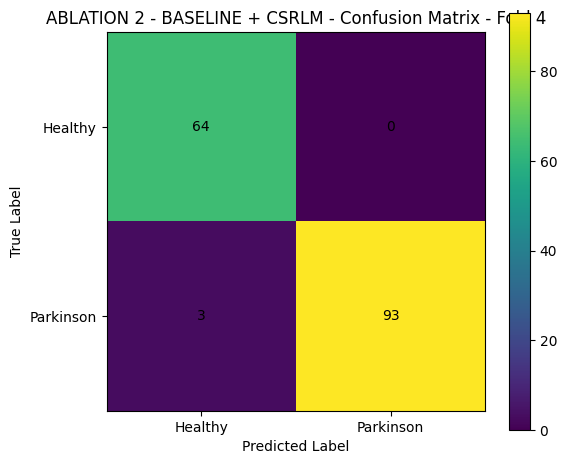


---------------------------------------------------------------------------
ABLATION 2 - BASELINE + CSRLM | FOLD 5/5
---------------------------------------------------------------------------
Train: 32 subjects / 499 recordings
Val:   8 subjects / 128 recordings
Test:  10 subjects / 158 recordings
Dataset initialized with 499 samples.
Dataset initialized with 128 samples.
Dataset initialized with 158 samples.
  Epoch 01 | Train Acc 0.585 | Val Acc 0.820 | Train Loss 0.670 | Val Loss 0.577 | Val AUC 0.949
  Epoch 02 | Train Acc 0.790 | Val Acc 0.906 | Train Loss 0.559 | Val Loss 0.451 | Val AUC 0.988
  Epoch 03 | Train Acc 0.844 | Val Acc 0.930 | Train Loss 0.495 | Val Loss 0.372 | Val AUC 0.995
  Epoch 04 | Train Acc 0.862 | Val Acc 0.961 | Train Loss 0.451 | Val Loss 0.316 | Val AUC 0.999
  Epoch 05 | Train Acc 0.898 | Val Acc 0.984 | Train Loss 0.401 | Val Loss 0.267 | Val AUC 1.000
  Epoch 06 | Train Acc 0.912 | Val Acc 0.984 | Train Loss 0.377 | Val Loss 0.267 | Val AUC 1.000
  E

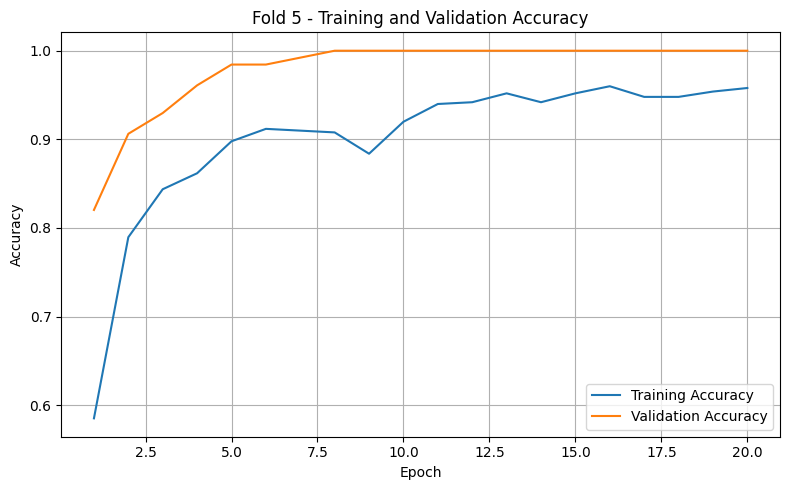

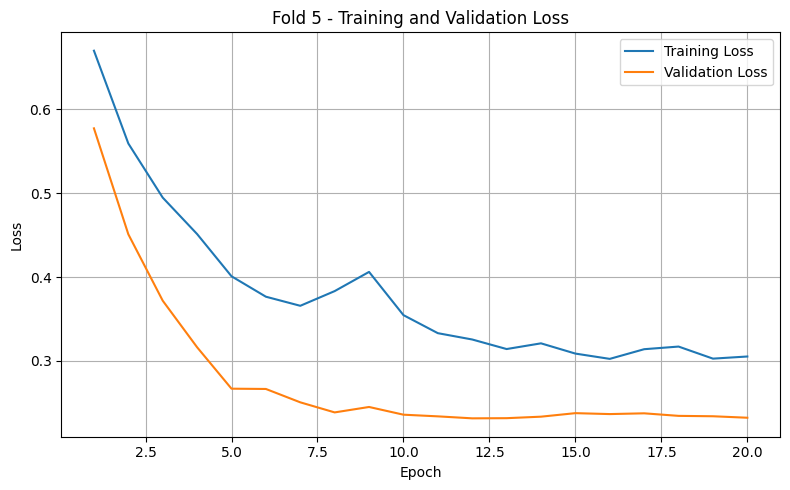


ABLATION 2 - BASELINE + CSRLM - FOLD 5 TEST RESULT
  Accuracy:    0.8165
  Precision:   0.7333
  Recall:      0.9872
  Specificity: 0.6500
  F1:          0.8415
  AUC:         0.9174


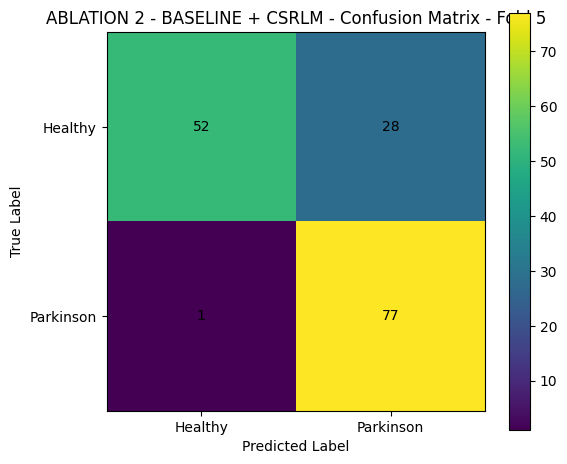


ABLATION 2 COMPLETE


In [142]:
# ============================================================
# RUN ABLATION 2
# BASELINE + CSRLM
# ============================================================

ablation2_results_df, ablation2_cm, ablation2_histories = (
    run_ablation_5fold(
        model_class=Ablation2_CSRLM,
        experiment_name="ABLATION 2 - BASELINE + CSRLM"
    )
)

print("\nABLATION 2 COMPLETE")

In [143]:
# ============================================================
# ABLATION 2 SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("ABLATION 2 - MEAN ± STD")
print("=" * 70)

for metric in metrics:

    mean_value = (
        ablation2_results_df[metric]
        .mean()
    )

    std_value = (
        ablation2_results_df[metric]
        .std(ddof=1)
    )

    print(
        f"{metric:20s}: "
        f"{mean_value:.4f} ± "
        f"{std_value:.4f}"
    )

print("\nAggregate Confusion Matrix:")
print(ablation2_cm)


ABLATION 2 - MEAN ± STD
test_accuracy       : 0.9390 ± 0.0787
test_precision      : 0.9442 ± 0.1180
test_recall         : 0.9596 ± 0.0608
test_specificity    : 0.9267 ± 0.1549
test_f1             : 0.9471 ± 0.0682
test_auc            : 0.9657 ± 0.0469

Aggregate Confusion Matrix:
[[320  29]
 [ 19 417]]



ABLATION 3 - BASELINE + CSRLM + FIEM
5-FOLD SUBJECT-WISE CROSS-VALIDATION

---------------------------------------------------------------------------
ABLATION 3 - BASELINE + CSRLM + FIEM | FOLD 1/5
---------------------------------------------------------------------------
Train: 32 subjects / 505 recordings
Val:   8 subjects / 123 recordings
Test:  10 subjects / 157 recordings
Dataset initialized with 505 samples.
Dataset initialized with 123 samples.
Dataset initialized with 157 samples.
  Epoch 01 | Train Acc 0.663 | Val Acc 0.846 | Train Loss 0.643 | Val Loss 0.503 | Val AUC 0.956
  Epoch 02 | Train Acc 0.859 | Val Acc 0.919 | Train Loss 0.477 | Val Loss 0.333 | Val AUC 0.993
  Epoch 03 | Train Acc 0.927 | Val Acc 0.959 | Train Loss 0.376 | Val Loss 0.287 | Val AUC 0.996
  Epoch 04 | Train Acc 0.897 | Val Acc 0.943 | Train Loss 0.365 | Val Loss 0.306 | Val AUC 0.992
  Epoch 05 | Train Acc 0.931 | Val Acc 0.959 | Train Loss 0.335 | Val Loss 0.277 | Val AUC 0.996
  Epoch 06 | Train

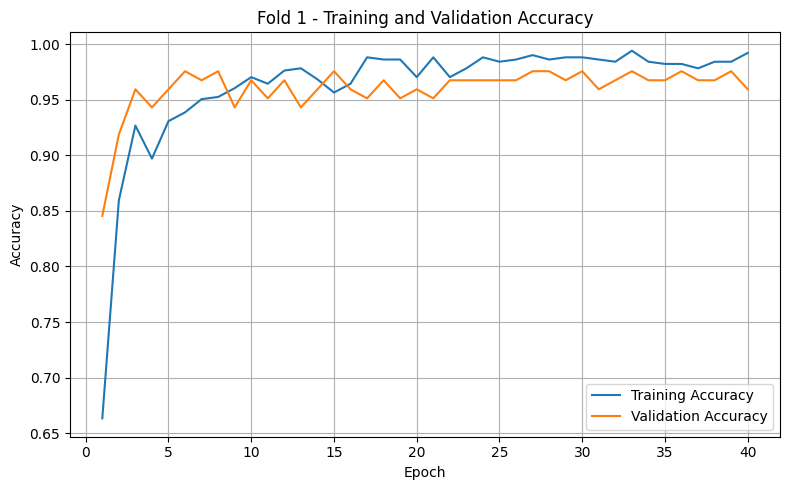

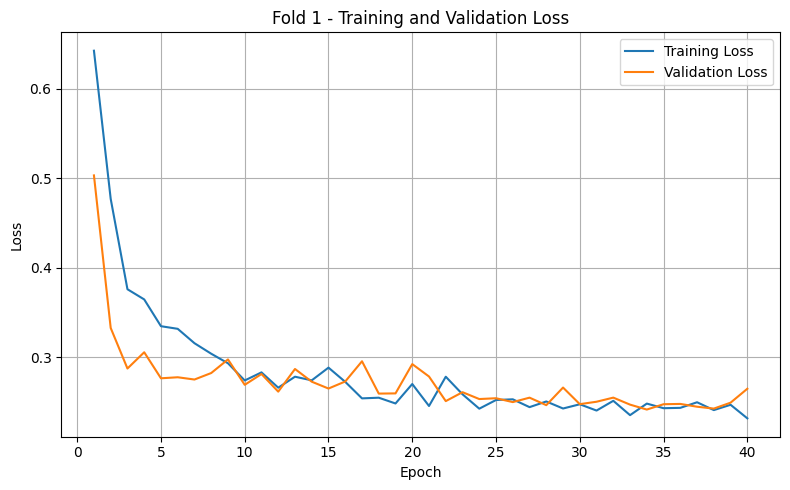


ABLATION 3 - BASELINE + CSRLM + FIEM - FOLD 1 TEST RESULT
  Accuracy:    0.9936
  Precision:   1.0000
  Recall:      0.9892
  Specificity: 1.0000
  F1:          0.9946
  AUC:         1.0000


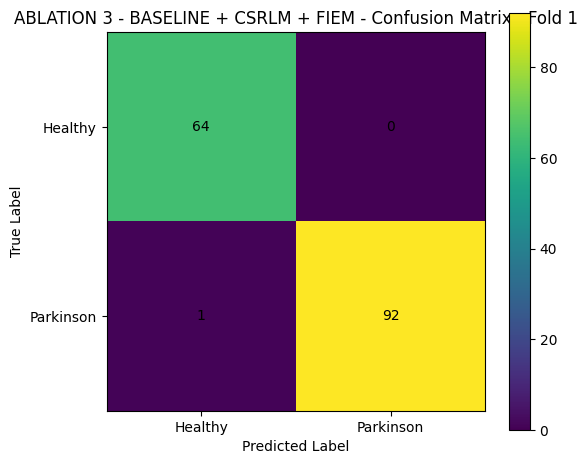


---------------------------------------------------------------------------
ABLATION 3 - BASELINE + CSRLM + FIEM | FOLD 2/5
---------------------------------------------------------------------------
Train: 32 subjects / 502 recordings
Val:   8 subjects / 127 recordings
Test:  10 subjects / 156 recordings
Dataset initialized with 502 samples.
Dataset initialized with 127 samples.
Dataset initialized with 156 samples.
  Epoch 01 | Train Acc 0.665 | Val Acc 0.874 | Train Loss 0.641 | Val Loss 0.507 | Val AUC 0.960
  Epoch 02 | Train Acc 0.875 | Val Acc 0.898 | Train Loss 0.469 | Val Loss 0.363 | Val AUC 0.991
  Epoch 03 | Train Acc 0.938 | Val Acc 0.969 | Train Loss 0.339 | Val Loss 0.262 | Val AUC 1.000
  Epoch 04 | Train Acc 0.926 | Val Acc 0.969 | Train Loss 0.347 | Val Loss 0.261 | Val AUC 1.000
  Epoch 05 | Train Acc 0.970 | Val Acc 0.961 | Train Loss 0.287 | Val Loss 0.274 | Val AUC 1.000
  Epoch 06 | Train Acc 0.962 | Val Acc 0.961 | Train Loss 0.295 | Val Loss 0.260 | Val AUC 1.

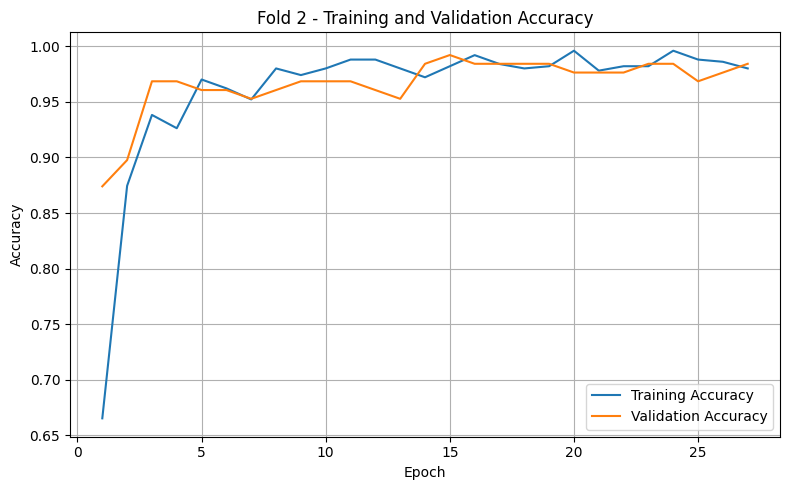

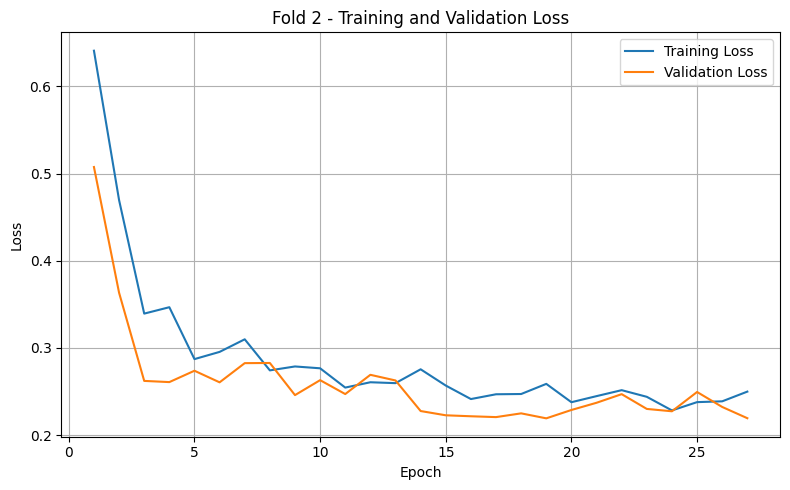


ABLATION 3 - BASELINE + CSRLM + FIEM - FOLD 2 TEST RESULT
  Accuracy:    0.9231
  Precision:   1.0000
  Recall:      0.8737
  Specificity: 1.0000
  F1:          0.9326
  AUC:         0.9213


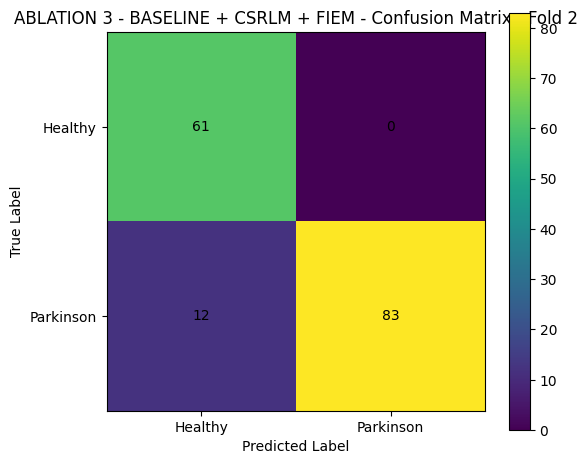


---------------------------------------------------------------------------
ABLATION 3 - BASELINE + CSRLM + FIEM | FOLD 3/5
---------------------------------------------------------------------------
Train: 32 subjects / 506 recordings
Val:   8 subjects / 125 recordings
Test:  10 subjects / 154 recordings
Dataset initialized with 506 samples.
Dataset initialized with 125 samples.
Dataset initialized with 154 samples.
  Epoch 01 | Train Acc 0.717 | Val Acc 0.736 | Train Loss 0.629 | Val Loss 0.587 | Val AUC 0.875
  Epoch 02 | Train Acc 0.893 | Val Acc 0.856 | Train Loss 0.444 | Val Loss 0.408 | Val AUC 0.942
  Epoch 03 | Train Acc 0.917 | Val Acc 0.872 | Train Loss 0.377 | Val Loss 0.390 | Val AUC 0.947
  Epoch 04 | Train Acc 0.919 | Val Acc 0.912 | Train Loss 0.351 | Val Loss 0.363 | Val AUC 0.967
  Epoch 05 | Train Acc 0.951 | Val Acc 0.928 | Train Loss 0.304 | Val Loss 0.340 | Val AUC 0.977
  Epoch 06 | Train Acc 0.943 | Val Acc 0.920 | Train Loss 0.323 | Val Loss 0.340 | Val AUC 0.

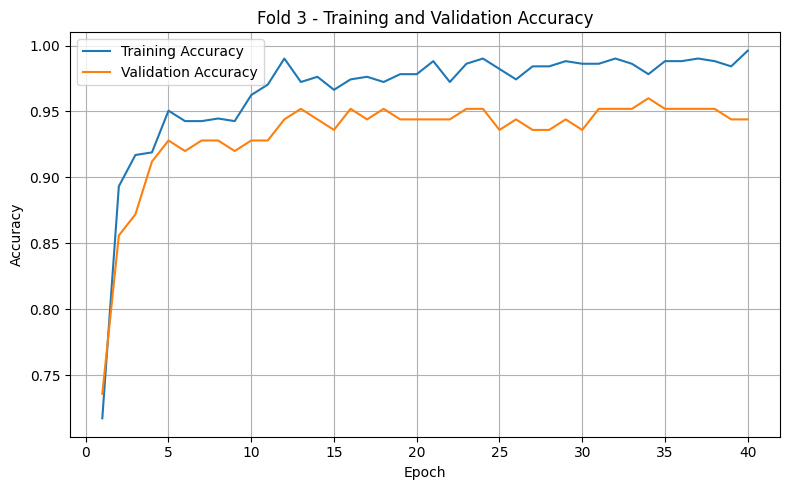

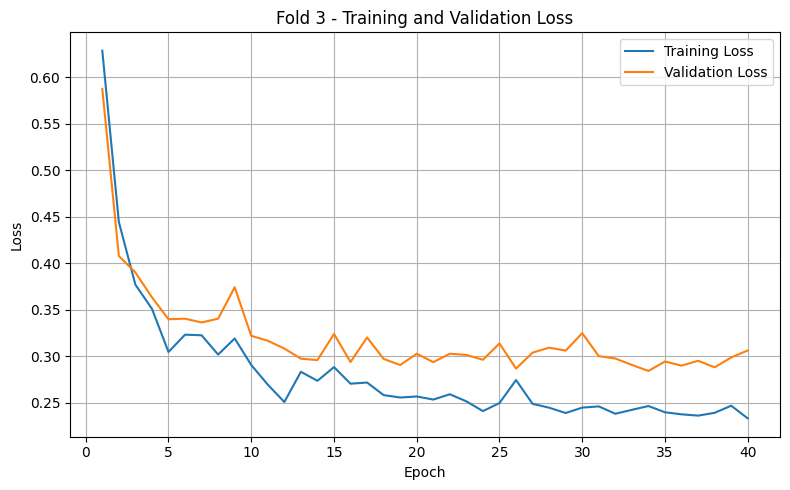


ABLATION 3 - BASELINE + CSRLM + FIEM - FOLD 3 TEST RESULT
  Accuracy:    1.0000
  Precision:   1.0000
  Recall:      1.0000
  Specificity: 1.0000
  F1:          1.0000
  AUC:         1.0000


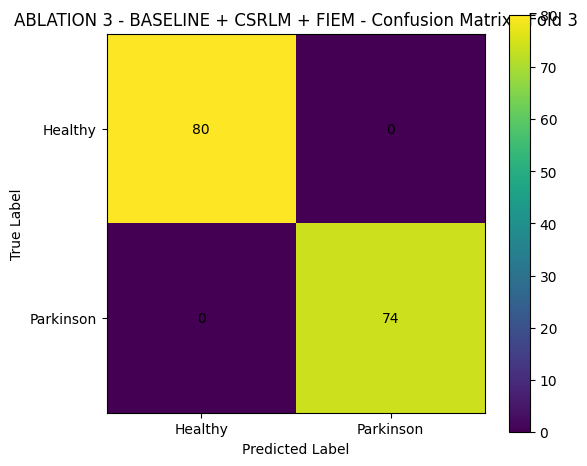


---------------------------------------------------------------------------
ABLATION 3 - BASELINE + CSRLM + FIEM | FOLD 4/5
---------------------------------------------------------------------------
Train: 32 subjects / 499 recordings
Val:   8 subjects / 126 recordings
Test:  10 subjects / 160 recordings
Dataset initialized with 499 samples.
Dataset initialized with 126 samples.
Dataset initialized with 160 samples.
  Epoch 01 | Train Acc 0.667 | Val Acc 0.810 | Train Loss 0.624 | Val Loss 0.516 | Val AUC 0.912
  Epoch 02 | Train Acc 0.810 | Val Acc 0.889 | Train Loss 0.509 | Val Loss 0.404 | Val AUC 0.949
  Epoch 03 | Train Acc 0.850 | Val Acc 0.944 | Train Loss 0.430 | Val Loss 0.328 | Val AUC 0.987
  Epoch 04 | Train Acc 0.914 | Val Acc 0.960 | Train Loss 0.378 | Val Loss 0.298 | Val AUC 0.993
  Epoch 05 | Train Acc 0.908 | Val Acc 0.984 | Train Loss 0.375 | Val Loss 0.252 | Val AUC 0.999
  Epoch 06 | Train Acc 0.936 | Val Acc 0.984 | Train Loss 0.351 | Val Loss 0.249 | Val AUC 0.

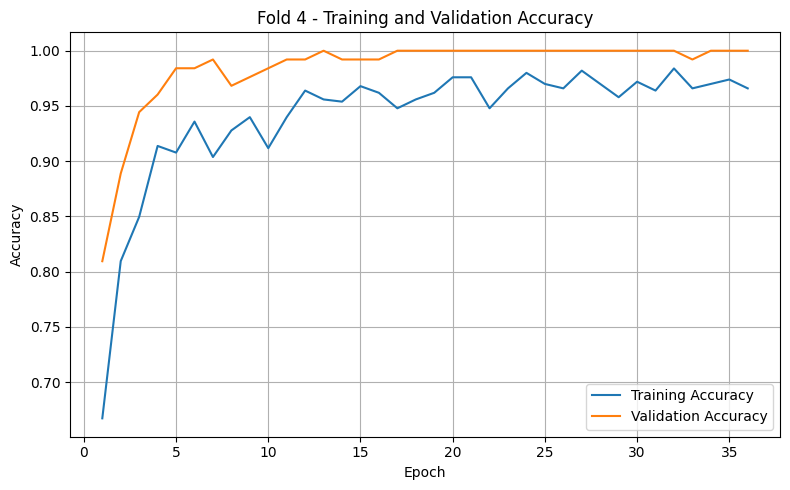

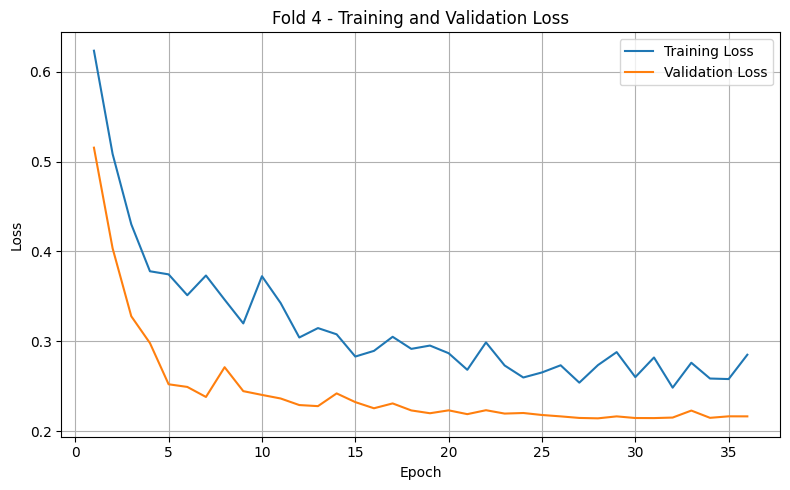


ABLATION 3 - BASELINE + CSRLM + FIEM - FOLD 4 TEST RESULT
  Accuracy:    0.9938
  Precision:   0.9897
  Recall:      1.0000
  Specificity: 0.9844
  F1:          0.9948
  AUC:         0.9998


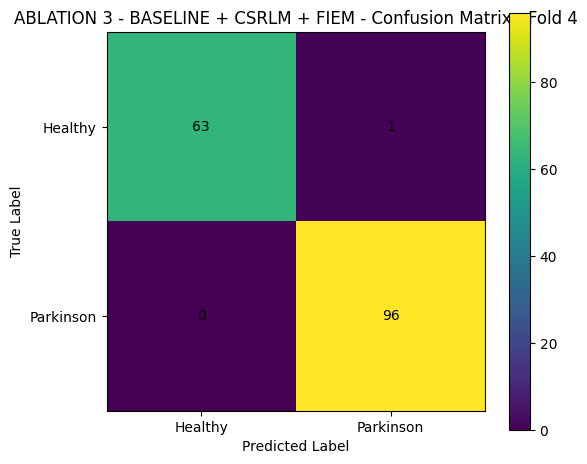


---------------------------------------------------------------------------
ABLATION 3 - BASELINE + CSRLM + FIEM | FOLD 5/5
---------------------------------------------------------------------------
Train: 32 subjects / 499 recordings
Val:   8 subjects / 128 recordings
Test:  10 subjects / 158 recordings
Dataset initialized with 499 samples.
Dataset initialized with 128 samples.
Dataset initialized with 158 samples.
  Epoch 01 | Train Acc 0.735 | Val Acc 0.633 | Train Loss 0.615 | Val Loss 0.683 | Val AUC 0.891
  Epoch 02 | Train Acc 0.824 | Val Acc 0.906 | Train Loss 0.495 | Val Loss 0.382 | Val AUC 0.990
  Epoch 03 | Train Acc 0.884 | Val Acc 0.984 | Train Loss 0.403 | Val Loss 0.264 | Val AUC 1.000
  Epoch 04 | Train Acc 0.900 | Val Acc 0.977 | Train Loss 0.401 | Val Loss 0.266 | Val AUC 1.000
  Epoch 05 | Train Acc 0.936 | Val Acc 0.969 | Train Loss 0.341 | Val Loss 0.266 | Val AUC 1.000
  Epoch 06 | Train Acc 0.940 | Val Acc 0.945 | Train Loss 0.327 | Val Loss 0.314 | Val AUC 1.

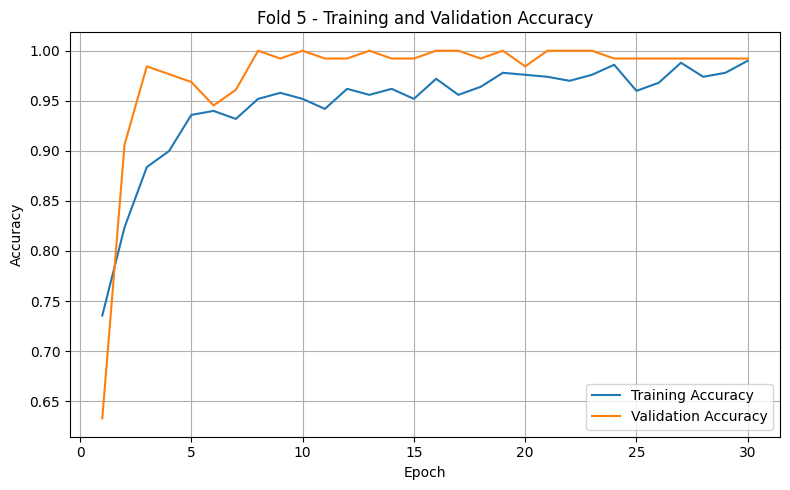

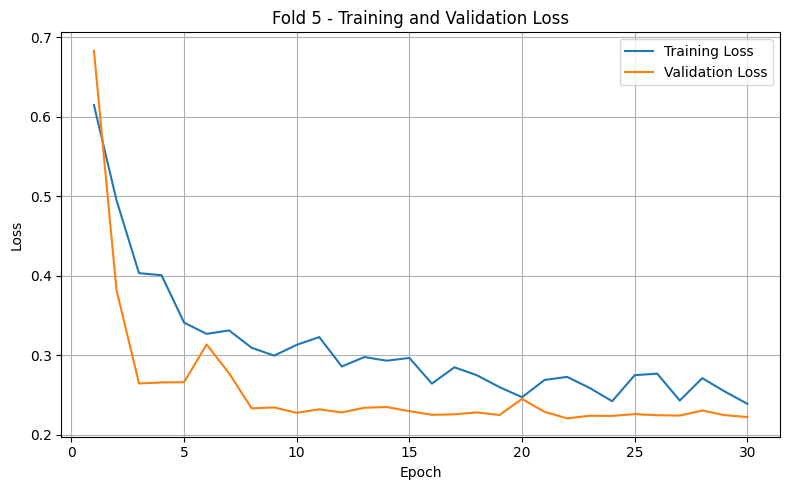


ABLATION 3 - BASELINE + CSRLM + FIEM - FOLD 5 TEST RESULT
  Accuracy:    0.8165
  Precision:   0.7290
  Recall:      1.0000
  Specificity: 0.6375
  F1:          0.8432
  AUC:         0.9554


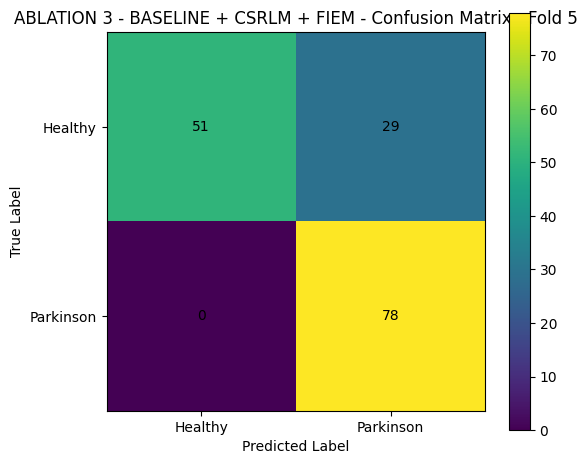


ABLATION 3 COMPLETE


In [144]:
# ============================================================
# RUN ABLATION 3
# BASELINE + CSRLM + FIEM
# ============================================================

ablation3_results_df, ablation3_cm, ablation3_histories = (
    run_ablation_5fold(
        model_class=Ablation3_CSRLM_FIEM,
        experiment_name="ABLATION 3 - BASELINE + CSRLM + FIEM"
    )
)

print("\nABLATION 3 COMPLETE")

In [145]:
# ============================================================
# ABLATION 3 SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("ABLATION 3 - MEAN ± STD")
print("=" * 70)

for metric in metrics:

    mean_value = (
        ablation3_results_df[metric]
        .mean()
    )

    std_value = (
        ablation3_results_df[metric]
        .std(ddof=1)
    )

    print(
        f"{metric:20s}: "
        f"{mean_value:.4f} ± "
        f"{std_value:.4f}"
    )

print("\nAggregate Confusion Matrix:")
print(ablation3_cm)


ABLATION 3 - MEAN ± STD
test_accuracy       : 0.9454 ± 0.0787
test_precision      : 0.9437 ± 0.1201
test_recall         : 0.9726 ± 0.0555
test_specificity    : 0.9244 ± 0.1605
test_f1             : 0.9530 ± 0.0674
test_auc            : 0.9753 ± 0.0358

Aggregate Confusion Matrix:
[[319  30]
 [ 13 423]]



ABLATION 4 - BASELINE + CSRLM + FIEM + ASFM
5-FOLD SUBJECT-WISE CROSS-VALIDATION

---------------------------------------------------------------------------
ABLATION 4 - BASELINE + CSRLM + FIEM + ASFM | FOLD 1/5
---------------------------------------------------------------------------
Train: 32 subjects / 505 recordings
Val:   8 subjects / 123 recordings
Test:  10 subjects / 157 recordings
Dataset initialized with 505 samples.
Dataset initialized with 123 samples.
Dataset initialized with 157 samples.
  Epoch 01 | Train Acc 0.701 | Val Acc 0.553 | Train Loss 0.614 | Val Loss 0.736 | Val AUC 0.675
  Epoch 02 | Train Acc 0.840 | Val Acc 0.797 | Train Loss 0.506 | Val Loss 0.468 | Val AUC 0.935
  Epoch 03 | Train Acc 0.850 | Val Acc 0.870 | Train Loss 0.466 | Val Loss 0.409 | Val AUC 0.955
  Epoch 04 | Train Acc 0.871 | Val Acc 0.919 | Train Loss 0.429 | Val Loss 0.353 | Val AUC 0.978
  Epoch 05 | Train Acc 0.885 | Val Acc 0.919 | Train Loss 0.402 | Val Loss 0.328 | Val AUC 0.985
  Ep

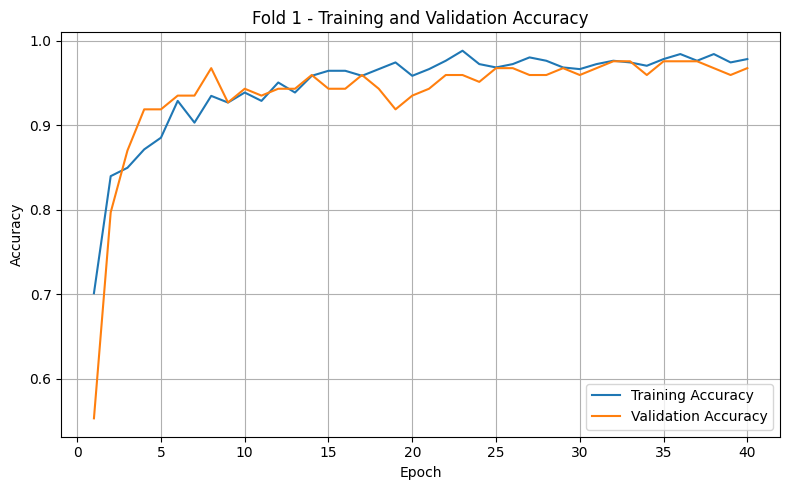

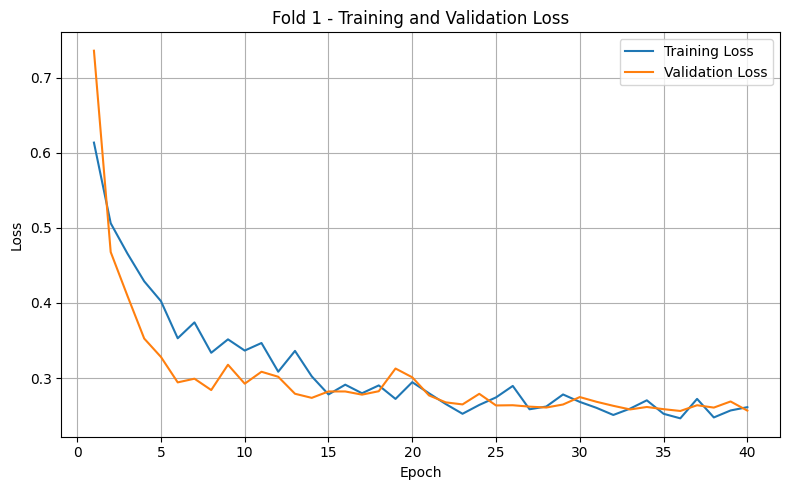


ABLATION 4 - BASELINE + CSRLM + FIEM + ASFM - FOLD 1 TEST RESULT
  Accuracy:    1.0000
  Precision:   1.0000
  Recall:      1.0000
  Specificity: 1.0000
  F1:          1.0000
  AUC:         1.0000


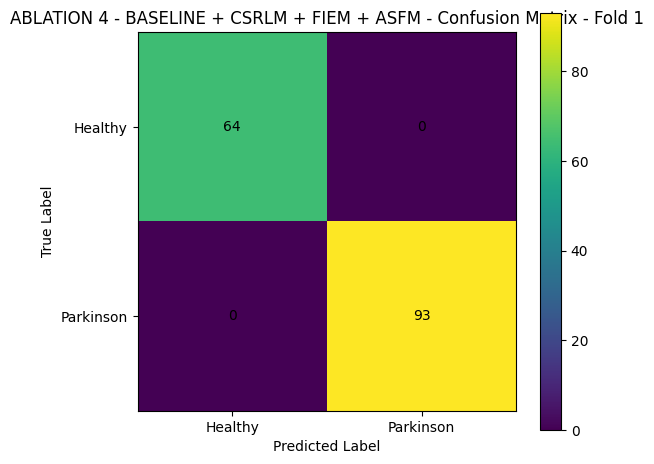


---------------------------------------------------------------------------
ABLATION 4 - BASELINE + CSRLM + FIEM + ASFM | FOLD 2/5
---------------------------------------------------------------------------
Train: 32 subjects / 502 recordings
Val:   8 subjects / 127 recordings
Test:  10 subjects / 156 recordings
Dataset initialized with 502 samples.
Dataset initialized with 127 samples.
Dataset initialized with 156 samples.
  Epoch 01 | Train Acc 0.659 | Val Acc 0.929 | Train Loss 0.613 | Val Loss 0.455 | Val AUC 0.982
  Epoch 02 | Train Acc 0.886 | Val Acc 0.921 | Train Loss 0.421 | Val Loss 0.355 | Val AUC 0.982
  Epoch 03 | Train Acc 0.914 | Val Acc 0.953 | Train Loss 0.363 | Val Loss 0.329 | Val AUC 0.985
  Epoch 04 | Train Acc 0.926 | Val Acc 0.961 | Train Loss 0.345 | Val Loss 0.313 | Val AUC 0.986
  Epoch 05 | Train Acc 0.930 | Val Acc 0.961 | Train Loss 0.360 | Val Loss 0.310 | Val AUC 0.989
  Epoch 06 | Train Acc 0.956 | Val Acc 0.969 | Train Loss 0.314 | Val Loss 0.303 | Val

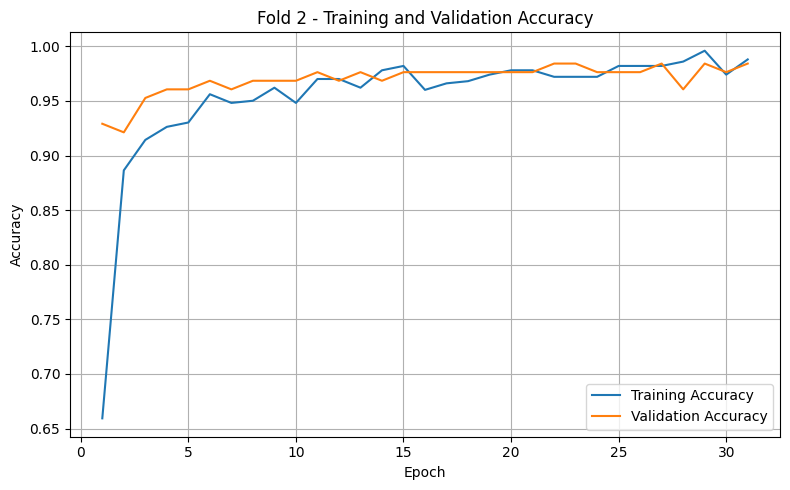

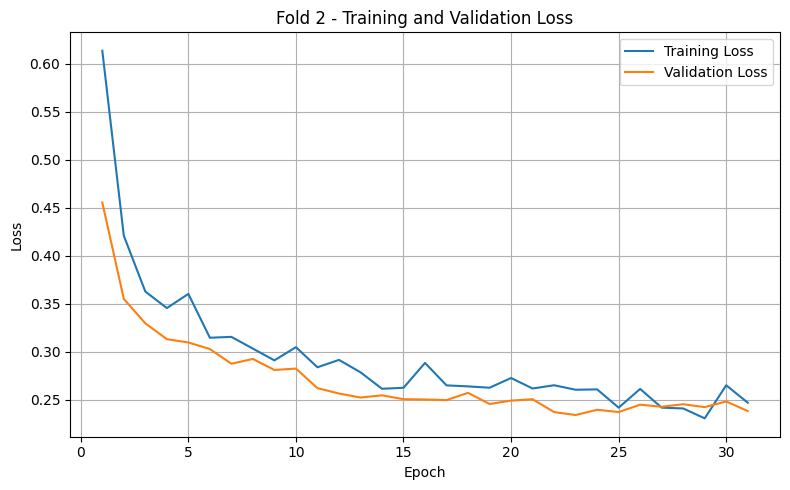


ABLATION 4 - BASELINE + CSRLM + FIEM + ASFM - FOLD 2 TEST RESULT
  Accuracy:    0.9103
  Precision:   0.9880
  Recall:      0.8632
  Specificity: 0.9836
  F1:          0.9213
  AUC:         0.9104


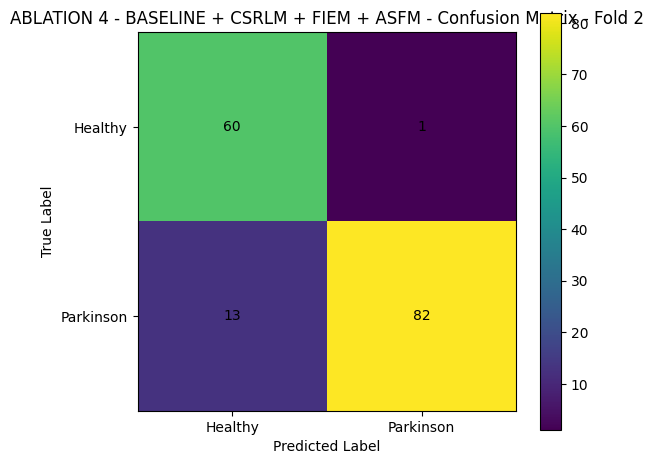


---------------------------------------------------------------------------
ABLATION 4 - BASELINE + CSRLM + FIEM + ASFM | FOLD 3/5
---------------------------------------------------------------------------
Train: 32 subjects / 506 recordings
Val:   8 subjects / 125 recordings
Test:  10 subjects / 154 recordings
Dataset initialized with 506 samples.
Dataset initialized with 125 samples.
Dataset initialized with 154 samples.
  Epoch 01 | Train Acc 0.717 | Val Acc 0.824 | Train Loss 0.608 | Val Loss 0.513 | Val AUC 0.886
  Epoch 02 | Train Acc 0.875 | Val Acc 0.888 | Train Loss 0.442 | Val Loss 0.419 | Val AUC 0.943
  Epoch 03 | Train Acc 0.925 | Val Acc 0.888 | Train Loss 0.357 | Val Loss 0.375 | Val AUC 0.960
  Epoch 04 | Train Acc 0.919 | Val Acc 0.920 | Train Loss 0.351 | Val Loss 0.357 | Val AUC 0.972
  Epoch 05 | Train Acc 0.929 | Val Acc 0.904 | Train Loss 0.351 | Val Loss 0.349 | Val AUC 0.979
  Epoch 06 | Train Acc 0.955 | Val Acc 0.888 | Train Loss 0.319 | Val Loss 0.386 | Val

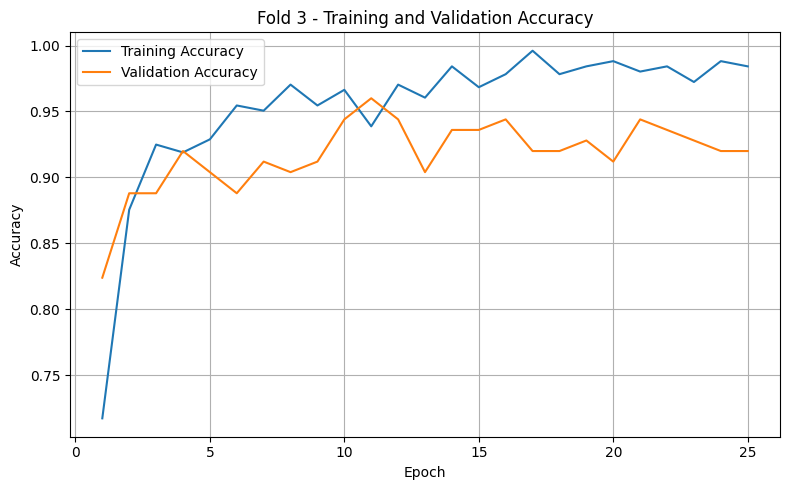

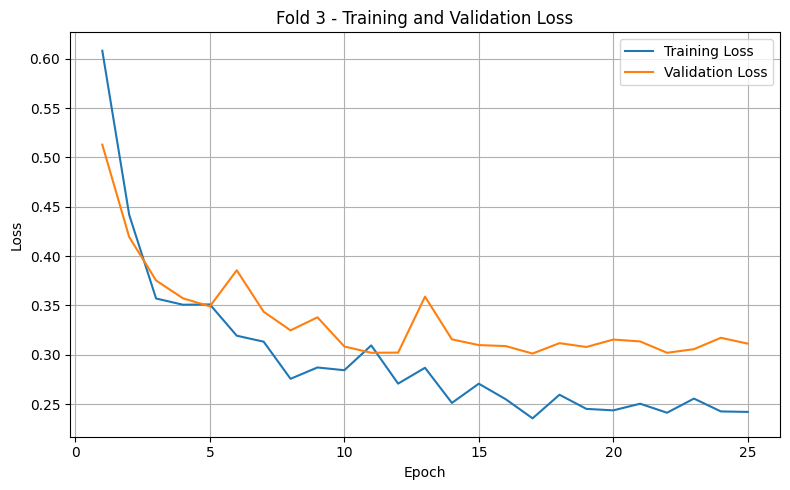


ABLATION 4 - BASELINE + CSRLM + FIEM + ASFM - FOLD 3 TEST RESULT
  Accuracy:    1.0000
  Precision:   1.0000
  Recall:      1.0000
  Specificity: 1.0000
  F1:          1.0000
  AUC:         1.0000


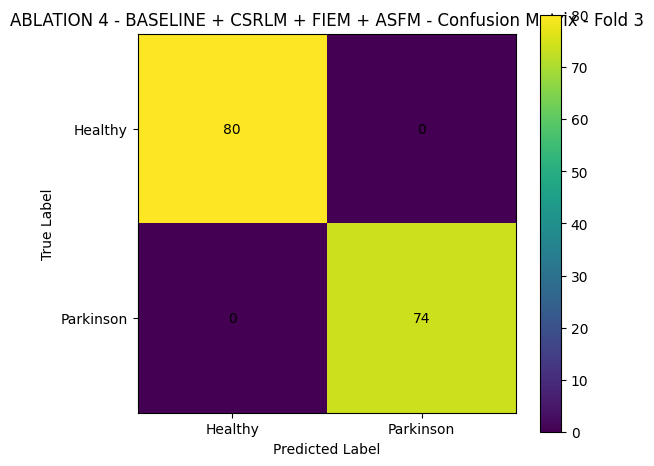


---------------------------------------------------------------------------
ABLATION 4 - BASELINE + CSRLM + FIEM + ASFM | FOLD 4/5
---------------------------------------------------------------------------
Train: 32 subjects / 499 recordings
Val:   8 subjects / 126 recordings
Test:  10 subjects / 160 recordings
Dataset initialized with 499 samples.
Dataset initialized with 126 samples.
Dataset initialized with 160 samples.
  Epoch 01 | Train Acc 0.667 | Val Acc 0.857 | Train Loss 0.650 | Val Loss 0.478 | Val AUC 0.968
  Epoch 02 | Train Acc 0.856 | Val Acc 0.960 | Train Loss 0.463 | Val Loss 0.287 | Val AUC 0.997
  Epoch 03 | Train Acc 0.908 | Val Acc 0.984 | Train Loss 0.387 | Val Loss 0.263 | Val AUC 0.997
  Epoch 04 | Train Acc 0.942 | Val Acc 0.992 | Train Loss 0.344 | Val Loss 0.234 | Val AUC 1.000
  Epoch 05 | Train Acc 0.946 | Val Acc 1.000 | Train Loss 0.324 | Val Loss 0.235 | Val AUC 1.000
  Epoch 06 | Train Acc 0.936 | Val Acc 0.984 | Train Loss 0.337 | Val Loss 0.246 | Val

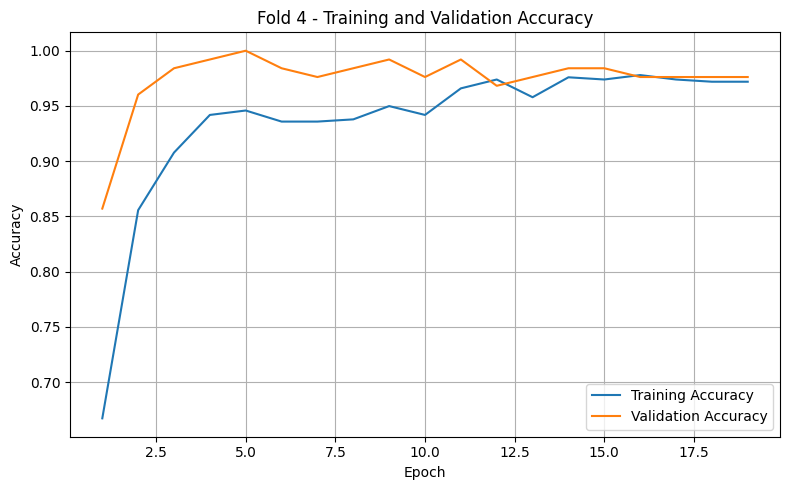

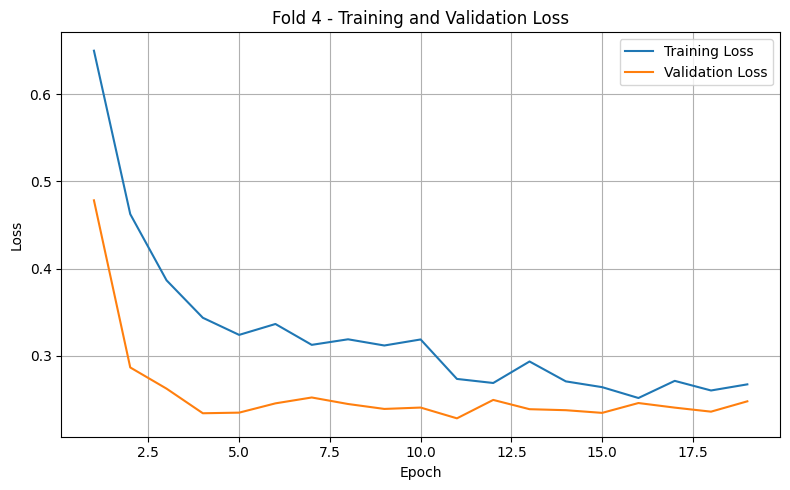


ABLATION 4 - BASELINE + CSRLM + FIEM + ASFM - FOLD 4 TEST RESULT
  Accuracy:    0.9875
  Precision:   1.0000
  Recall:      0.9792
  Specificity: 1.0000
  F1:          0.9895
  AUC:         1.0000


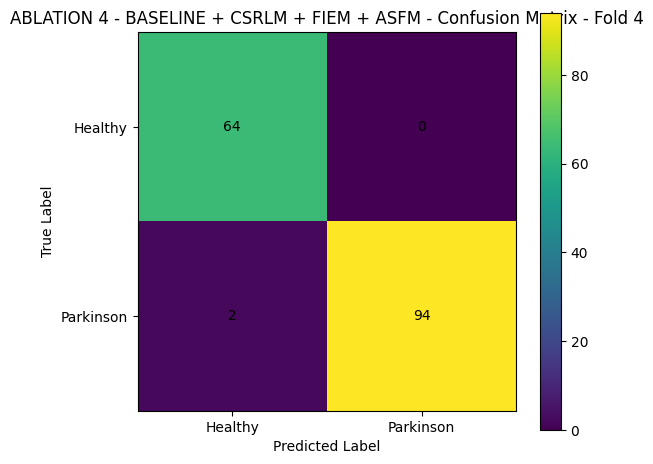


---------------------------------------------------------------------------
ABLATION 4 - BASELINE + CSRLM + FIEM + ASFM | FOLD 5/5
---------------------------------------------------------------------------
Train: 32 subjects / 499 recordings
Val:   8 subjects / 128 recordings
Test:  10 subjects / 158 recordings
Dataset initialized with 499 samples.
Dataset initialized with 128 samples.
Dataset initialized with 158 samples.
  Epoch 01 | Train Acc 0.675 | Val Acc 0.930 | Train Loss 0.600 | Val Loss 0.419 | Val AUC 0.980
  Epoch 02 | Train Acc 0.832 | Val Acc 0.953 | Train Loss 0.472 | Val Loss 0.315 | Val AUC 0.996
  Epoch 03 | Train Acc 0.902 | Val Acc 0.984 | Train Loss 0.406 | Val Loss 0.251 | Val AUC 1.000
  Epoch 04 | Train Acc 0.932 | Val Acc 1.000 | Train Loss 0.350 | Val Loss 0.250 | Val AUC 1.000
  Epoch 05 | Train Acc 0.934 | Val Acc 0.984 | Train Loss 0.331 | Val Loss 0.266 | Val AUC 1.000
  Epoch 06 | Train Acc 0.926 | Val Acc 0.984 | Train Loss 0.362 | Val Loss 0.248 | Val

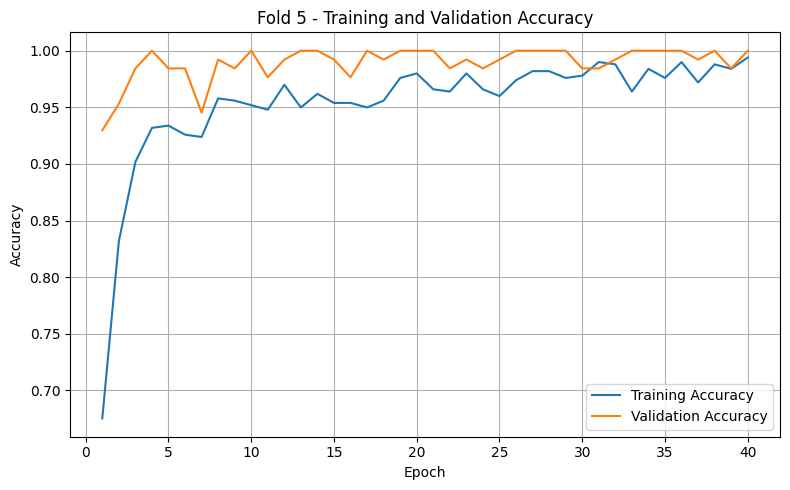

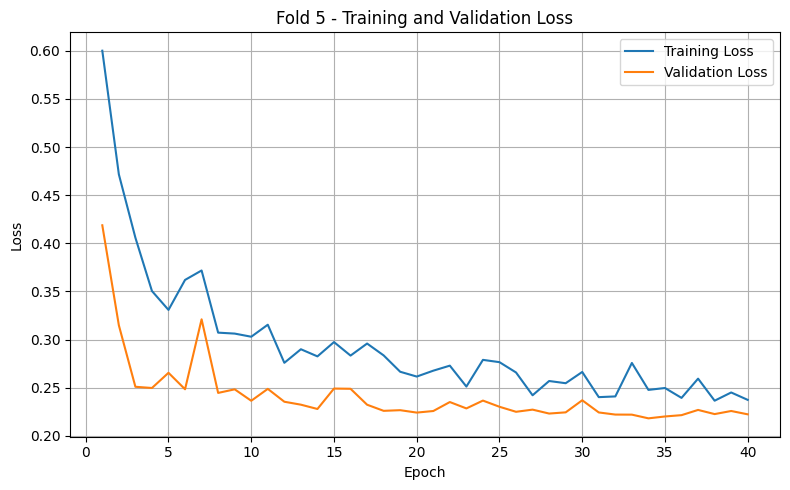


ABLATION 4 - BASELINE + CSRLM + FIEM + ASFM - FOLD 5 TEST RESULT
  Accuracy:    0.8544
  Precision:   0.7723
  Recall:      1.0000
  Specificity: 0.7125
  F1:          0.8715
  AUC:         0.9605


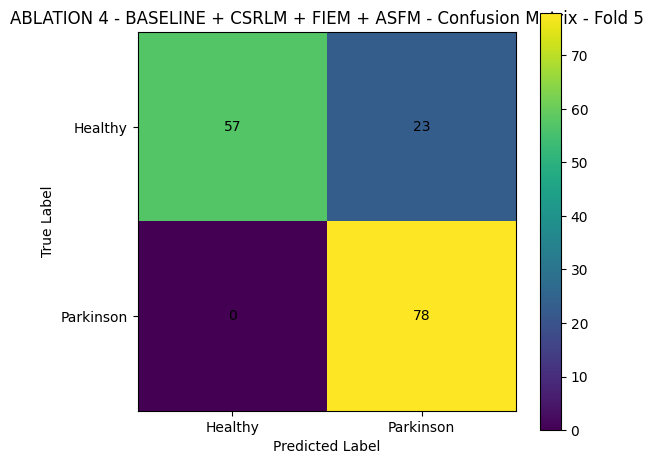


ABLATION 4 COMPLETE


In [146]:
# ============================================================
# RUN ABLATION 4
# BASELINE + CSRLM + FIEM + ASFM
# ============================================================

ablation4_results_df, ablation4_cm, ablation4_histories = (
    run_ablation_5fold(
        model_class=Ablation4_CSRLM_FIEM_ASFM,
        experiment_name=(
            "ABLATION 4 - "
            "BASELINE + CSRLM + FIEM + ASFM"
        )
    )
)

print("\nABLATION 4 COMPLETE")

In [147]:
# ============================================================
# ABLATION 4 SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("ABLATION 4 - MEAN ± STD")
print("=" * 70)

for metric in metrics:

    mean_value = (
        ablation4_results_df[metric]
        .mean()
    )

    std_value = (
        ablation4_results_df[metric]
        .std(ddof=1)
    )

    print(
        f"{metric:20s}: "
        f"{mean_value:.4f} ± "
        f"{std_value:.4f}"
    )

print("\nAggregate Confusion Matrix:")
print(ablation4_cm)


ABLATION 4 - MEAN ± STD
test_accuracy       : 0.9504 ± 0.0654
test_precision      : 0.9520 ± 0.1006
test_recall         : 0.9685 ± 0.0596
test_specificity    : 0.9392 ± 0.1269
test_f1             : 0.9565 ± 0.0577
test_auc            : 0.9742 ± 0.0396

Aggregate Confusion Matrix:
[[325  24]
 [ 15 421]]


In [148]:
# ============================================================
# FINAL ABLATION TABLE
# ============================================================

ablation_summary = pd.DataFrame({

    "Model": [
        "Baseline",
        "Baseline + CSRLM",
        "Baseline + CSRLM + FIEM",
        "Baseline + CSRLM + FIEM + ASFM"
    ],

    "Accuracy": [
        ablation1_results_df["test_accuracy"].mean(),
        ablation2_results_df["test_accuracy"].mean(),
        ablation3_results_df["test_accuracy"].mean(),
        ablation4_results_df["test_accuracy"].mean()
    ],

    "Precision": [
        ablation1_results_df["test_precision"].mean(),
        ablation2_results_df["test_precision"].mean(),
        ablation3_results_df["test_precision"].mean(),
        ablation4_results_df["test_precision"].mean()
    ],

    "Recall": [
        ablation1_results_df["test_recall"].mean(),
        ablation2_results_df["test_recall"].mean(),
        ablation3_results_df["test_recall"].mean(),
        ablation4_results_df["test_recall"].mean()
    ],

    "Specificity": [
        ablation1_results_df["test_specificity"].mean(),
        ablation2_results_df["test_specificity"].mean(),
        ablation3_results_df["test_specificity"].mean(),
        ablation4_results_df["test_specificity"].mean()
    ],

    "F1": [
        ablation1_results_df["test_f1"].mean(),
        ablation2_results_df["test_f1"].mean(),
        ablation3_results_df["test_f1"].mean(),
        ablation4_results_df["test_f1"].mean()
    ],

    "AUC": [
        ablation1_results_df["test_auc"].mean(),
        ablation2_results_df["test_auc"].mean(),
        ablation3_results_df["test_auc"].mean(),
        ablation4_results_df["test_auc"].mean()
    ]
})

print(
    ablation_summary.to_string(
        index=False
    )
)

                         Model  Accuracy  Precision   Recall  Specificity       F1      AUC
                      Baseline  0.937819   0.936997 0.968398     0.913125 0.946951 0.969269
              Baseline + CSRLM  0.939036   0.944228 0.959562     0.926721 0.947101 0.965740
       Baseline + CSRLM + FIEM  0.945383   0.943733 0.972586     0.924375 0.953048 0.975303
Baseline + CSRLM + FIEM + ASFM  0.950437   0.952046 0.968465     0.939221 0.956466 0.974170
